# Машинное обучение на количественных ЭЭГ-признаках: финальный аналитический ноутбук для ВКР

Ноутбук предназначен для единообразной оценки моделей классификации ЧМТ/контроль на уровне субъектов. Логика анализа: подготовка итоговой матрицы, EDA и важность признаков, сравнение алгоритмов, baseline-модель, сравнение групп признаков, holdout-проверка и подробный анализ компактной событийной модели.

В этом ноутбуке намеренно не добавлены итоговые текстовые выводы: он формирует таблицы, рисунки и диагностические проверки, которые затем можно перенести в текст ВКР.

## 0. Конфигурация анализа



In [1]:
# @title Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# @title 0.1. Конфигурация путей, импорты и единый стиль графиков

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    train_test_split,
    cross_val_predict,
    cross_validate,
    permutation_test_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# ============================================================
# 0. Общие параметры воспроизводимости
# ============================================================

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 20
N_BOOT = 2000
HOLDOUT_SIZE = 0.20
TOP_K_PER_BLOCK = 10

# ============================================================
# 1. Единый конфиг путей
# Менять пути нужно только здесь.
# ============================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/VKR/TBI")

# Текущая версия рабочего каталога
WORK_ROOT = PROJECT_ROOT / "work_4"

# Таблицы последней предобработки
PREPROCESS_TABLE_DIR = WORK_ROOT / "output" / "tables"

# Таблицы признаков
# Сейчас признаки у тебя лежат в старой spectral-директории.
FEATURE_TABLE_DIR = PROJECT_ROOT / "work" / "output" / "spectral" / "tables"


def first_existing_path(candidates, default=None):
    """
    Возвращает первый существующий путь.
    Если ни один путь не найден — возвращает default или первый кандидат.
    """
    candidates = [Path(p) for p in candidates]

    for p in candidates:
        if p.exists():
            return p

    if default is not None:
        return Path(default)

    return candidates[0]


CONFIG = {
    "project_root": PROJECT_ROOT,
    "work_root": WORK_ROOT,
    "preprocess_table_dir": PREPROCESS_TABLE_DIR,
    "feature_table_dir": FEATURE_TABLE_DIR,

    # Итоговая record-level матрица признаков
    "core_path": first_existing_path([
        FEATURE_TABLE_DIR / "all_features_record_level_core.csv",
        PREPROCESS_TABLE_DIR / "all_features_record_level_core.csv",

    ]),

    # Основной inventory после QC / предобработки.
    # Приоритет: последний work_4.
    "analysis_ready_inventory_path": first_existing_path([
        PREPROCESS_TABLE_DIR / "analysis_ready_inventory_cleaned.csv",
        PREPROCESS_TABLE_DIR / "inventory_processed_epochs_work_4.csv",
        FEATURE_TABLE_DIR / "analysis_ready_inventory_cleaned.csv",
        FEATURE_TABLE_DIR / "inventory_epochs_standardized.csv",

    ]),

    # Отдельно сохраняем путь к processed epochs inventory work_4
    "inventory_processed_epochs_path": first_existing_path([
        PREPROCESS_TABLE_DIR / "inventory_processed_epochs_work_4.csv",

    ]),

    # Стандартизованный inventory как fallback / аудит совместимости
    "inventory_standardized_path": first_existing_path([
        FEATURE_TABLE_DIR / "inventory_epochs_standardized.csv",

    ]),

    # Выходные папки ML-анализа
    "eda_dir": FEATURE_TABLE_DIR / "eda_record_level_core",
    "results_dir": FEATURE_TABLE_DIR / "ml_vkr_final_results",
}

CONFIG["fig_dir"] = CONFIG["results_dir"] / "figures"
CONFIG["tab_dir"] = CONFIG["results_dir"] / "tables"
CONFIG["checkpoint_dir"] = CONFIG["results_dir"] / "checkpoints"

for key in ["eda_dir", "results_dir", "fig_dir", "tab_dir", "checkpoint_dir"]:
    CONFIG[key].mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. Совместимость со старыми ячейками
# Дальше в ноутбуке желательно использовать только эти переменные.
# ============================================================

BASE_DIR = CONFIG["feature_table_dir"]
BASE_TAB = CONFIG["feature_table_dir"]

CORE_PATH = CONFIG["core_path"]

INV_PATH = CONFIG["analysis_ready_inventory_path"]
ANALYSIS_READY_INVENTORY = CONFIG["analysis_ready_inventory_path"]

INVENTORY_PROCESSED_EPOCHS = CONFIG["inventory_processed_epochs_path"]
INV_STANDARDIZED_PATH = CONFIG["inventory_standardized_path"]

EDA_DIR = CONFIG["eda_dir"]
OUT_DIR = CONFIG["eda_dir"]

RESULTS_DIR = CONFIG["results_dir"]
FIG_DIR = CONFIG["fig_dir"]
TAB_DIR = CONFIG["tab_dir"]
CHECKPOINT_DIR = CONFIG["checkpoint_dir"]

# ============================================================
# 3. Единая палитра для ВКР
# Контроль — тёмно-синий, ЧМТ — тёмно-красный.
# ============================================================

COLOR_CONTROL = "#1F4E79"  # тёмно-синий
COLOR_TBI = "#8B1E2D"      # тёмно-красный
COLOR_ACCENT = COLOR_CONTROL
COLOR_GRAY = "#666666"
COLOR_LIGHT_GRAY = "#D9D9D9"

GROUP_PALETTE = {
    "Контроль": COLOR_CONTROL,
    "Control": COLOR_CONTROL,
    0: COLOR_CONTROL,
    "ЧМТ": COLOR_TBI,
    "TBI": COLOR_TBI,
    1: COLOR_TBI,
}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
})

# ============================================================
# 4. Проверка путей
# ============================================================

print("=== CONFIG PATHS ===")
for key in [
    "core_path",
    "analysis_ready_inventory_path",
    "inventory_processed_epochs_path",
    "inventory_standardized_path",
    "eda_dir",
    "results_dir",
    "fig_dir",
    "tab_dir",
    "checkpoint_dir",
]:
    p = CONFIG[key]
    print(f"{key}: {p} | exists={Path(p).exists()}")


=== CONFIG PATHS ===
core_path: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/all_features_record_level_core.csv | exists=True
analysis_ready_inventory_path: /content/drive/MyDrive/VKR/TBI/work_4/output/tables/inventory_processed_epochs_work_4.csv | exists=True
inventory_processed_epochs_path: /content/drive/MyDrive/VKR/TBI/work_4/output/tables/inventory_processed_epochs_work_4.csv | exists=True
inventory_standardized_path: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/inventory_epochs_standardized.csv | exists=True
eda_dir: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core | exists=True
results_dir: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results | exists=True
fig_dir: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures | exists=True
tab_dir: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables | exists=True
checkpoint_dir: /con

In [3]:
# @title 0.2. Вспомогательные функции: подписи, сохранение таблиц и рисунков

def save_table(df, filename, index=False):
    path = TAB_DIR / filename
    df.to_csv(path, index=index)
    print(f"Сохранена таблица: {path}")
    return path


def save_figure(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Сохранён рисунок: {path}")
    return path


def clean_feature_label(name):
    """Короткая русифицированная подпись для графиков."""
    ru = {
        "event__z_peak": "Пик события, z",
        "event__propagation_ms": "Распространение, мс",
        "bp": "Мощность",
        "idx": "Спектральные индексы",
        "aper": "Апериодика",
        "alpha_peak": "Альфа-пик",
        "spec_shape": "Форма спектра",
        "dfa": "DFA",
        "burst": "Вспышки",
        "conn": "Связность",
        "graph": "Графовые метрики",
        "event": "События",
        "tfr": "Время–частота",
        "spectral_baseline": "Спектральный baseline",
    }
    if name in ru:
        return ru[name]
    out = name
    for key, value in ru.items():
        out = out.replace(key, value)
    out = out.replace("__", " · ").replace("_", " ")
    return out


def format_ci(mean, low, high, digits=3):
    return f"{mean:.{digits}f} [{low:.{digits}f}; {high:.{digits}f}]"


def detect_block(feature_name):
    """Определяет блок признака по префиксу до двойного подчёркивания."""
    if "__" in feature_name:
        return feature_name.split("__", 1)[0]
    return "other"

## 1. Формирование единой матрицы признаков

На этом этапе объединяются признаки, рассчитанные в отдельных модулях анализа ЭЭГ. Цель блока — получить единую record-level таблицу без повторного пересчёта исходных сигналов.

In [4]:
# @title 1.1. Загрузка исходных таблиц из единого CONFIG

core = pd.read_csv(CORE_PATH)
inv = pd.read_csv(INV_PATH)

for df_name, df in [("inventory", inv), ("core", core)]:
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip()
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str).str.strip()

group_map = {
    "TBI": "ЧМТ",
    "tbi": "ЧМТ",
    "Control": "Контроль",
    "control": "Контроль",
}

def infer_subject_id(record_id, group=None):
    """Единое восстановление subject_id для контроля и ЧМТ."""
    s = str(record_id).strip()
    g = str(group).strip().lower() if group is not None else ""

    # Контроль OpenNeuro: ctlraw_soft_sub-001_ses-...
    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    # ЧМТ: tbi_soft_3001_1_Rest
    m = re.search(r"tbi_soft_(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi-{m.group(1)}"

    # ЧМТ fallback
    if "tbi" in g:
        m = re.search(r"(\d{4})", s)
        if m:
            return f"tbi-{m.group(1)}"

    return s.lower()

for df in [inv, core]:
    df["_group_pretty"] = df["group"].map(lambda x: group_map.get(x, x))
    if "subject_id" not in df.columns:
        df["subject_id"] = df.apply(
            lambda row: infer_subject_id(row["record_id"], row["group"]),
            axis=1,
        )
    else:
        df["subject_id"] = df["subject_id"].astype(str).str.strip()

print("=== ЗАГРУЗКА ДАННЫХ ===")
print("Inventory path:", INV_PATH)
print("Core path:", CORE_PATH)
print("inventory:", inv.shape)
print("core:", core.shape)

print("\nЗаписи по группам в inventory:")
display(inv["_group_pretty"].value_counts(dropna=False))

print("\nЗаписи по группам в core:")
display(core["_group_pretty"].value_counts(dropna=False))

print("\nСубъекты по группам в core:")
display(core.groupby("_group_pretty")["subject_id"].nunique())


=== ЗАГРУЗКА ДАННЫХ ===
Inventory path: /content/drive/MyDrive/VKR/TBI/work_4/output/tables/inventory_processed_epochs_work_4.csv
Core path: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/all_features_record_level_core.csv
inventory: (575, 56)
core: (579, 659)

Записи по группам в inventory:


,count
_group_pretty,
Контроль,363
ЧМТ,212



Записи по группам в core:


,count
_group_pretty,
Контроль,364
ЧМТ,215



Субъекты по группам в core:


,subject_id
_group_pretty,
Контроль,72
ЧМТ,92


In [5]:
# @title 1.2. Первичный аудит inventory и record-level матрицы

print("=== SHAPES ===")
print("inventory:", inv.shape)
print("core:", core.shape)

print("\n=== KEYS ===")
print("inventory duplicated keys:", inv.duplicated(["group", "record_id"]).sum())
print("core duplicated keys:", core.duplicated(["group", "record_id"]).sum())

# =========================================
# 1. Характеристики выборки
# =========================================
agg_spec = {
    "n_subjects": ("subject_id", "nunique"),
    "n_records": ("record_id", "nunique"),
}

if "n_epochs" in inv.columns:
    agg_spec.update({
        "n_epochs_sum": ("n_epochs", "sum"),
        "n_epochs_median": ("n_epochs", "median"),
        "n_epochs_q1": ("n_epochs", lambda x: x.quantile(0.25)),
        "n_epochs_q3": ("n_epochs", lambda x: x.quantile(0.75)),
    })

if "size_mb" in inv.columns:
    agg_spec.update({
        "file_size_mb_median": ("size_mb", "median"),
        "file_size_mb_q1": ("size_mb", lambda x: x.quantile(0.25)),
        "file_size_mb_q3": ("size_mb", lambda x: x.quantile(0.75)),
    })

for col, label in [
    ("n_channels", "n_channels_median"),
    ("sfreq_hz", "sfreq_median"),
    ("epoch_len_sec", "epoch_len_median"),
]:
    if col in inv.columns:
        agg_spec[label] = (col, "median")

sample_stats = (
    inv.groupby("_group_pretty")
    .agg(**agg_spec)
    .reset_index()
)

print("\n=== SAMPLE STATS ===")
display(sample_stats)
save_table(sample_stats, "01_sample_stats_by_group.csv")

# Таблица для ВКР
groups_order = ["ЧМТ", "Контроль"]
rows = [{"Параметр": "Число субъектов"}, {"Параметр": "Число записей"}]
subj_stat = inv.groupby("_group_pretty")["subject_id"].nunique()
record_stat = inv.groupby("_group_pretty")["record_id"].nunique()

for g in groups_order:
    rows[0][g] = int(subj_stat[g]) if g in subj_stat.index else "—"
    rows[1][g] = int(record_stat[g]) if g in record_stat.index else "—"

if "n_epochs" in inv.columns:
    epoch_stat = inv.groupby("_group_pretty")["n_epochs"].sum()
    rows.append({"Параметр": "Число эпох"})
    for g in groups_order:
        rows[-1][g] = int(epoch_stat[g]) if g in epoch_stat.index else "—"

sample_table = pd.DataFrame(rows)
print("\n=== TABLE 2.1 ===")
display(sample_table)
save_table(sample_table, "01_table_sample_characteristics.csv")

# =========================================
# 2. Missingness и согласованность inventory
# =========================================
inventory_missing = (
    inv.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

print("\n=== INVENTORY MISSINGNESS ===")
display(inventory_missing.head(20))
save_table(inventory_missing, "01_inventory_missingness.csv")

consistency_rows = []
for col in ["sfreq_hz", "n_channels", "epoch_len_sec", "tmin_sec", "tmax_sec"]:
    if col in inv.columns:
        vals = pd.to_numeric(inv[col], errors="coerce").dropna()
        consistency_rows.append({
            "parameter": col,
            "n_unique": vals.nunique(),
            "min": vals.min() if len(vals) else np.nan,
            "median": vals.median() if len(vals) else np.nan,
            "max": vals.max() if len(vals) else np.nan,
        })

consistency_df = pd.DataFrame(consistency_rows)
print("\n=== CONSISTENCY CHECK ===")
display(consistency_df)
save_table(consistency_df, "01_inventory_consistency_check.csv")

# =========================================
# 3. Аудит record-level признаков
# =========================================
key_cols = ["group", "record_id", "_group_pretty", "subject_id"]
feature_cols_raw = [c for c in core.columns if c not in key_cols]
numeric_cols_raw = [c for c in feature_cols_raw if pd.api.types.is_numeric_dtype(core[c])]
core_num = core[numeric_cols_raw].copy()

feature_missing = (
    core_num.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)

feature_var = core_num.var(numeric_only=True)

core_overview = pd.DataFrame([{
    "n_rows": core.shape[0],
    "n_columns_total": core.shape[1],
    "n_feature_columns": len(feature_cols_raw),
    "n_numeric_features": len(numeric_cols_raw),
    "mean_missing_fraction_over_features": core_num.isna().mean().mean(),
    "max_missing_fraction": core_num.isna().mean().max(),
    "n_features_with_any_missing": int((core_num.isna().mean() > 0).sum()),
    "n_features_all_missing": int((core_num.isna().mean() == 1).sum()),
    "n_features_zero_variance": int((feature_var.fillna(0) == 0).sum()),
}])

print("\n=== CORE OVERVIEW ===")
display(core_overview)
save_table(core_overview, "01_core_overview_raw.csv")

print("\n=== TOP FEATURES BY MISSINGNESS ===")
display(feature_missing.head(20))
save_table(feature_missing, "01_core_feature_missingness_raw.csv")

low_var_df = (
    feature_var.sort_values()
    .rename("variance")
    .reset_index()
    .rename(columns={"index": "feature"})
)
print("\n=== LOWEST VARIANCE FEATURES ===")
display(low_var_df.head(20))
save_table(low_var_df, "01_core_feature_variance_raw.csv")

def extract_block_name(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_missing = []
for block in pd.Series(numeric_cols_raw).map(extract_block_name).value_counts().index:
    cols = [c for c in numeric_cols_raw if extract_block_name(c) == block]
    block_missing.append({
        "block": block,
        "n_features": len(cols),
        "mean_missing_fraction": core_num[cols].isna().mean().mean(),
        "max_missing_fraction": core_num[cols].isna().mean().max(),
    })

block_missing_df = pd.DataFrame(block_missing).sort_values("n_features", ascending=False)

print("\n=== RAW BLOCK SUMMARY ===")
display(block_missing_df)
save_table(block_missing_df, "01_core_blocks_summary_raw.csv")


=== SHAPES ===
inventory: (575, 56)
core: (579, 659)

=== KEYS ===
inventory duplicated keys: 0
core duplicated keys: 0

=== SAMPLE STATS ===


,_group_pretty,n_subjects,n_records,n_epochs_sum,n_epochs_median,n_epochs_q1,n_epochs_q3,file_size_mb_median,file_size_mb_q1,file_size_mb_q3,n_channels_median,sfreq_median,epoch_len_median
0,Контроль,72,363,16387,45.0,45.0,46.0,19.923,19.923,20.365,58.0,500.0,4.0
1,ЧМТ,92,212,23832,114.0,111.0,116.0,50.457,49.129,51.342,58.0,500.0,4.0


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_sample_stats_by_group.csv

=== TABLE 2.1 ===


,Параметр,ЧМТ,Контроль
0,Число субъектов,92,72
1,Число записей,212,363
2,Число эпох,23832,16387


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_table_sample_characteristics.csv

=== INVENTORY MISSINGNESS ===


...

,feature,variance
0,bp__band_fmax__central_alpha,0.0
1,bp__band_fmax__central_beta,0.0
2,bp__band_fmax__central_delta,0.0
3,bp__band_fmax__central_gamma,0.0
4,bp__band_fmax__central_theta,0.0
5,bp__band_fmax__frontal_alpha,0.0
6,bp__band_fmax__frontal_beta,0.0
7,bp__band_fmax__temporal_gamma,0.0
8,bp__band_fmax__temporal_theta,0.0
9,alpha_peak__alpha_win_lo__central,0.0


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_core_feature_variance_raw.csv

=== RAW BLOCK SUMMARY ===


,block,n_features,mean_missing_fraction,max_missing_fraction
0,conn,300,0.000040,0.003454
1,burst,100,0.000138,0.003454
2,bp,50,0.000000,0.000000
3,aper,45,0.001689,0.046632
4,dfa,40,0.000000,0.000000
5,tfr,30,0.000000,0.000000
6,alpha_peak,30,0.000000,0.000000
7,spec_shape,25,0.000000,0.000000
8,event,16,0.000000,0.000000
9,gamma,12,0.000000,0.000000


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_core_blocks_summary_raw.csv


PosixPath('/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_core_blocks_summary_raw.csv')

In [6]:
# @title 1.3. Единая последовательная очистка и subject-level матрица

# ============================================================
# 1. Правила очистки
# ============================================================
STRICT_EXCLUDE_SEC_FEATURES = True
VAR_EPS = 1e-12

# Служебные переменные, которые нельзя использовать как ML-признаки.
# Они могут сохраняться отдельно только для проверки смешивающих факторов.
FORCED_EXCLUDE_FEATURES = [
    "n_records_subject",
]

ID_COLS = [
    "group",
    "_group_pretty",
    "subject_id",
    "record_id",
    "filename",
    "filepath",
]

EXCLUDED_BLOCKS = [
    "meta",
    "gamma",
]

TECHNICAL_PATTERNS = [
    "meta__",
    "gamma",
    "size_mb",
    "n_epochs",
    "n_epochs_used",
    "n_channels",
    "sfreq",
    "epoch_len",
    "tmax_sec",
    "tmin_sec",
    "filepath",
    "filename",
    "p2p",
    "qc",
    "bad_epoch",
    "amplitude",
    "n_records_subject",
]

ACCUMULATIVE_PATTERNS = [
    "total_sec",
    "n_bursts",
    "n_events",
]

if STRICT_EXCLUDE_SEC_FEATURES:
    TECHNICAL_PATTERNS = TECHNICAL_PATTERNS + ["_sec"]

candidate_features = [
    c for c in core.columns
    if c not in ID_COLS
    and pd.api.types.is_numeric_dtype(core[c])
]

def exclusion_reasons(feature):
    f = str(feature).lower()
    block = detect_block(feature)
    reasons = []
    if feature in FORCED_EXCLUDE_FEATURES:
        reasons.append("forced_service_covariate_exclusion")
    if block in EXCLUDED_BLOCKS:
        reasons.append("excluded_block")
    if any(p in f for p in TECHNICAL_PATTERNS):
        reasons.append("technical_or_time_related")
    if any(p in f for p in ACCUMULATIVE_PATTERNS):
        reasons.append("accumulative_count_or_duration")
    return reasons

excluded_rows = []
initial_clean_features = []

for feat in candidate_features:
    reasons = exclusion_reasons(feat)
    if reasons:
        excluded_rows.append({
            "feature": feat,
            "block": detect_block(feat),
            "reason": "; ".join(reasons),
        })
    else:
        initial_clean_features.append(feat)

excluded_features_df = pd.DataFrame(excluded_rows)

# ============================================================
# 2. Subject-level aggregation
# ============================================================
subject_features_df = (
    core
    .groupby(["subject_id", "group", "_group_pretty"], as_index=False)[initial_clean_features]
    .median()
)

n_records_subject = (
    core.groupby("subject_id")
    .size()
    .rename("n_records_subject")
    .reset_index()
)

subject_features_df = subject_features_df.merge(
    n_records_subject,
    on="subject_id",
    how="left",
)

LABEL_MAP = {
    "Control": 0,
    "control": 0,
    "Контроль": 0,
    "TBI": 1,
    "tbi": 1,
    "ЧМТ": 1,
}

subject_features_df["y"] = subject_features_df["group"].map(LABEL_MAP)

if subject_features_df["y"].isna().any():
    bad = subject_features_df.loc[subject_features_df["y"].isna(), ["subject_id", "group", "_group_pretty"]]
    display(bad.drop_duplicates())
    raise ValueError("Есть строки с неопределённой меткой класса y.")

subject_features_df["y"] = subject_features_df["y"].astype(int)

# ============================================================
# 3. Удаление пропусков/inf/нулевой дисперсии после subject-level агрегации
# ============================================================
X_tmp = subject_features_df[initial_clean_features].apply(pd.to_numeric, errors="coerce")
X_tmp = X_tmp.replace([np.inf, -np.inf], np.nan)

missing_fraction = X_tmp.isna().mean()
variance = X_tmp.var(axis=0, ddof=1)

bad_numeric_features = (
    missing_fraction[missing_fraction > 0].index.tolist()
    + variance[variance.fillna(0) <= VAR_EPS].index.tolist()
)

bad_numeric_features = sorted(set(bad_numeric_features))

for feat in bad_numeric_features:
    reason_parts = []
    if feat in missing_fraction.index and missing_fraction[feat] > 0:
        reason_parts.append("missing_after_aggregation")
    if feat in variance.index and variance.fillna(0)[feat] <= VAR_EPS:
        reason_parts.append("zero_or_near_zero_variance")
    excluded_rows.append({
        "feature": feat,
        "block": detect_block(feat),
        "reason": "; ".join(reason_parts),
    })

clean_feature_cols = [
    c for c in initial_clean_features
    if c not in bad_numeric_features
    and c not in FORCED_EXCLUDE_FEATURES
]

feature_cols_all = clean_feature_cols.copy()
final_features = clean_feature_cols.copy()

# Основная ML-таблица: служебные ковариаты остаются в subject_df, но не входят в clean_feature_cols.
subject_df = subject_features_df[
    ["subject_id", "group", "_group_pretty", "y", "n_records_subject"] + clean_feature_cols
].copy()

clean_subject_df = subject_df[
    ["subject_id", "group", "_group_pretty", "y"] + clean_feature_cols
].copy()

service_covariates_df = subject_df[
    ["subject_id", "group", "_group_pretty", "y", "n_records_subject"]
].copy()

meta_like_cols = ["n_records_subject"]
qc_candidates = meta_like_cols.copy()

# ============================================================
# 4. FEATURE_SETS
# ============================================================
FEATURE_SETS = {
    block: [
        c for c in clean_feature_cols
        if detect_block(c) == block
    ]
    for block in sorted(set(detect_block(c) for c in clean_feature_cols))
}

# Спектральный baseline после строгой очистки:
# bp/idx могли стать пустыми; поэтому используем интерпретируемый спектральный набор.
SPECTRAL_BASELINE_BLOCKS = ["alpha_peak", "aper", "spec_shape"]
FEATURE_SETS["spectral_baseline"] = [
    c for c in clean_feature_cols
    if detect_block(c) in SPECTRAL_BASELINE_BLOCKS
]

# Старый baseline добавляем только если реально есть признаки.
bp_idx_cols = [
    c for c in clean_feature_cols
    if detect_block(c) in ["bp", "idx"]
]
if len(bp_idx_cols) > 0:
    FEATURE_SETS["bp_idx"] = bp_idx_cols

EVENT_CORE_CANDIDATES = [
    "event__z_peak",
    "event__propagation_ms",
]

EVENT_CORE = [
    c for c in EVENT_CORE_CANDIDATES
    if c in clean_feature_cols
]

FEATURE_SETS["event_compact"] = EVENT_CORE.copy()

# ============================================================
# 5. Контрольные таблицы
# ============================================================
excluded_features_df = pd.DataFrame(excluded_rows).drop_duplicates("feature").sort_values(["block", "feature"])

feature_set_summary = pd.DataFrame([
    {
        "feature_set": k,
        "n_features": len(v),
        "contains_bad_sec": any("_sec" in c.lower() for c in v),
        "contains_accumulative": any(
            any(p in c.lower() for p in ["total_sec", "n_events", "n_bursts"])
            for c in v
        ),
        "contains_meta_or_gamma": any(
            any(p in c.lower() for p in ["meta__", "gamma"])
            for c in v
        ),
    }
    for k, v in FEATURE_SETS.items()
]).sort_values("feature_set")

event_cols_clean = FEATURE_SETS.get("event", [])
bad_event_cols = [
    c for c in event_cols_clean
    if any(
        p in c.lower()
        for p in ["_sec", "total_sec", "n_events", "n_bursts", "meta__", "gamma"]
    )
]

subject_class_summary = (
    subject_df
    .groupby(["_group_pretty", "y"])
    .agg(
        n_subjects=("subject_id", "nunique"),
        median_records=("n_records_subject", "median"),
        mean_records=("n_records_subject", "mean"),
        min_records=("n_records_subject", "min"),
        max_records=("n_records_subject", "max"),
    )
    .reset_index()
)

# ============================================================
# 6. Сохранение единой очищенной матрицы
# ============================================================
clean_subject_df.to_csv(OUT_DIR / "subject_level_core_clean.csv", index=False, encoding="utf-8")
service_covariates_df.to_csv(OUT_DIR / "subject_level_service_covariates.csv", index=False, encoding="utf-8")
excluded_features_df.to_csv(OUT_DIR / "excluded_features_from_ml.csv", index=False, encoding="utf-8")
feature_set_summary.to_csv(OUT_DIR / "feature_sets_summary_clean.csv", index=False, encoding="utf-8")

print("=== ЕДИНАЯ ОЧИЩЕННАЯ МАТРИЦА ===")
print("Record-level matrix:", core.shape)
print("Subject-level matrix:", clean_subject_df.shape)
print("Число кандидатных числовых признаков:", len(candidate_features))
print("Число очищенных ML-признаков:", len(clean_feature_cols))
print("Исключено признаков:", len(excluded_features_df))
print("STRICT_EXCLUDE_SEC_FEATURES:", STRICT_EXCLUDE_SEC_FEATURES)

print("\nСубъекты по группам:")
display(subject_class_summary)

print("\nСводка наборов признаков:")
display(feature_set_summary)

print("\nПервые исключённые признаки:")
display(excluded_features_df.head(30))

print("\nEvent-блок после очистки:")
display(pd.DataFrame({"event_feature": event_cols_clean}))

print("Потенциально проблемные event-признаки после очистки:")
display(pd.DataFrame({"bad_event_feature": bad_event_cols}))

if len(bad_event_cols) > 0:
    raise ValueError("В event-блоке остались потенциально проблемные признаки.")

leaked_service_features = sorted(set(clean_feature_cols).intersection(FORCED_EXCLUDE_FEATURES))
if leaked_service_features:
    raise ValueError(f"Служебные ковариаты попали в ML-признаки: {leaked_service_features}")

print("\nПроверка служебных ковариат:")
print("n_records_subject входит в clean_feature_cols:", "n_records_subject" in clean_feature_cols)
print("n_records_subject сохранён только для confound-analysis:", "n_records_subject" in subject_df.columns)

if clean_subject_df["y"].nunique() != 2:
    raise ValueError("После очистки остался не бинарный набор классов.")


=== ЕДИНАЯ ОЧИЩЕННАЯ МАТРИЦА ===
Record-level matrix: (579, 659)
Subject-level matrix: (164, 306)
Число кандидатных числовых признаков: 655
Число очищенных ML-признаков: 302
Исключено признаков: 353
STRICT_EXCLUDE_SEC_FEATURES: True

Субъекты по группам:


,_group_pretty,y,n_subjects,median_records,mean_records,min_records,max_records
0,Контроль,0,72,4.0,5.055556,4,8
1,ЧМТ,1,92,3.0,2.336957,1,3



Сводка наборов признаков:


,feature_set,n_features,contains_bad_sec,contains_accumulative,contains_meta_or_gamma
0,alpha_peak,15,False,False,False
1,aper,31,False,False,False
2,burst,40,False,False,False
3,conn,172,False,False,False
4,dfa,10,False,False,False
5,event,14,False,False,False
9,event_compact,2,False,False,False
6,spec_shape,15,False,False,False
8,spectral_baseline,61,False,False,False
7,tfr,5,False,False,False



Первые исключённые признаки:


...


Event-блок после очистки:


,event_feature
0,event__peak_to_peak_uv
1,event__auc_abs_uvs
2,event__energy_uv2s
3,event__line_length_uv
4,event__slope_rise_uvs
5,event__slope_fall_uvs
6,event__sharpness_uv
7,event__z_peak
8,event__slow_peak_uv
9,event__spike_to_slow_ratio


Потенциально проблемные event-признаки после очистки:


,bad_event_feature



Проверка служебных ковариат:
n_records_subject входит в clean_feature_cols: False
n_records_subject сохранён только для confound-analysis: True


In [7]:
# @title 1.4. Контроль качества очищенной признаковой матрицы

required_objects = [
    "clean_subject_df",
    "clean_feature_cols",
    "FEATURE_SETS",
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "Не найдены обязательные объекты после очистки: "
        f"{missing_objects}"
    )

print("=== ПРОВЕРКА ОЧИЩЕННОЙ МАТРИЦЫ ===")
print("clean_subject_df shape:", clean_subject_df.shape)
print("Число очищенных признаков:", len(clean_feature_cols))

print("\n=== КЛАССЫ И СУБЪЕКТЫ ===")
display(
    clean_subject_df
    .groupby(["_group_pretty", "y"])
    .agg(n_subjects=("subject_id", "nunique"))
    .reset_index()
)

forbidden_patterns = [
    "meta__",
    "gamma",
    "size_mb",
    "n_epochs",
    "n_epochs_used",
    "n_channels",
    "sfreq",
    "epoch_len",
    "tmin_sec",
    "tmax_sec",
    "total_sec",
    "n_bursts",
    "n_events",
    "_sec",
    "filepath",
    "filename",
    "p2p",
    "qc",
    "bad_epoch",
    "amplitude",
]

forbidden_hits = []

for feat in clean_feature_cols:
    hit_patterns = [
        pattern for pattern in forbidden_patterns
        if pattern in feat.lower()
    ]
    if hit_patterns:
        forbidden_hits.append({
            "feature": feat,
            "matched_patterns": "; ".join(hit_patterns),
        })

forbidden_hits_df = pd.DataFrame(forbidden_hits)

print("\n=== ЗАПРЕЩЁННЫЕ ПАТТЕРНЫ В ОЧИЩЕННЫХ ПРИЗНАКАХ ===")
print("Найдено:", len(forbidden_hits_df))
display(forbidden_hits_df.head(50))

if len(forbidden_hits_df) > 0:
    raise ValueError(
        "В clean_feature_cols остались признаки с запрещёнными паттернами. "
        "Очистка не завершена."
    )

X_clean = clean_subject_df[clean_feature_cols].apply(pd.to_numeric, errors="coerce")
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

missing_fraction = X_clean.isna().mean()
inf_fraction = np.isinf(X_clean.to_numpy(dtype=float)).mean(axis=0)
variance = X_clean.var(axis=0, ddof=1)

quality_df = pd.DataFrame({
    "feature": clean_feature_cols,
    "missing_fraction": missing_fraction.values,
    "inf_fraction": inf_fraction,
    "variance": variance.values,
})

quality_df["zero_or_near_zero_variance"] = quality_df["variance"].fillna(0) <= VAR_EPS
quality_df["has_missing"] = quality_df["missing_fraction"] > 0
quality_df["has_inf"] = quality_df["inf_fraction"] > 0

print("\n=== КАЧЕСТВО ЧИСЛОВЫХ ПРИЗНАКОВ ===")
quality_summary = pd.DataFrame([{
    "n_features": len(clean_feature_cols),
    "n_features_with_missing": int(quality_df["has_missing"].sum()),
    "max_missing_fraction": float(quality_df["missing_fraction"].max()),
    "n_features_with_inf": int(quality_df["has_inf"].sum()),
    "n_zero_or_near_zero_variance": int(quality_df["zero_or_near_zero_variance"].sum()),
}])
display(quality_summary)

print("\nПризнаки с наибольшей долей пропусков:")
display(quality_df.sort_values("missing_fraction", ascending=False).head(15))

print("\nПризнаки с нулевой или почти нулевой дисперсией:")
display(
    quality_df
    .loc[quality_df["zero_or_near_zero_variance"]]
    .sort_values("variance")
    .head(30)
)

print("\n=== ПРОВЕРКА FEATURE_SETS ===")
feature_set_check_df = pd.DataFrame([
    {
        "feature_set": name,
        "n_features": len(cols),
        "n_missing_from_clean": sum(c not in clean_feature_cols for c in cols),
        "n_forbidden_inside": sum(
            any(pattern in c.lower() for pattern in forbidden_patterns)
            for c in cols
        ),
        "contains_bad_sec": any("_sec" in c.lower() for c in cols),
        "contains_accumulative": any(
            any(p in c.lower() for p in ["total_sec", "n_events", "n_bursts"])
            for c in cols
        ),
        "contains_meta_or_gamma": any(
            any(p in c.lower() for p in ["meta__", "gamma"])
            for c in cols
        ),
    }
    for name, cols in FEATURE_SETS.items()
]).sort_values("feature_set")

display(feature_set_check_df)

bad_feature_sets = feature_set_check_df[
    (feature_set_check_df["n_missing_from_clean"] > 0)
    | (feature_set_check_df["n_forbidden_inside"] > 0)
    | (feature_set_check_df["contains_bad_sec"])
    | (feature_set_check_df["contains_accumulative"])
    | (feature_set_check_df["contains_meta_or_gamma"])
]

if len(bad_feature_sets) > 0:
    raise ValueError(
        "Некоторые FEATURE_SETS содержат запрещённые или отсутствующие признаки."
    )

print("\n=== EVENT-БЛОК ПОСЛЕ ОЧИСТКИ ===")
event_cols_clean = FEATURE_SETS.get("event", [])
display(pd.DataFrame({"event_feature": event_cols_clean}))

bad_event_cols = [
    c for c in event_cols_clean
    if any(
        pattern in c.lower()
        for pattern in [
            "_sec",
            "total_sec",
            "n_events",
            "n_bursts",
            "meta__",
            "gamma",
        ]
    )
]

print("Потенциально проблемные event-признаки:", len(bad_event_cols))
display(pd.DataFrame({"bad_event_feature": bad_event_cols}))

if len(bad_event_cols) > 0:
    raise ValueError(
        "В event-блоке остались потенциально проблемные признаки."
    )

save_table(quality_df, "01_clean_feature_quality_check.csv")
save_table(feature_set_check_df, "01_clean_feature_sets_quality_check.csv")
save_table(quality_summary, "01_clean_feature_quality_summary.csv")

print("\n✅ Проверка очищенной матрицы завершена")
print("Если ячейка дошла до этого места без ошибки, ML-разделы используют очищенное признаковое пространство.")


=== ПРОВЕРКА ОЧИЩЕННОЙ МАТРИЦЫ ===
clean_subject_df shape: (164, 306)
Число очищенных признаков: 302

=== КЛАССЫ И СУБЪЕКТЫ ===


,_group_pretty,y,n_subjects
0,Контроль,0,72
1,ЧМТ,1,92



=== ЗАПРЕЩЁННЫЕ ПАТТЕРНЫ В ОЧИЩЕННЫХ ПРИЗНАКАХ ===
Найдено: 0


""



=== КАЧЕСТВО ЧИСЛОВЫХ ПРИЗНАКОВ ===


...


=== EVENT-БЛОК ПОСЛЕ ОЧИСТКИ ===


,event_feature
0,event__peak_to_peak_uv
1,event__auc_abs_uvs
2,event__energy_uv2s
3,event__line_length_uv
4,event__slope_rise_uvs
5,event__slope_fall_uvs
6,event__sharpness_uv
7,event__z_peak
8,event__slow_peak_uv
9,event__spike_to_slow_ratio


Потенциально проблемные event-признаки: 0


,bad_event_feature


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_clean_feature_quality_check.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_clean_feature_sets_quality_check.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/01_clean_feature_quality_summary.csv

✅ Проверка очищенной матрицы завершена
Если ячейка дошла до этого места без ошибки, ML-разделы используют очищенное признаковое пространство.


## 2. EDA и анализ важности признаков

=== TOP FEATURES BY HEDGES g, SUBJECT-LEVEL CLEAN ===


,feature,feature_ru,block,block_ru,n_tbi,n_control,mean_tbi,mean_control,median_tbi,median_control,std_tbi,std_control,missing_fraction,hedges_g_tbi_minus_control,abs_hedges_g
0,event__z_peak,"Пик события, z",event,События,92,72,3.052323,4.219268,3.004158,4.216311,0.593985,0.338687,0.0,-2.330248,2.330248
1,event__propagation_ms,"Распространение, мс",event,События,92,72,69.331522,49.250000,69.000000,48.500000,10.478203,6.858222,0.0,2.203486,2.203486
2,conn__clustering__plv_theta,Связность · clustering · plv theta,conn,Связность,92,72,0.339340,0.407667,0.329184,0.402701,0.052896,0.046842,0.0,-1.351242,1.351242
3,aper__aperiodic_intercept_log10__parietal,Апериодика · Апериодикаiodic intercept log10 ·...,aper,Апериодика,92,72,-8.381329,-8.879493,-8.480526,-8.901989,0.465753,0.389980,0.0,1.142061,1.142061
4,aper__aperiodic_intercept_log10__temporal,Апериодика · Апериодикаiodic intercept log10 ·...,aper,Апериодика,92,72,-8.398838,-8.970829,-8.392044,-8.844423,0.467328,0.540013,0.0,1.137575,1.137575
5,event__n_involved_ch,События · n involved ch,event,События,92,72,16.179348,12.843750,15.625000,12.750000,3.528792,1.926665,0.0,1.130728,1.130728
6,conn__hub_z_max__plv_delta,Связность · hub z max · plv delta,conn,Связность,92,72,0.967711,1.103161,0.963616,1.095014,0.119436,0.119365,0.0,-1.129119,1.129119
7,aper__aperiodic_intercept_log10__frontal,Апериодика · Апериодикаiodic intercept log10 ·...,aper,Апериодика,92,72,-8.479091,-8.995605,-8.470802,-8.949535,0.429524,0.486902,0.0,1.128541,1.128541
8,conn__hub_z_max__dtf_delta,Связность · hub z max · dtf delta,conn,Связность,92,72,1.529032,1.331992,1.579036,1.331515,0.184463,0.160883,0.0,1.123800,1.123800
9,dfa__dfa_exp__occipital_alpha,DFA · DFA exp · occipital alpha,dfa,DFA,92,72,0.843484,0.746945,0.836419,0.756858,0.084118,0.091862,0.0,1.096982,1.096982


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_subject_level_effect_sizes_hedges_g_clean.csv

=== BLOCK SUMMARY, SUBJECT-LEVEL CLEAN ===


,block,block_ru,n_features,mean_abs_g,median_abs_g,max_abs_g,mean_missing
5,event,События,14,0.929807,0.728714,2.330248,0.0
6,spec_shape,Форма спектра,15,0.811954,0.841016,1.045042,0.0
4,dfa,DFA,10,0.587748,0.567253,1.096982,0.0
1,aper,Апериодика,31,0.523794,0.412396,1.142061,0.0
0,alpha_peak,Альфа-пик,15,0.447349,0.421467,0.734247,0.0
2,burst,Вспышки,40,0.394547,0.340957,0.999764,0.0
3,conn,Связность,172,0.336261,0.248061,1.351242,0.0
7,tfr,Время–частота,5,0.268460,0.223909,0.437280,0.0


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_subject_level_block_summary_hedges_g_clean.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/02_subject_level_top20_features_hedges_g_clean.png


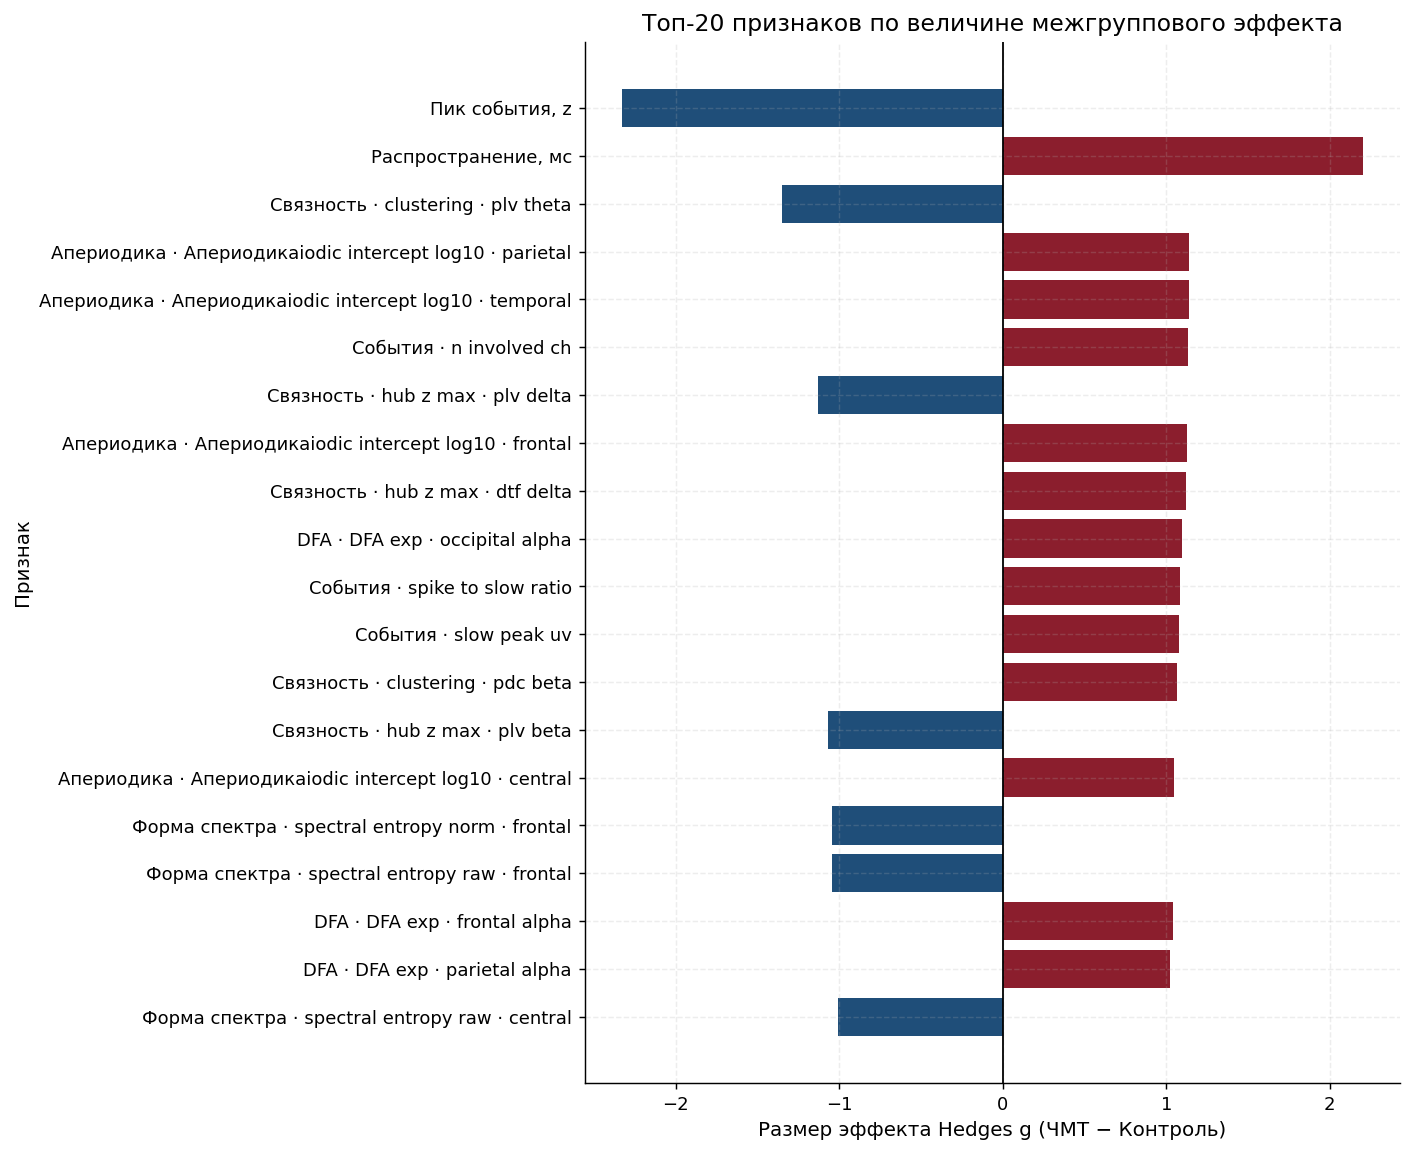


=== PCA EXPLAINED VARIANCE, SUBJECT-LEVEL CLEAN ===
PC1: 0.1373
PC2: 0.0790

=== TOP LOADINGS PC1 ===


,feature,feature_ru,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
107,burst__mean_peak__parietal_alpha,Вспышки · mean peak · parietal alpha,-0.132175,0.054104,0.132175,0.054104
97,burst__mean_amp__parietal_alpha,Вспышки · mean amp · parietal alpha,-0.132085,0.056921,0.132085,0.056921
18,spec_shape__sef95_hz__parietal,Форма спектра · sef95 hz · parietal,0.131580,-0.020270,0.131580,0.020270
33,aper__aperiodic_intercept_log10__parietal,Апериодика · Апериодикаiodic intercept log10 ·...,-0.130511,-0.065911,0.130511,0.065911
103,burst__mean_peak__frontal_alpha,Вспышки · mean peak · frontal alpha,-0.127246,0.079010,0.127246,0.079010
32,aper__aperiodic_intercept_log10__occipital,Апериодика · Апериодикаiodic intercept log10 ·...,-0.126947,-0.053957,0.126947,0.053957
93,burst__mean_amp__frontal_alpha,Вспышки · mean amp · frontal alpha,-0.126775,0.081074,0.126775,0.081074
105,burst__mean_peak__occipital_alpha,Вспышки · mean peak · occipital alpha,-0.123874,0.075709,0.123874,0.075709
95,burst__mean_amp__occipital_alpha,Вспышки · mean amp · occipital alpha,-0.123831,0.081725,0.123831,0.081725
15,spec_shape__sef95_hz__central,Форма спектра · sef95 hz · central,0.123371,0.013473,0.123371,0.013473



=== TOP LOADINGS PC2 ===


,feature,feature_ru,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
176,conn__global_efficiency__plv_alpha,Связность · global efficiency · plv alpha,-0.045407,0.142596,0.045407,0.142596
152,conn__clustering__plv_alpha,Связность · clustering · plv alpha,-0.031861,0.142556,0.031861,0.142556
128,conn__mean_strength__plv_alpha,Связность · mean strength · plv alpha,-0.053788,0.141697,0.053788,0.141697
52,aper__alpha_peak_amp_log10__occipital,Апериодика · Альфа-пик amp log10 · occipital,-0.094994,0.130474,0.094994,0.130474
173,conn__global_efficiency__pdc_beta,Связность · global efficiency · pdc beta,-0.010890,0.129936,0.010890,0.129936
136,conn__clustering__coh_alpha,Связность · clustering · coh alpha,-0.051201,0.127316,0.051201,0.127316
160,conn__global_efficiency__coh_alpha,Связность · global efficiency · coh alpha,-0.055934,0.123103,0.055934,0.123103
116,conn__mean_strength__coh_alpha,Связность · mean strength · coh alpha,-0.062160,0.122719,0.062160,0.122719
301,event__propagation_ms,"Распространение, мс",-0.029936,-0.121738,0.029936,0.121738
53,aper__alpha_peak_amp_log10__parietal,Апериодика · Альфа-пик amp log10 · parietal,-0.104663,0.118990,0.104663,0.118990


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_subject_level_pca_scores_clean.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_subject_level_pca_loadings_clean.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/02_subject_level_pca_pc1_pc2_clean.png


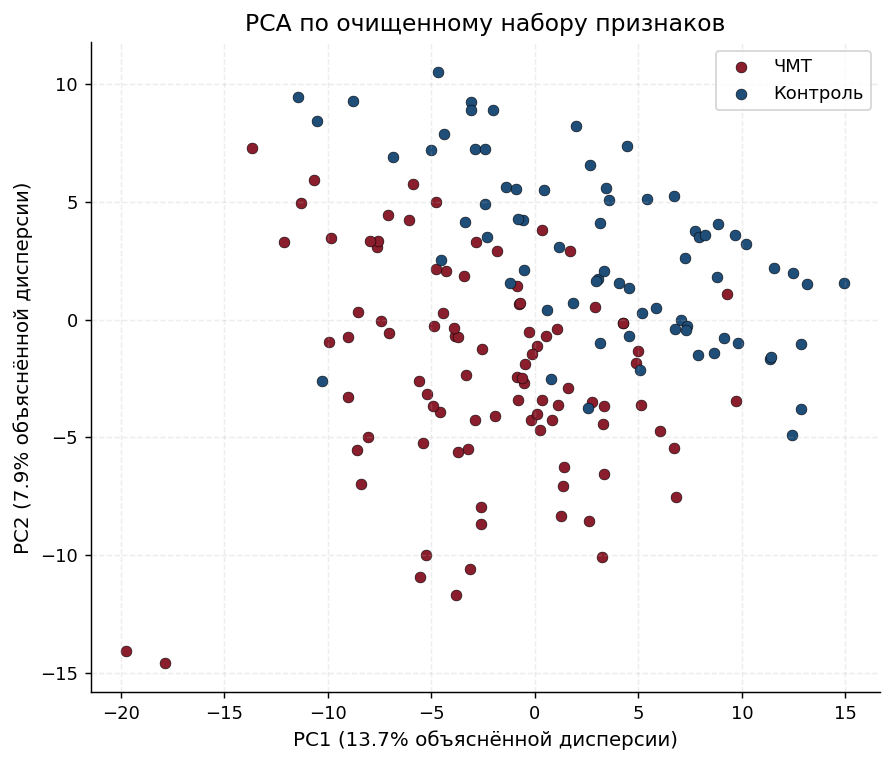

In [8]:
# @title 2.1. Описательный анализ признаков на уровне субъектов: Hedges g и визуализации

def hedges_g_tbi_minus_control(x_control, x_tbi):
    """Hedges g в направлении ЧМТ − Контроль."""
    x_control = pd.Series(x_control).dropna().astype(float)
    x_tbi = pd.Series(x_tbi).dropna().astype(float)

    n0, n1 = len(x_control), len(x_tbi)
    if n0 < 2 or n1 < 2:
        return np.nan

    s0 = x_control.std(ddof=1)
    s1 = x_tbi.std(ddof=1)

    pooled = np.sqrt(
        ((n0 - 1) * s0**2 + (n1 - 1) * s1**2)
        / (n0 + n1 - 2)
    )

    if pooled == 0 or not np.isfinite(pooled):
        return np.nan

    d = (x_tbi.mean() - x_control.mean()) / pooled
    correction = 1 - 3 / (4 * (n0 + n1) - 9)
    return d * correction

rows = []

for col in clean_feature_cols:
    x_control = clean_subject_df.loc[clean_subject_df["y"] == 0, col]
    x_tbi = clean_subject_df.loc[clean_subject_df["y"] == 1, col]

    rows.append({
        "feature": col,
        "feature_ru": clean_feature_label(col),
        "block": detect_block(col),
        "block_ru": clean_feature_label(detect_block(col)),
        "n_tbi": x_tbi.notna().sum(),
        "n_control": x_control.notna().sum(),
        "mean_tbi": x_tbi.mean(),
        "mean_control": x_control.mean(),
        "median_tbi": x_tbi.median(),
        "median_control": x_control.median(),
        "std_tbi": x_tbi.std(ddof=1),
        "std_control": x_control.std(ddof=1),
        "missing_fraction": clean_subject_df[col].isna().mean(),
        "hedges_g_tbi_minus_control": hedges_g_tbi_minus_control(x_control, x_tbi),
    })

effect_df = pd.DataFrame(rows)
effect_df["abs_hedges_g"] = effect_df["hedges_g_tbi_minus_control"].abs()

effect_df = (
    effect_df
    .sort_values("abs_hedges_g", ascending=False)
    .reset_index(drop=True)
)

print("=== TOP FEATURES BY HEDGES g, SUBJECT-LEVEL CLEAN ===")
display(effect_df.head(25))
save_table(effect_df, "02_subject_level_effect_sizes_hedges_g_clean.csv")

block_summary = (
    effect_df
    .groupby(["block", "block_ru"])
    .agg(
        n_features=("feature", "count"),
        mean_abs_g=("abs_hedges_g", "mean"),
        median_abs_g=("abs_hedges_g", "median"),
        max_abs_g=("abs_hedges_g", "max"),
        mean_missing=("missing_fraction", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_g", ascending=False)
)

print("\n=== BLOCK SUMMARY, SUBJECT-LEVEL CLEAN ===")
display(block_summary)
save_table(block_summary, "02_subject_level_block_summary_hedges_g_clean.csv")

# Топ-20 признаков по размеру эффекта
top20 = effect_df.head(20).copy()

plt.figure(figsize=(11, max(6, 0.45 * len(top20))))
colors = [
    COLOR_TBI if v > 0 else COLOR_CONTROL
    for v in top20["hedges_g_tbi_minus_control"][::-1]
]

plt.barh(
    top20["feature_ru"][::-1],
    top20["hedges_g_tbi_minus_control"][::-1],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Размер эффекта Hedges g (ЧМТ − Контроль)")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по величине межгруппового эффекта")
save_figure("02_subject_level_top20_features_hedges_g_clean.png")
plt.show()

# PCA на очищенной subject-level матрице
def zscore_col(s):
    s = pd.Series(s).astype(float)
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mu) / sd

X_pca = clean_subject_df[clean_feature_cols].copy()
X_pca = X_pca.apply(lambda s: s.fillna(s.median()), axis=0)
X_pca = X_pca.apply(zscore_col, axis=0)
Xmat = X_pca.to_numpy(dtype=float)

U, S, Vt = np.linalg.svd(Xmat, full_matrices=False)

pc1 = U[:, 0] * S[0]
pc2 = U[:, 1] * S[1]

explained_var = (S ** 2) / (Xmat.shape[0] - 1)
explained_ratio = explained_var / explained_var.sum()

pca_df = pd.DataFrame({
    "subject_id": clean_subject_df["subject_id"],
    "group": clean_subject_df["group"],
    "_group_pretty": clean_subject_df["_group_pretty"],
    "PC1": pc1,
    "PC2": pc2,
})

loadings = pd.DataFrame({
    "feature": clean_feature_cols,
    "feature_ru": [clean_feature_label(f) for f in clean_feature_cols],
    "PC1_loading": Vt[0, :],
    "PC2_loading": Vt[1, :],
})
loadings["abs_PC1_loading"] = loadings["PC1_loading"].abs()
loadings["abs_PC2_loading"] = loadings["PC2_loading"].abs()

print("\n=== PCA EXPLAINED VARIANCE, SUBJECT-LEVEL CLEAN ===")
print(f"PC1: {explained_ratio[0]:.4f}")
print(f"PC2: {explained_ratio[1]:.4f}")

print("\n=== TOP LOADINGS PC1 ===")
display(loadings.sort_values("abs_PC1_loading", ascending=False).head(15))

print("\n=== TOP LOADINGS PC2 ===")
display(loadings.sort_values("abs_PC2_loading", ascending=False).head(15))

save_table(pca_df, "02_subject_level_pca_scores_clean.csv")
save_table(loadings, "02_subject_level_pca_loadings_clean.csv")

plt.figure(figsize=(7, 6))
for grp, color in [("ЧМТ", COLOR_TBI), ("Контроль", COLOR_CONTROL)]:
    mask = pca_df["_group_pretty"] == grp
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        label=grp,
        color=color,
        edgecolor="black",
        linewidth=0.3,
        alpha=1,
    )

plt.xlabel(f"PC1 ({explained_ratio[0] * 100:.1f}% объяснённой дисперсии)")
plt.ylabel(f"PC2 ({explained_ratio[1] * 100:.1f}% объяснённой дисперсии)")
plt.title("PCA по очищенному набору признаков")
plt.legend()
save_figure("02_subject_level_pca_pc1_pc2_clean.png")
plt.show()


In [9]:
# @title 2.2. Одномерная важность признаков: ROC-AUC, Hedges g, Манна–Уитни, FDR

def bh_fdr_nan_safe(p_values):
    """Benjamini-Hochberg FDR с корректной обработкой NaN."""
    p_values = pd.Series(p_values, dtype=float)
    q = pd.Series(np.nan, index=p_values.index, dtype=float)

    valid = p_values.notna()
    if valid.sum() == 0:
        return q.values

    p = p_values.loc[valid].values
    n = len(p)

    order = np.argsort(p)
    ranked = p[order]

    q_ranked = np.empty(n, dtype=float)
    prev = 1.0

    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q_ranked[i] = prev

    q_values = np.empty(n, dtype=float)
    q_values[order] = np.minimum(q_ranked, 1.0)

    q.loc[valid] = q_values
    return q.values

if clean_subject_df["y"].nunique() < 2:
    raise ValueError(
        "Одномерный ROC-AUC нельзя рассчитать: "
        "в clean_subject_df только один класс."
    )

rows = []
y_arr = clean_subject_df["y"].astype(int).values

for feat in clean_feature_cols:
    x = (
        pd.to_numeric(clean_subject_df[feat], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    valid_mask = x.notna().values & np.isfinite(x.values)

    x_valid = x.values[valid_mask]
    y_valid = y_arr[valid_mask]

    missing_rate = 1 - float(valid_mask.mean())
    std = float(np.nanstd(x_valid)) if len(x_valid) else np.nan

    auc_raw = np.nan
    auc_oriented = np.nan
    g = np.nan
    p = np.nan

    if (
        len(x_valid) >= 5
        and len(np.unique(y_valid)) == 2
        and np.isfinite(std)
        and std > 0
    ):
        x_control = x_valid[y_valid == 0]
        x_tbi = x_valid[y_valid == 1]

        try:
            auc_raw = roc_auc_score(y_valid, x_valid)
            auc_oriented = max(auc_raw, 1 - auc_raw)
        except Exception:
            auc_raw = np.nan
            auc_oriented = np.nan

        try:
            g = hedges_g_tbi_minus_control(x_control, x_tbi)
        except Exception:
            g = np.nan

        try:
            p = mannwhitneyu(
                x_control,
                x_tbi,
                alternative="two-sided",
            ).pvalue
        except Exception:
            p = np.nan

    rows.append({
        "feature": feat,
        "feature_ru": clean_feature_label(feat),
        "block": detect_block(feat),
        "block_ru": clean_feature_label(detect_block(feat)),
        "roc_auc_raw": auc_raw,
        "roc_auc_oriented": auc_oriented,
        "hedges_g_tbi_minus_control": g,
        "abs_hedges_g": abs(g) if pd.notna(g) else np.nan,
        "p_mannwhitney": p,
        "missing_rate": missing_rate,
        "std": std,
    })

univariate_df = pd.DataFrame(rows)
univariate_df["q_fdr"] = bh_fdr_nan_safe(univariate_df["p_mannwhitney"])

univariate_df = (
    univariate_df
    .sort_values(
        ["roc_auc_oriented", "abs_hedges_g"],
        ascending=[False, False],
        na_position="last",
    )
    .reset_index(drop=True)
)

print("Всего признаков в одномерном анализе:", len(univariate_df))
print("ROC-AUC NaN:", int(univariate_df["roc_auc_oriented"].isna().sum()))
print("Классы:")
display(clean_subject_df["_group_pretty"].value_counts())

display(univariate_df.head(30))
save_table(univariate_df, "02_univariate_feature_importance_subject_level_clean.csv")


Всего признаков в одномерном анализе: 302
ROC-AUC NaN: 0
Классы:


,count
_group_pretty,
ЧМТ,92
Контроль,72


,feature,feature_ru,block,block_ru,roc_auc_raw,roc_auc_oriented,hedges_g_tbi_minus_control,abs_hedges_g,p_mannwhitney,missing_rate,std,q_fdr
0,event__z_peak,"Пик события, z",event,События,0.035024,0.964976,-2.330248,2.330248,1.903517e-24,0.0,0.762108,5.748622e-22
1,event__propagation_ms,"Распространение, мс",event,События,0.941274,0.941274,2.203486,2.203486,3.517085e-22,0.0,13.438821,5.310798e-20
2,event__spike_to_slow_ratio,События · spike to slow ratio,event,События,0.920290,0.920290,1.082928,1.082928,2.884725e-20,0.0,0.432235,2.903957e-18
3,conn__clustering__plv_theta,Связность · clustering · plv theta,conn,Связность,0.130888,0.869112,-1.351242,1.351242,5.501388e-16,0.0,0.060434,4.153548e-14
4,event__n_involved_ch,События · n involved ch,event,События,0.840806,0.840806,1.130728,1.130728,6.457639e-14,0.0,3.355112,3.900414e-12
5,event__line_length_uv,События · line length uv,event,События,0.833182,0.833182,0.549790,0.549790,2.646425e-13,0.0,61.116347,1.332034e-11
6,event__slow_peak_uv,События · slow peak uv,event,События,0.819444,0.819444,1.080386,1.080386,2.387722e-12,0.0,12.496849,1.030131e-10
7,event__peak_to_peak_uv,События · peak to peak uv,event,События,0.815972,0.815972,0.972021,0.972021,4.104874e-12,0.0,12.437373,1.549590e-10
8,conn__hub_z_max__plv_delta,Связность · hub z max · plv delta,conn,Связность,0.186745,0.813255,-1.129119,1.129119,6.247890e-12,0.0,0.136389,2.096514e-10
9,aper__aperiodic_intercept_log10__parietal,Апериодика · Апериодикаiodic intercept log10 ·...,aper,Апериодика,0.805707,0.805707,1.142061,1.142061,1.970342e-11,0.0,0.497321,5.533663e-10


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_univariate_feature_importance_subject_level_clean.csv


PosixPath('/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_univariate_feature_importance_subject_level_clean.csv')

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/02_top_univariate_features_roc_auc.png


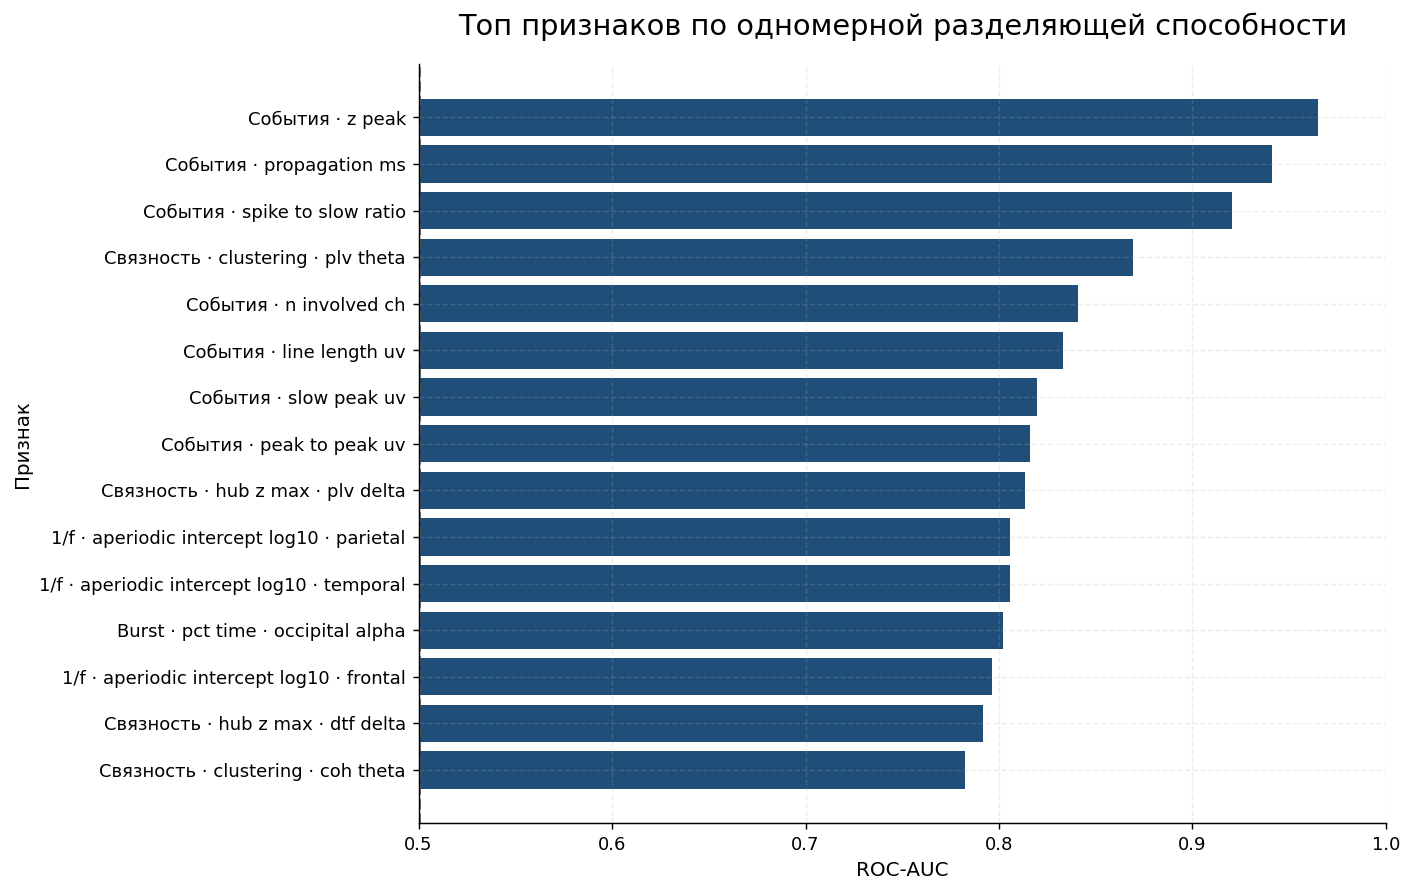

,feature,ROC-AUC
0,event__z_peak,0.964976
1,event__propagation_ms,0.941274
2,event__spike_to_slow_ratio,0.920290
3,conn__clustering__plv_theta,0.869112
4,event__n_involved_ch,0.840806
5,event__line_length_uv,0.833182
6,event__slow_peak_uv,0.819444
7,event__peak_to_peak_uv,0.815972
8,conn__hub_z_max__plv_delta,0.813255
9,aper__aperiodic_intercept_log10__parietal,0.805707


In [10]:
# @title 2.3. Топ признаков по одномерной разделяющей способности

import matplotlib.pyplot as plt

TOP_N = 15

possible_auc_cols = [
    "roc_auc",
    "ROC-AUC",
    "auc",
    "auc_score",
    "roc_auc_score",
    "auc_oriented",
    "roc_auc_oriented",
    "single_feature_auc",
]

auc_col = None

for col in possible_auc_cols:
    if col in univariate_df.columns:
        auc_col = col
        break

if auc_col is None:
    raise ValueError(
        "Не найдена колонка с ROC-AUC. "
        f"Доступные колонки: {univariate_df.columns.tolist()}"
    )

top_df = (
    univariate_df
    .dropna(subset=[auc_col])
    .sort_values(auc_col, ascending=False)
    .head(TOP_N)
    .copy()
)

def prettify_feature_name(name):
    name = str(name)

    replacements = {
        "event__": "События · ",
        "bp__": "Спектр · ",
        "idx__": "Индексы · ",
        "aper__": "1/f · ",
        "conn__": "Связность · ",
        "dfa__": "DFA · ",
        "burst__": "Burst · ",
        "alpha_peak__": "Alpha peak · ",
        "spec_shape__": "Форма спектра · ",
        "__": " · ",
        "_": " ",
    }

    for old, new in replacements.items():
        name = name.replace(old, new)

    return name[:52] + "..." if len(name) > 55 else name

top_df["feature_pretty"] = top_df["feature"].apply(prettify_feature_name)

plt.figure(figsize=(11, 7))
plt.barh(top_df["feature_pretty"][::-1], top_df[auc_col][::-1], color=COLOR_ACCENT)

plt.axvline(0.5, linestyle="--", linewidth=1.5, color=COLOR_GRAY)
plt.xlabel("ROC-AUC")
plt.ylabel("Признак")
plt.title("Топ признаков по одномерной разделяющей способности", fontsize=16, pad=16)
plt.xlim(0.5, 1.0)
save_figure("02_top_univariate_features_roc_auc.png")
plt.show()

display(top_df[["feature", auc_col]].rename(columns={auc_col: "ROC-AUC"}))

,block,block_ru,n_features,median_auc,max_auc,median_abs_g,max_abs_g,n_fdr_005
5,event,События,14,0.781401,0.964976,0.728714,2.330248,13
3,conn,Связность,172,0.574049,0.869112,0.248061,1.351242,63
1,aper,Апериодика,31,0.641002,0.805707,0.412396,1.142061,16
2,burst,Вспышки,40,0.613225,0.802083,0.340957,0.999764,22
6,spec_shape,Форма спектра,15,0.725242,0.782156,0.841016,1.045042,15
4,dfa,DFA,10,0.673913,0.777627,0.567253,1.096982,7
0,alpha_peak,Альфа-пик,15,0.603865,0.714070,0.421467,0.734247,10
7,tfr,Время–частота,5,0.597524,0.672554,0.223909,0.437280,2


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_block_univariate_importance_summary.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/02_block_max_univariate_auc.png


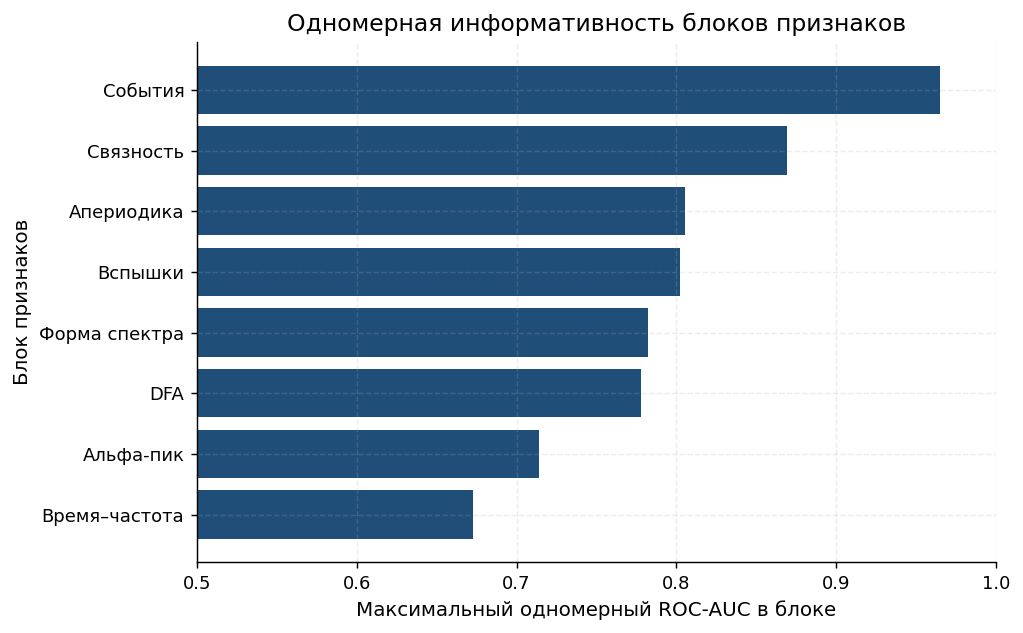

In [11]:
# @title 2.4. Сводка одномерной информативности по блокам признаков

# Автоматически определяем колонку с Hedges g
if "hedges_g_tbi_minus_control" in univariate_df.columns:
    g_col = "hedges_g_tbi_minus_control"
elif "hedges_g" in univariate_df.columns:
    g_col = "hedges_g"
else:
    raise ValueError(
        "Не найдена колонка с Hedges g. "
        f"Доступные колонки: {univariate_df.columns.tolist()}"
    )

block_importance_df = (
    univariate_df
    .groupby(["block", "block_ru"])
    .agg(
        n_features=("feature", "count"),
        median_auc=("roc_auc_oriented", "median"),
        max_auc=("roc_auc_oriented", "max"),
        median_abs_g=(g_col, lambda s: np.nanmedian(np.abs(s))),
        max_abs_g=(g_col, lambda s: np.nanmax(np.abs(s))),
        n_fdr_005=("q_fdr", lambda s: int((s < 0.05).sum())),
    )
    .reset_index()
    .sort_values("max_auc", ascending=False)
)

display(block_importance_df)
save_table(block_importance_df, "02_block_univariate_importance_summary.csv")

plt.figure(figsize=(8, 5))

plot_df = block_importance_df.sort_values("max_auc")

plt.barh(plot_df["block_ru"], plot_df["max_auc"], color=COLOR_ACCENT)
plt.axvline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY)

plt.xlabel("Максимальный одномерный ROC-AUC в блоке")
plt.ylabel("Блок признаков")
plt.title("Одномерная информативность блоков признаков")
plt.xlim(0.5, 1.0)

plt.tight_layout()
save_figure("02_block_max_univariate_auc.png")
plt.show()

In [12]:
# @title 2.5. Проверка связи топ-признаков с QC и числом записей

qc_candidates = [
    c for c in subject_df.columns
    if c in meta_like_cols and c in subject_df.columns and pd.api.types.is_numeric_dtype(subject_df[c])
]

top_features_for_qc = univariate_df.head(30)["feature"].tolist()
qc_rows = []

for feat in top_features_for_qc:
    for qc_col in qc_candidates:
        tmp = subject_df[[feat, qc_col]].dropna()
        if len(tmp) < 10 or tmp[feat].std() == 0 or tmp[qc_col].std() == 0:
            continue
        corr = tmp[feat].corr(tmp[qc_col], method="spearman")
        qc_rows.append({
            "feature": feat,
            "qc_or_meta": qc_col,
            "spearman_r": corr,
            "abs_spearman_r": abs(corr),
        })

qc_corr_df = pd.DataFrame(qc_rows)
if len(qc_corr_df) > 0:
    qc_corr_df = qc_corr_df.sort_values("abs_spearman_r", ascending=False)
    display(qc_corr_df.head(30))
    save_table(qc_corr_df, "02_top_feature_qc_correlations.csv")
else:
    print("Не найдено числовых QC/meta столбцов для проверки корреляций.")

,feature,qc_or_meta,spearman_r,abs_spearman_r
1,event__propagation_ms,n_records_subject,-0.680971,0.680971
0,event__z_peak,n_records_subject,0.653700,0.653700
2,event__spike_to_slow_ratio,n_records_subject,-0.627690,0.627690
5,event__line_length_uv,n_records_subject,-0.572653,0.572653
7,event__peak_to_peak_uv,n_records_subject,-0.550636,0.550636
6,event__slow_peak_uv,n_records_subject,-0.547222,0.547222
3,conn__clustering__plv_theta,n_records_subject,0.534827,0.534827
4,event__n_involved_ch,n_records_subject,-0.529123,0.529123
9,aper__aperiodic_intercept_log10__parietal,n_records_subject,-0.527240,0.527240
8,conn__hub_z_max__plv_delta,n_records_subject,0.514316,0.514316


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/02_top_feature_qc_correlations.csv


## 3. Единые функции оценки моделей

Раздел задаёт одинаковые функции для всех последующих экспериментов: CV/OОF-оценка, holdout-валидация, bootstrap-доверительные интервалы, матрица ошибок, чувствительность, специфичность, PR-AUC, MCC и другие метрики. Дисбаланс классов учитывается стратификацией, весами классов и метриками, устойчивыми к дисбалансу.

In [13]:
# @title 3.1. Метрики качества и bootstrap-доверительные интервалы

def compute_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def compute_npv(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


def compute_metrics(y_true, y_proba, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    y_pred = (y_proba >= threshold).astype(int)

    out = {}
    out["roc_auc"] = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
    out["pr_auc"] = average_precision_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    out["sensitivity"] = recall_score(y_true, y_pred, zero_division=0)
    out["specificity"] = compute_specificity(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["npv"] = compute_npv(y_true, y_pred)
    out["f1"] = f1_score(y_true, y_pred, zero_division=0)
    out["mcc"] = matthews_corrcoef(y_true, y_pred)
    out["threshold"] = threshold
    return out


def bootstrap_ci_for_metrics(y_true, y_proba, threshold=0.5, n_boot=N_BOOT, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    n = len(y_true)
    metric_samples = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        metric_samples.append(compute_metrics(y_true[idx], y_proba[idx], threshold=threshold))

    samples_df = pd.DataFrame(metric_samples)
    rows = []
    point = compute_metrics(y_true, y_proba, threshold=threshold)
    for metric in ["roc_auc", "pr_auc", "accuracy", "balanced_accuracy", "sensitivity", "specificity", "precision", "npv", "f1", "mcc"]:
        vals = samples_df[metric].dropna()
        rows.append({
            "metric": metric,
            "value": point[metric],
            "ci_low": np.percentile(vals, 2.5) if len(vals) else np.nan,
            "ci_high": np.percentile(vals, 97.5) if len(vals) else np.nan,
            "value_ci": format_ci(
                point[metric],
                np.percentile(vals, 2.5) if len(vals) else np.nan,
                np.percentile(vals, 97.5) if len(vals) else np.nan,
            ),
        })
    return pd.DataFrame(rows)

In [14]:
# @title 3.2. Модели с учётом дисбаланса классов

def make_model(model_name):
    if model_name == "logreg":
        clf = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=5000,
        )
    elif model_name == "rf":
        clf = RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    elif model_name == "svc_rbf":
        clf = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")

    # Scaler оставлен единообразно; для деревьев он не обязателен, но не меняет корректность pipeline.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", clf),
    ])

MODEL_ORDER = ["logreg", "rf", "svc_rbf"]

MODEL_LABELS = {
    "logreg": "Логистическая регрессия",
    "rf": "Случайный лес",
    "svc_rbf": "SVM с RBF-ядром",
}

MODEL_LABELS_SHORT = {
    "logreg": "Логистическая\nрегрессия",
    "rf": "Случайный\nлес",
    "svc_rbf": "SVM\nRBF",
}

for name in MODEL_LABELS:
    print(name, "→", MODEL_LABELS[name])


logreg → Логистическая регрессия
rf → Случайный лес
svc_rbf → SVM с RBF-ядром


In [15]:
# @title 3.3. Единая CV/OОF-оценка модели

def evaluate_model_cv(
    df,
    features,
    model_name="logreg",
    label_col="y",
    threshold=0.5,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    model_label=None,
    feature_set_name=None,
):
    X = df[features].copy()
    y = df[label_col].astype(int).reset_index(drop=True)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    pipe = make_model(model_name)

    oof_proba = cross_val_predict(
        pipe,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    metric_ci = bootstrap_ci_for_metrics(y, oof_proba, threshold=threshold)

    # fold-wise метрики для оценки вариативности между фолдами
    fold_rows = []
    fold_counts = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        pipe_fold = clone(pipe)
        pipe_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = pipe_fold.predict_proba(X.iloc[test_idx])[:, 1]
        fold_metrics = compute_metrics(y.iloc[test_idx], proba, threshold=threshold)
        fold_metrics.update({
            "fold": fold,
            "model": model_name,
            "model_ru": model_label or MODEL_LABELS.get(model_name, model_name),
            "feature_set": feature_set_name,
            "n_features": len(features),
        })
        fold_rows.append(fold_metrics)
        fold_counts.append({
            "fold": fold,
            "n_train_total": len(train_idx),
            "n_train_control": int((y.iloc[train_idx] == 0).sum()),
            "n_train_tbi": int((y.iloc[train_idx] == 1).sum()),
            "n_test_total": len(test_idx),
            "n_test_control": int((y.iloc[test_idx] == 0).sum()),
            "n_test_tbi": int((y.iloc[test_idx] == 1).sum()),
        })

    metric_ci.insert(0, "validation", "cv_oof")
    metric_ci.insert(0, "feature_set", feature_set_name)
    metric_ci.insert(0, "n_features", len(features))
    metric_ci.insert(0, "model_ru", model_label or MODEL_LABELS.get(model_name, model_name))
    metric_ci.insert(0, "model", model_name)

    fold_df = pd.DataFrame(fold_rows)
    fold_counts_df = pd.DataFrame(fold_counts)

    return {
        "metric_ci": metric_ci,
        "fold_metrics": fold_df,
        "fold_counts": fold_counts_df,
        "oof_proba": oof_proba,
        "y_true": y.values,
        "features": features,
    }

In [16]:
# @title 3.4. Единая holdout-оценка модели

def evaluate_model_holdout(
    df,
    features,
    model_name="logreg",
    label_col="y",
    threshold=0.5,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    model_label=None,
    feature_set_name=None,
):
    X = df[features].copy()
    y = df[label_col].astype(int).reset_index(drop=True)

    idx_all = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        idx_all,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    pipe = make_model(model_name)
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = pipe.predict_proba(X.iloc[test_idx])[:, 1]

    metric_ci = bootstrap_ci_for_metrics(y.iloc[test_idx], proba, threshold=threshold)
    metric_ci.insert(0, "validation", "holdout")
    metric_ci.insert(0, "feature_set", feature_set_name)
    metric_ci.insert(0, "n_features", len(features))
    metric_ci.insert(0, "model_ru", model_label or MODEL_LABELS.get(model_name, model_name))
    metric_ci.insert(0, "model", model_name)

    counts = pd.DataFrame([{
        "validation": "holdout",
        "n_train_total": len(train_idx),
        "n_train_control": int((y.iloc[train_idx] == 0).sum()),
        "n_train_tbi": int((y.iloc[train_idx] == 1).sum()),
        "n_test_total": len(test_idx),
        "n_test_control": int((y.iloc[test_idx] == 0).sum()),
        "n_test_tbi": int((y.iloc[test_idx] == 1).sum()),
    }])

    return {
        "metric_ci": metric_ci,
        "counts": counts,
        "holdout_proba": proba,
        "y_true": y.iloc[test_idx].values,
        "test_idx": test_idx,
        "train_idx": train_idx,
        "features": features,
        "fitted_model": pipe,
    }

In [17]:
# @title 3.5. Функции визуализации ROC, PR, calibration и матрицы ошибок

from matplotlib.colors import LinearSegmentedColormap

CONFUSION_CMAP = LinearSegmentedColormap.from_list(
    "confusion_blue_red",
    ["#FFFFFF", COLOR_CONTROL, COLOR_TBI],
)

METRIC_RU = {
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "balanced_accuracy": "Balanced accuracy",
    "accuracy": "Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "precision": "Precision",
    "npv": "NPV",
    "f1": "F1",
    "mcc": "MCC",
}

VALIDATION_RU = {
    "cv_oof": "CV/OOF",
    "holdout": "Отложенная выборка",
    "cv_oof_topk_train_only": "CV/OOF, top-k внутри train",
    "nested_cv_top2_event": "Nested CV, top-2 event",
}

VALIDATION_COLORS = {
    "cv_oof": COLOR_CONTROL,
    "holdout": COLOR_TBI,
    "cv_oof_topk_train_only": COLOR_CONTROL,
    "nested_cv_top2_event": COLOR_TBI,
}

MODEL_COLORS = {
    "logreg": COLOR_CONTROL,
    "rf": COLOR_GRAY,
    "svc_rbf": COLOR_TBI,
}


def apply_vkr_axes_style(ax, grid_axis="y"):
    """Единый стиль осей для рисунков ВКР."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.22, linestyle="--")
    return ax


def plot_roc_curve_ru(y_true, y_proba, title, filename):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2.2, color=COLOR_TBI, label=f"ROC-AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color=COLOR_GRAY, label="Случайный уровень")
    ax.set_xlabel("Доля ложноположительных классификаций")
    ax.set_ylabel("Чувствительность")
    ax.set_title(title)
    ax.legend(loc="lower right", frameon=False)
    apply_vkr_axes_style(ax, grid_axis="both")
    save_figure(filename)
    plt.show()


def plot_pr_curve_ru(y_true, y_proba, title, filename):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, linewidth=2.2, color=COLOR_TBI, label=f"PR-AUC = {pr_auc:.3f}")
    ax.set_xlabel("Чувствительность")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(loc="lower left", frameon=False)
    apply_vkr_axes_style(ax, grid_axis="both")
    save_figure(filename)
    plt.show()


def plot_confusion_matrix_ru(y_true, y_proba, title, filename, threshold=0.5):
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.7, 5.1))
    im = ax.imshow(cm, interpolation="nearest", cmap=CONFUSION_CMAP)
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Число субъектов", rotation=270, labelpad=14)
    classes = ["Контроль", "ЧМТ"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    max_val = cm.max() if cm.size else 0
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > max_val / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=15, fontweight="bold", color=color)
    ax.grid(False)
    save_figure(filename)
    plt.show()


def plot_calibration_ru(y_true, y_proba, title, filename, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy="quantile")
    brier = brier_score_loss(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2.2, color=COLOR_TBI, label=f"Модель; Brier = {brier:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color=COLOR_GRAY, label="Идеальная калибровка")
    ax.set_xlabel("Предсказанная вероятность класса ЧМТ")
    ax.set_ylabel("Наблюдаемая частота класса ЧМТ")
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=False)
    apply_vkr_axes_style(ax, grid_axis="both")
    save_figure(filename)
    plt.show()


def evaluate_feature_set_all_models(df, features, feature_set_name, run_holdout=True):
    """Единая обёртка: один набор признаков оценивается всеми тремя алгоритмами."""
    results = []
    fold_metrics = []
    counts = []
    cv_objects = {}
    holdout_objects = {}

    for model_name in MODEL_ORDER:
        cv_res = evaluate_model_cv(
            df,
            features,
            model_name=model_name,
            feature_set_name=feature_set_name,
        )
        results.append(cv_res["metric_ci"])
        fold_metrics.append(cv_res["fold_metrics"])
        counts.append(cv_res["fold_counts"].assign(model=model_name, feature_set=feature_set_name))
        cv_objects[model_name] = cv_res

        if run_holdout:
            hold_res = evaluate_model_holdout(
                df,
                features,
                model_name=model_name,
                feature_set_name=feature_set_name,
            )
            results.append(hold_res["metric_ci"])
            counts.append(hold_res["counts"].assign(model=model_name, feature_set=feature_set_name))
            holdout_objects[model_name] = hold_res

    return {
        "metrics": pd.concat(results, ignore_index=True),
        "fold_metrics": pd.concat(fold_metrics, ignore_index=True) if fold_metrics else pd.DataFrame(),
        "counts": pd.concat(counts, ignore_index=True) if counts else pd.DataFrame(),
        "cv": cv_objects,
        "holdout": holdout_objects,
    }


## 3.6. Первичная модельная оценка информативности полного признакового пространства

Этот блок является разведочным: он показывает, какие признаки выделяются при анализе полного очищенного ML-пространства. Он не заменяет последующую subject-level CV-оценку компактной модели и не используется как единственный источник отбора признаков для итоговых выводов.

In [18]:
# @title 3.6.1. Полное очищенное признаковое пространство: CV/OОF и holdout для трёх алгоритмов

FULL_FEATURE_SET_NAME = "all_clean_features"
full_feature_space_features = clean_feature_cols.copy()

print("Полное очищенное признаковое пространство:")
print("Число признаков:", len(full_feature_space_features))
print("n_records_subject входит в признаки:", "n_records_subject" in full_feature_space_features)

if len(full_feature_space_features) == 0:
    print("Нет признаков для оценки полного пространства.")
    full_feature_space_metrics_df = pd.DataFrame()
    full_feature_space_eval = None
    full_feature_space_cv_results = {}
    full_feature_space_holdout_results = {}
else:
    full_feature_space_eval = evaluate_feature_set_all_models(
        subject_df,
        full_feature_space_features,
        feature_set_name=FULL_FEATURE_SET_NAME,
        run_holdout=True,
    )

    full_feature_space_metrics_df = full_feature_space_eval["metrics"]
    full_feature_space_cv_results = full_feature_space_eval["cv"]
    full_feature_space_holdout_results = full_feature_space_eval["holdout"]

    full_feature_space_main_table = full_feature_space_metrics_df[
        full_feature_space_metrics_df["metric"].isin([
            "roc_auc",
            "pr_auc",
            "balanced_accuracy",
            "accuracy",
            "sensitivity",
            "specificity",
            "f1",
            "mcc",
        ])
    ].pivot_table(
        index=["validation", "model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value_ci",
        aggfunc="first",
    ).reset_index()

    display(full_feature_space_main_table)
    display(full_feature_space_eval["counts"])

    save_table(full_feature_space_metrics_df, "03_full_feature_space_metrics_all_models.csv")
    save_table(full_feature_space_main_table, "03_full_feature_space_main_table_all_models.csv")
    save_table(full_feature_space_eval["counts"], "03_full_feature_space_counts_all_models.csv")


Полное очищенное признаковое пространство:
Число признаков: 302
n_records_subject входит в признаки: False


metric,validation,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
0,cv_oof,logreg,Логистическая регрессия,all_clean_features,302,0.933 [0.890; 0.970],0.939 [0.902; 0.973],0.937 [0.897; 0.973],0.871 [0.797; 0.941],0.992 [0.981; 0.999],0.987 [0.967; 0.999],0.891 [0.825; 0.955],0.986 [0.955; 1.000]
1,cv_oof,rf,Случайный лес,all_clean_features,302,0.976 [0.951; 0.994],0.975 [0.949; 0.995],0.978 [0.955; 0.995],0.950 [0.900; 0.988],0.998 [0.992; 1.000],0.997 [0.990; 1.000],0.978 [0.944; 1.000],0.972 [0.929; 1.000]
2,cv_oof,svc_rbf,SVM с RBF-ядром,all_clean_features,302,0.945 [0.902; 0.976],0.944 [0.901; 0.976],0.951 [0.914; 0.980],0.888 [0.804; 0.951],0.991 [0.979; 0.998],0.987 [0.972; 0.997],0.957 [0.911; 0.990],0.931 [0.862; 0.985]
3,holdout,logreg,Логистическая регрессия,all_clean_features,302,0.939 [0.848; 1.000],0.947 [0.868; 1.000],0.944 [0.848; 1.000],0.885 [0.729; 1.000],1.000 [1.000; 1.000],1.000 [1.000; 1.000],0.895 [0.737; 1.000],1.000 [1.000; 1.000]
4,holdout,rf,Случайный лес,all_clean_features,302,0.909 [0.818; 1.000],0.902 [0.786; 1.000],0.923 [0.818; 1.000],0.814 [0.587; 1.000],0.995 [0.976; 1.000],0.992 [0.965; 1.000],0.947 [0.824; 1.000],0.857 [0.643; 1.000]
5,holdout,svc_rbf,SVM с RBF-ядром,all_clean_features,302,0.939 [0.848; 1.000],0.938 [0.841; 1.000],0.947 [0.857; 1.000],0.876 [0.694; 1.000],0.995 [0.975; 1.000],0.992 [0.966; 1.000],0.947 [0.818; 1.000],0.929 [0.769; 1.000]


,fold,n_train_total,n_train_control,n_train_tbi,n_test_total,n_test_control,n_test_tbi,model,feature_set,validation
0,1.0,131,57,74,33,15,18,logreg,all_clean_features,NaN
1,2.0,131,57,74,33,15,18,logreg,all_clean_features,NaN
2,3.0,131,58,73,33,14,19,logreg,all_clean_features,NaN
3,4.0,131,58,73,33,14,19,logreg,all_clean_features,NaN
4,5.0,132,58,74,32,14,18,logreg,all_clean_features,NaN
5,NaN,131,58,73,33,14,19,logreg,all_clean_features,holdout
6,1.0,131,57,74,33,15,18,rf,all_clean_features,NaN
7,2.0,131,57,74,33,15,18,rf,all_clean_features,NaN
8,3.0,131,58,73,33,14,19,rf,all_clean_features,NaN
9,4.0,131,58,73,33,14,19,rf,all_clean_features,NaN


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_metrics_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_main_table_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_counts_all_models.csv


Model-based importance: Логистическая регрессия
Model-based importance: Случайный лес
Model-based importance: SVM с RBF-ядром


,model,model_ru,feature_set,n_features,validation,roc_auc,pr_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision,npv,f1,mcc,threshold
0,logreg,Логистическая регрессия,all_clean_features,302,exploratory_holdout,1.000000,1.000000,0.939394,0.947368,0.894737,1.000000,1.000000,0.875000,0.944444,0.884813,0.5
1,rf,Случайный лес,all_clean_features,302,exploratory_holdout,0.992481,0.994987,0.909091,0.902256,0.947368,0.857143,0.900000,0.923077,0.923077,0.813741,0.5
2,svc_rbf,SVM с RBF-ядром,all_clean_features,302,exploratory_holdout,0.992481,0.994598,0.939394,0.937970,0.947368,0.928571,0.947368,0.928571,0.947368,0.875940,0.5


,model_ru,rank_in_model,feature,block_ru,importance_mean,importance_std,logreg_coef
0,Логистическая регрессия,1,event__z_peak,События,0.000877,0.002509,-0.701686
1,Логистическая регрессия,2,conn__small_worldness__pdc_delta,Связность,0.000125,0.000675,0.236923
2,Логистическая регрессия,2,conn__asymmetry__dtf_beta,Связность,0.000125,0.000675,-0.435778
3,Логистическая регрессия,4,alpha_peak__paf_hz__central,Альфа-пик,0.000000,0.000000,0.045377
4,Логистическая регрессия,4,alpha_peak__paf_hz__frontal,Альфа-пик,0.000000,0.000000,-0.142180
...,...,...,...,...,...,...,...
624,SVM с RBF-ядром,5,spec_shape__sef95_hz__frontal,Форма спектра,0.000000,0.000000,-0.119777
625,SVM с RBF-ядром,5,spec_shape__sef95_hz__occipital,Форма спектра,0.000000,0.000000,-0.014326
626,SVM с RBF-ядром,5,spec_shape__sef95_hz__parietal,Форма спектра,0.000000,0.000000,0.001524
627,SVM с RBF-ядром,5,spec_shape__sef95_hz__temporal,Форма спектра,0.000000,0.000000,0.132605


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_permutation_importance_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_importance_model_metrics.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/03_full_feature_importance_top_logreg.png


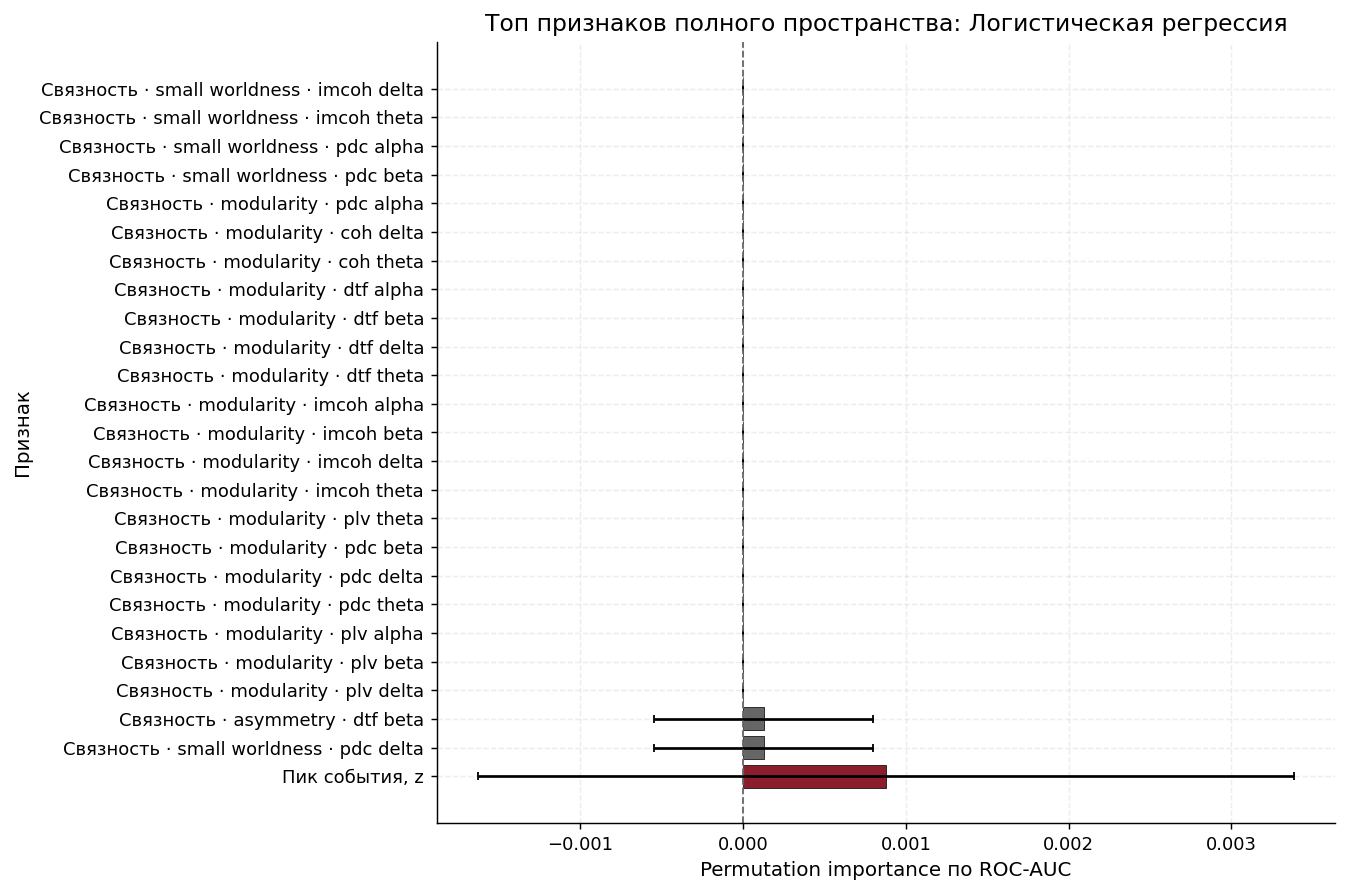

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/03_full_feature_importance_top_rf.png


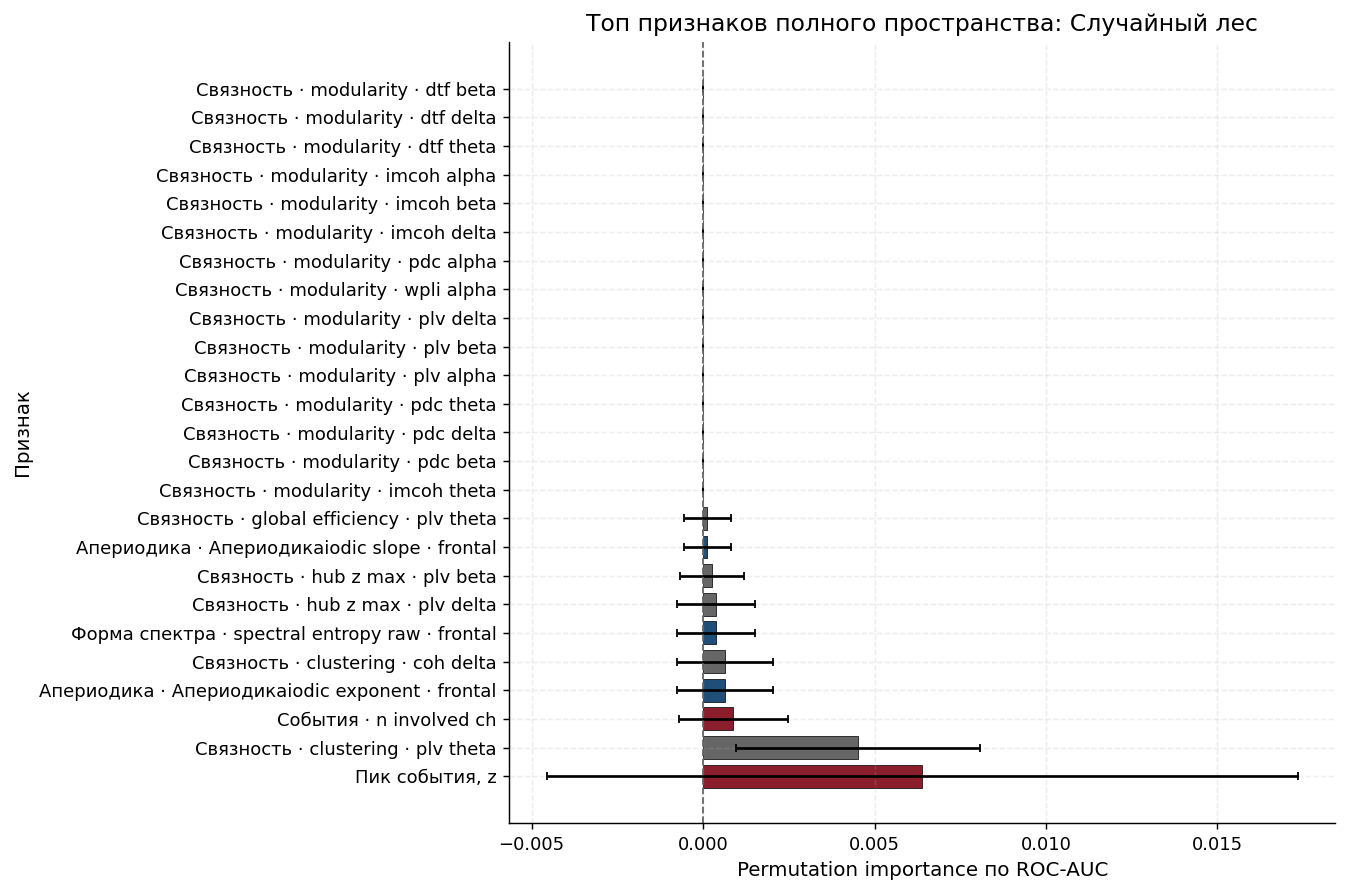

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/03_full_feature_importance_top_svc_rbf.png


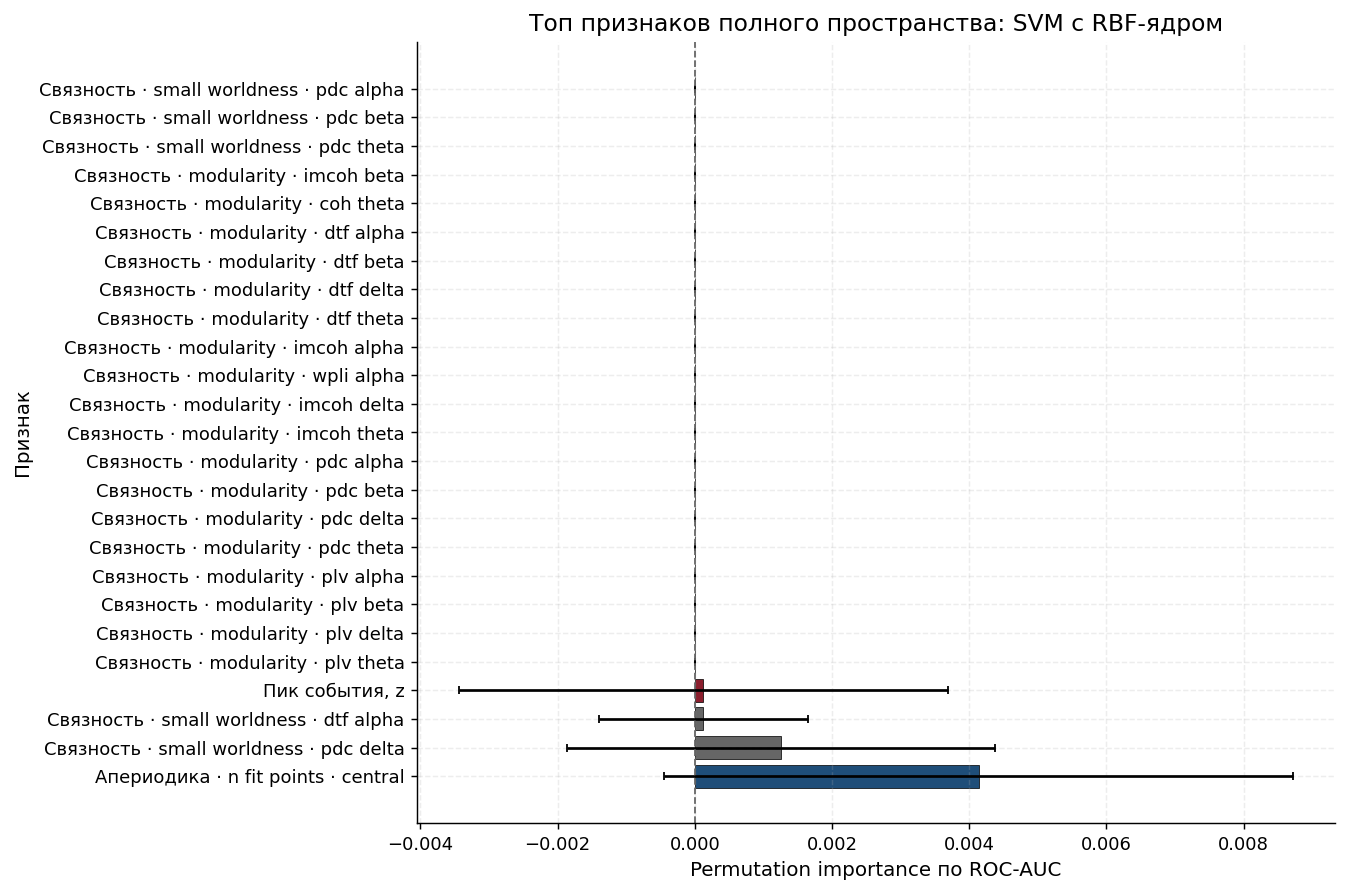

In [19]:
# @title 3.6.2. Какие признаки выбирают модели: permutation importance на полном пространстве

# Разведочный model-based ranking.
# Важно: этот блок НЕ используется как финальная оценка качества.
# Строгая оценка качества выполняется ниже через subject-level CV/OOF.

FULL_IMPORTANCE_TOP_N = 25
FULL_IMPORTANCE_N_REPEATS = 30

def get_feature_block_color(block):
    """Единая цветовая логика для блоков признаков."""
    if block == "event":
        return COLOR_TBI
    if block in ["spectral_baseline", "bp", "idx", "alpha_peak", "aper", "spec_shape"]:
        return COLOR_CONTROL
    return COLOR_GRAY


def extract_logreg_coefficients_from_pipeline(pipe, features):
    """Коэффициенты логистической регрессии после стандартизации признаков внутри pipeline."""
    if not hasattr(pipe, "named_steps"):
        return pd.DataFrame()
    if "clf" not in pipe.named_steps:
        return pd.DataFrame()
    clf = pipe.named_steps["clf"]
    if not hasattr(clf, "coef_"):
        return pd.DataFrame()

    coef = np.ravel(clf.coef_)
    if len(coef) != len(features):
        return pd.DataFrame()

    return pd.DataFrame({
        "feature": features,
        "logreg_coef": coef,
        "logreg_abs_coef": np.abs(coef),
    })


def model_based_full_feature_importance(
    df,
    features,
    models=MODEL_ORDER,
    n_repeats=FULL_IMPORTANCE_N_REPEATS,
    random_state=RANDOM_STATE,
):
    """Оценивает permutation importance всех очищенных признаков для трёх моделей на одной holdout-разбивке."""
    X = df[features].copy()
    y = df["y"].astype(int).reset_index(drop=True)

    idx_all = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        idx_all,
        test_size=HOLDOUT_SIZE,
        stratify=y,
        random_state=random_state,
    )

    rows = []
    metric_rows = []
    coef_parts = []

    for model_name in models:
        print(f"Model-based importance: {MODEL_LABELS.get(model_name, model_name)}")

        pipe = make_model(model_name)
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])

        proba = pipe.predict_proba(X.iloc[test_idx])[:, 1]
        metric = compute_metrics(y.iloc[test_idx], proba, threshold=0.5)

        metric_rows.append({
            "model": model_name,
            "model_ru": MODEL_LABELS.get(model_name, model_name),
            "feature_set": "all_clean_features",
            "n_features": len(features),
            "validation": "exploratory_holdout",
            **metric,
        })

        # Коэффициенты сохраняем только для логистической регрессии.
        if model_name == "logreg":
            coef_df = extract_logreg_coefficients_from_pipeline(pipe, features)
            if len(coef_df) > 0:
                coef_df["model"] = model_name
                coef_df["model_ru"] = MODEL_LABELS.get(model_name, model_name)
                coef_parts.append(coef_df)

        perm = permutation_importance(
            pipe,
            X.iloc[test_idx],
            y.iloc[test_idx],
            scoring="roc_auc",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )

        for feat, imp_mean, imp_std in zip(features, perm.importances_mean, perm.importances_std):
            rows.append({
                "model": model_name,
                "model_ru": MODEL_LABELS.get(model_name, model_name),
                "feature": feat,
                "feature_ru": clean_feature_label(feat),
                "block": detect_block(feat),
                "block_ru": clean_feature_label(detect_block(feat)),
                "importance_mean": imp_mean,
                "importance_std": imp_std,
                "feature_set": "all_clean_features",
                "validation": "exploratory_holdout",
                "n_repeats": n_repeats,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
            })

    importance_df = pd.DataFrame(rows)
    metric_df = pd.DataFrame(metric_rows)

    if coef_parts:
        coef_all_df = pd.concat(coef_parts, ignore_index=True)
        importance_df = importance_df.merge(
            coef_all_df[["feature", "logreg_coef", "logreg_abs_coef"]],
            on="feature",
            how="left",
        )
    else:
        importance_df["logreg_coef"] = np.nan
        importance_df["logreg_abs_coef"] = np.nan

    importance_df["rank_in_model"] = (
        importance_df
        .groupby("model")["importance_mean"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    importance_df = importance_df.sort_values(["model", "rank_in_model"]).reset_index(drop=True)

    return importance_df, metric_df


if len(full_feature_space_features) == 0:
    full_model_importance_df = pd.DataFrame()
    full_model_importance_metrics_df = pd.DataFrame()
else:
    full_model_importance_df, full_model_importance_metrics_df = model_based_full_feature_importance(
        subject_df,
        full_feature_space_features,
        models=MODEL_ORDER,
        n_repeats=FULL_IMPORTANCE_N_REPEATS,
        random_state=RANDOM_STATE,
    )

    display(full_model_importance_metrics_df)
    display(
        full_model_importance_df
        .groupby("model", group_keys=False)
        .head(FULL_IMPORTANCE_TOP_N)
        [["model_ru", "rank_in_model", "feature", "block_ru", "importance_mean", "importance_std", "logreg_coef"]]
    )

    save_table(full_model_importance_df, "03_full_feature_space_permutation_importance_all_models.csv")
    save_table(full_model_importance_metrics_df, "03_full_feature_space_importance_model_metrics.csv")

    for model_name in MODEL_ORDER:
        top_df = (
            full_model_importance_df[full_model_importance_df["model"] == model_name]
            .sort_values("importance_mean", ascending=False)
            .head(FULL_IMPORTANCE_TOP_N)
            .copy()
        )
        if len(top_df) == 0:
            continue

        top_df["feature_plot"] = top_df["feature_ru"].apply(
            lambda s: str(s)[:58] + "..." if len(str(s)) > 61 else str(s)
        )
        colors = top_df["block"].map(get_feature_block_color)

        fig, ax = plt.subplots(figsize=(10.5, max(5.5, 0.28 * len(top_df))))
        y_pos = np.arange(len(top_df))[::-1]
        ax.barh(
            y_pos,
            top_df["importance_mean"].values[::-1],
            xerr=top_df["importance_std"].values[::-1],
            color=colors.values[::-1],
            edgecolor="black",
            linewidth=0.4,
            capsize=2,
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_df["feature_plot"].values[::-1])
        ax.set_xlabel("Permutation importance по ROC-AUC")
        ax.set_ylabel("Признак")
        ax.set_title(f"Топ признаков полного пространства: {MODEL_LABELS.get(model_name, model_name)}")
        ax.axvline(0, linestyle="--", linewidth=1, color=COLOR_GRAY)
        apply_vkr_axes_style(ax, grid_axis="x")
        save_figure(f"03_full_feature_importance_top_{model_name}.png")
        plt.show()


Consensus top-N = 30
Признаки, вошедшие в top-N минимум у двух алгоритмов:


,feature,feature_ru,block,block_ru,n_models_top_n,mean_rank,best_rank,mean_importance,max_importance,models_top_n,roc_auc_oriented,hedges_g_tbi_minus_control,abs_hedges_g,q_fdr
0,event__z_peak,"Пик события, z",event,События,3,1.666667,1,0.002464,0.006391,Логистическая регрессия; Случайный лес; SVM с ...,0.964976,-2.330248,2.330248,5.748622e-22
1,aper__n_fit_points__central,Апериодика · n fit points · central,aper,Апериодика,3,5.333333,1,0.001378,0.004135,Логистическая регрессия; Случайный лес; SVM с ...,0.510870,0.186586,0.186586,3.083829e-01
2,conn__clustering__plv_theta,Связность · clustering · plv theta,conn,Связность,3,3.666667,2,0.001504,0.004511,Логистическая регрессия; Случайный лес; SVM с ...,0.869112,-1.351242,1.351242,4.153548e-14
3,conn__small_worldness__pdc_delta,Связность · small worldness · pdc delta,conn,Связность,3,5.000000,2,0.000459,0.001253,Логистическая регрессия; Случайный лес; SVM с ...,0.623943,0.471492,0.471492,4.887030e-03
4,conn__asymmetry__dtf_beta,Связность · asymmetry · dtf beta,conn,Связность,3,6.000000,2,0.000042,0.000125,Логистическая регрессия; Случайный лес; SVM с ...,0.711353,-0.783999,0.783999,1.692442e-05
5,event__n_involved_ch,События · n involved ch,event,События,3,4.000000,3,0.000292,0.000877,Логистическая регрессия; Случайный лес; SVM с ...,0.840806,1.130728,1.130728,3.900414e-12
6,conn__small_worldness__dtf_alpha,Связность · small worldness · dtf alpha,conn,Связность,3,6.000000,3,0.000042,0.000125,Логистическая регрессия; Случайный лес; SVM с ...,0.611111,-0.121719,0.121719,2.462850e-02
7,aper__aperiodic_exponent__frontal,Апериодика · Апериодикаiodic exponent · frontal,aper,Апериодика,3,4.333333,4,0.000209,0.000627,Логистическая регрессия; Случайный лес; SVM с ...,0.775815,0.969332,0.969332,1.876918e-08
8,conn__clustering__coh_delta,Связность · clustering · coh delta,conn,Связность,3,4.333333,4,0.000209,0.000627,Логистическая регрессия; Случайный лес; SVM с ...,0.687349,-0.324359,0.324359,1.490956e-04
9,conn__hub_z_max__plv_delta,Связность · hub z max · plv delta,conn,Связность,3,5.000000,4,0.000125,0.000376,Логистическая регрессия; Случайный лес; SVM с ...,0.813255,-1.129119,1.129119,2.096514e-10


Положение признаков компактной событийной модели в consensus-рейтинге:


,feature,feature_ru,block,block_ru,n_models_top_n,mean_rank,best_rank,mean_importance,max_importance,models_top_n,roc_auc_oriented,hedges_g_tbi_minus_control,abs_hedges_g,q_fdr
0,event__z_peak,"Пик события, z",event,События,3,1.666667,1,0.002464,0.006391,Логистическая регрессия; Случайный лес; SVM с ...,0.964976,-2.330248,2.330248,5.748622e-22
301,event__propagation_ms,"Распространение, мс",event,События,1,202.000000,4,-0.001044,0.000000,Логистическая регрессия,0.941274,2.203486,2.203486,5.310798e-20


Представленность блоков среди top-N признаков каждого алгоритма:


,model,model_ru,block,block_ru,n_features_top_n
3,logreg,Логистическая регрессия,conn,Связность,172
2,logreg,Логистическая регрессия,burst,Вспышки,40
1,logreg,Логистическая регрессия,aper,Апериодика,31
0,logreg,Логистическая регрессия,alpha_peak,Альфа-пик,15
6,logreg,Логистическая регрессия,spec_shape,Форма спектра,15
5,logreg,Логистическая регрессия,event,События,14
4,logreg,Логистическая регрессия,dfa,DFA,10
7,logreg,Логистическая регрессия,tfr,Время–частота,5
11,rf,Случайный лес,conn,Связность,172
10,rf,Случайный лес,burst,Вспышки,40


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_consensus_ranking.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_full_feature_space_top_blocks_by_model.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/03_event_core_features_in_full_space_consensus.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/03_full_feature_space_consensus_top_features.png


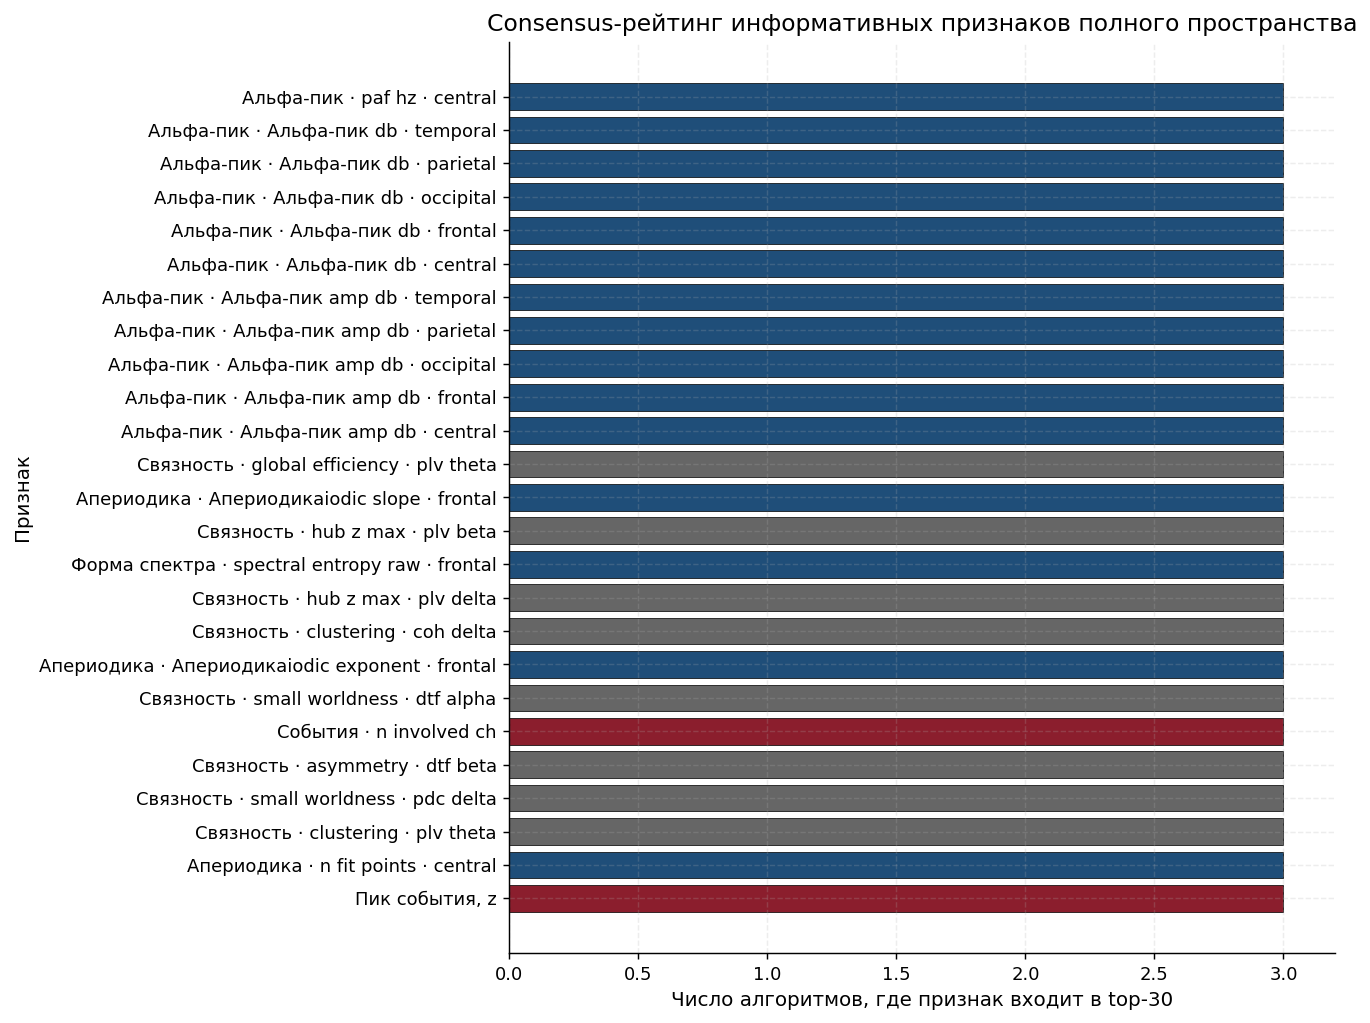

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/03_full_feature_space_top_blocks_by_model.png


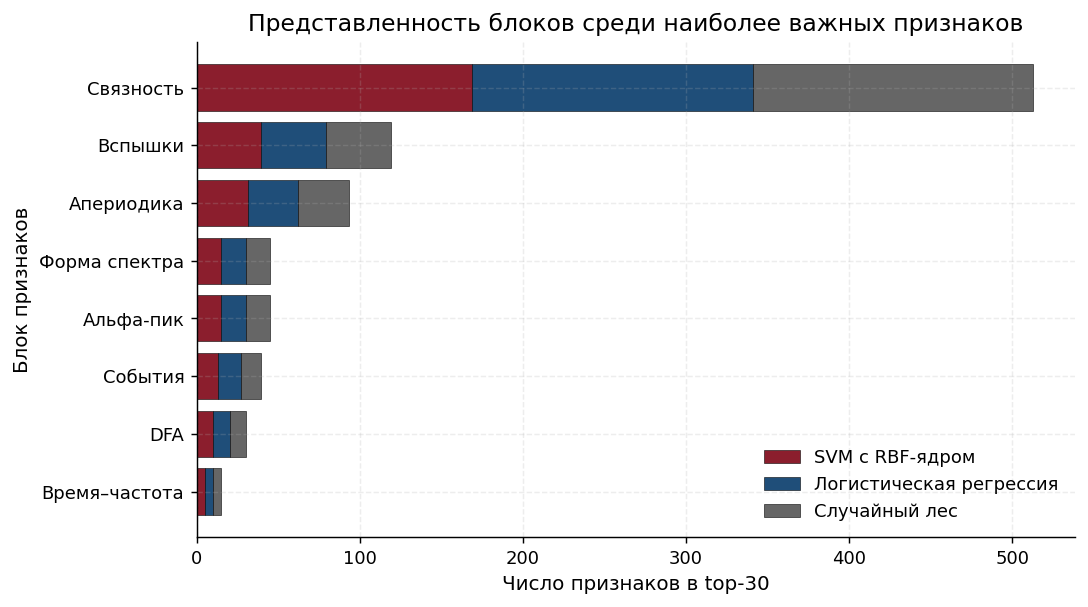

In [20]:
# @title 3.6.3. Consensus-рейтинг: какие признаки выбираются несколькими алгоритмами

CONSENSUS_TOP_N = 30

if "full_model_importance_df" not in globals() or len(full_model_importance_df) == 0:
    print("Сначала нужно выполнить model-based importance на полном признаковом пространстве.")
    full_consensus_importance_df = pd.DataFrame()
    full_consensus_block_summary_df = pd.DataFrame()
    event_core_consensus_df = pd.DataFrame()
else:
    top_flags_df = full_model_importance_df.copy()
    top_flags_df["is_top_n"] = top_flags_df["rank_in_model"] <= CONSENSUS_TOP_N

    full_consensus_importance_df = (
        top_flags_df
        .groupby(["feature", "feature_ru", "block", "block_ru"], as_index=False)
        .agg(
            n_models_top_n=("is_top_n", "sum"),
            mean_rank=("rank_in_model", "mean"),
            best_rank=("rank_in_model", "min"),
            mean_importance=("importance_mean", "mean"),
            max_importance=("importance_mean", "max"),
            models_top_n=("model_ru", lambda s: "; ".join(
                top_flags_df.loc[s.index[top_flags_df.loc[s.index, "is_top_n"]], "model_ru"].tolist()
            )),
        )
    )

    # Добавляем одномерную статистику как независимый слой информативности.
    if "univariate_df" in globals() and len(univariate_df) > 0:
        uni_cols = [
            "feature",
            "roc_auc_oriented",
            "hedges_g_tbi_minus_control",
            "abs_hedges_g",
            "q_fdr",
        ]
        full_consensus_importance_df = full_consensus_importance_df.merge(
            univariate_df[[c for c in uni_cols if c in univariate_df.columns]],
            on="feature",
            how="left",
        )

    full_consensus_importance_df = (
        full_consensus_importance_df
        .sort_values(
            ["n_models_top_n", "best_rank", "mean_rank", "mean_importance"],
            ascending=[False, True, True, False],
        )
        .reset_index(drop=True)
    )

    full_consensus_block_summary_df = (
        top_flags_df[top_flags_df["is_top_n"]]
        .groupby(["model", "model_ru", "block", "block_ru"], as_index=False)
        .agg(n_features_top_n=("feature", "nunique"))
        .sort_values(["model", "n_features_top_n"], ascending=[True, False])
    )

    event_core_consensus_df = full_consensus_importance_df[
        full_consensus_importance_df["feature"].isin(EVENT_CORE)
    ].copy()

    print(f"Consensus top-N = {CONSENSUS_TOP_N}")
    print("Признаки, вошедшие в top-N минимум у двух алгоритмов:")
    display(full_consensus_importance_df[full_consensus_importance_df["n_models_top_n"] >= 2].head(40))

    print("Положение признаков компактной событийной модели в consensus-рейтинге:")
    display(event_core_consensus_df)

    print("Представленность блоков среди top-N признаков каждого алгоритма:")
    display(full_consensus_block_summary_df)

    save_table(full_consensus_importance_df, "03_full_feature_space_consensus_ranking.csv")
    save_table(full_consensus_block_summary_df, "03_full_feature_space_top_blocks_by_model.csv")
    save_table(event_core_consensus_df, "03_event_core_features_in_full_space_consensus.csv")

    # График: признаки, которые попали в top-N хотя бы у двух алгоритмов.
    consensus_plot_df = (
        full_consensus_importance_df[full_consensus_importance_df["n_models_top_n"] >= 2]
        .head(25)
        .copy()
    )

    if len(consensus_plot_df) > 0:
        consensus_plot_df["feature_plot"] = consensus_plot_df["feature_ru"].apply(
            lambda s: str(s)[:58] + "..." if len(str(s)) > 61 else str(s)
        )
        colors = consensus_plot_df["block"].map(get_feature_block_color)

        fig, ax = plt.subplots(figsize=(10.5, max(5.2, 0.32 * len(consensus_plot_df))))
        y_pos = np.arange(len(consensus_plot_df))[::-1]
        ax.barh(
            y_pos,
            consensus_plot_df["n_models_top_n"].values[::-1],
            color=colors.values[::-1],
            edgecolor="black",
            linewidth=0.4,
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels(consensus_plot_df["feature_plot"].values[::-1])
        ax.set_xlabel(f"Число алгоритмов, где признак входит в top-{CONSENSUS_TOP_N}")
        ax.set_ylabel("Признак")
        ax.set_title("Consensus-рейтинг информативных признаков полного пространства")
        ax.set_xlim(0, len(MODEL_ORDER) + 0.2)
        apply_vkr_axes_style(ax, grid_axis="x")
        save_figure("03_full_feature_space_consensus_top_features.png")
        plt.show()

    # График: какие блоки чаще выбираются каждым алгоритмом.
    if len(full_consensus_block_summary_df) > 0:
        pivot_blocks = full_consensus_block_summary_df.pivot_table(
            index="block_ru",
            columns="model_ru",
            values="n_features_top_n",
            aggfunc="sum",
            fill_value=0,
        )

        pivot_blocks = pivot_blocks.loc[pivot_blocks.sum(axis=1).sort_values(ascending=True).index]

        fig, ax = plt.subplots(figsize=(8.5, max(4.8, 0.35 * len(pivot_blocks))))
        y = np.arange(len(pivot_blocks))
        left = np.zeros(len(pivot_blocks))

        colors_by_model = {
            MODEL_LABELS.get("logreg", "logreg"): COLOR_CONTROL,
            MODEL_LABELS.get("rf", "rf"): COLOR_GRAY,
            MODEL_LABELS.get("svc_rbf", "svc_rbf"): COLOR_TBI,
        }

        for col in pivot_blocks.columns:
            ax.barh(
                y,
                pivot_blocks[col].values,
                left=left,
                label=col,
                color=colors_by_model.get(col, COLOR_GRAY),
                edgecolor="black",
                linewidth=0.3,
            )
            left += pivot_blocks[col].values

        ax.set_yticks(y)
        ax.set_yticklabels(pivot_blocks.index)
        ax.set_xlabel(f"Число признаков в top-{CONSENSUS_TOP_N}")
        ax.set_ylabel("Блок признаков")
        ax.set_title("Представленность блоков среди наиболее важных признаков")
        ax.legend(frameon=False, loc="lower right")
        apply_vkr_axes_style(ax, grid_axis="x")
        save_figure("03_full_feature_space_top_blocks_by_model.png")
        plt.show()


## 4. Сравнение алгоритмов на одном и том же наборе признаков

В этом разделе сравниваются несколько алгоритмов на одинаковом наборе признаков. Это отделяет вопрос «какие признаки информативны?» от вопроса «зависит ли качество от выбранного классификатора?». Включены логистическая регрессия, случайный лес и SVM с RBF-ядром. Все модели используют учёт дисбаланса классов.

In [21]:
# @title 4.1. Выбор референсного набора признаков для сравнения алгоритмов

# Для сравнения алгоритмов используем один и тот же набор признаков.
# Приоритет: event → spectral_baseline → event_compact → первый доступный непустой блок.
if "event" in FEATURE_SETS and len(FEATURE_SETS["event"]) > 0:
    REFERENCE_FEATURE_SET = "event"
elif "spectral_baseline" in FEATURE_SETS and len(FEATURE_SETS["spectral_baseline"]) > 0:
    REFERENCE_FEATURE_SET = "spectral_baseline"
elif "event_compact" in FEATURE_SETS and len(FEATURE_SETS["event_compact"]) > 0:
    REFERENCE_FEATURE_SET = "event_compact"
else:
    REFERENCE_FEATURE_SET = next(k for k, v in FEATURE_SETS.items() if len(v) > 0)

reference_features = FEATURE_SETS[REFERENCE_FEATURE_SET]
print("Референсный набор признаков:", REFERENCE_FEATURE_SET)
print("Количество признаков:", len(reference_features))


Референсный набор признаков: event
Количество признаков: 14


In [22]:
# @title 4.2. Проверка состава референсного event-блока

event_cols = [c for c in feature_cols_all if c.startswith("event__")]

display(pd.DataFrame({"event_feature": event_cols}))

bad_event_cols = [
    c for c in event_cols
    if any(s in c.lower() for s in ["_sec", "total_sec", "n_events"])
]

print("Потенциально проблемные event-признаки:")
display(pd.DataFrame({"bad_event_feature": bad_event_cols}))

,event_feature
0,event__peak_to_peak_uv
1,event__auc_abs_uvs
2,event__energy_uv2s
3,event__line_length_uv
4,event__slope_rise_uvs
5,event__slope_fall_uvs
6,event__sharpness_uv
7,event__z_peak
8,event__slow_peak_uv
9,event__spike_to_slow_ratio


Потенциально проблемные event-признаки:


,bad_event_feature


In [23]:
# @title 4.3. Сравнение алгоритмов: CV/OОF и holdout

algorithm_eval = evaluate_feature_set_all_models(
    subject_df,
    reference_features,
    feature_set_name=REFERENCE_FEATURE_SET,
    run_holdout=True,
)

algorithm_metrics_long_df = algorithm_eval["metrics"]
algorithm_fold_metrics_df = algorithm_eval["fold_metrics"]
algorithm_counts_df = algorithm_eval["counts"]
algorithm_cv_results = algorithm_eval["cv"]
algorithm_holdout_results = algorithm_eval["holdout"]

algorithm_main_table = algorithm_metrics_long_df[
    algorithm_metrics_long_df["metric"].isin(["roc_auc", "pr_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "f1", "mcc"])
].pivot_table(
    index=["validation", "model", "model_ru", "feature_set", "n_features"],
    columns="metric",
    values="value_ci",
    aggfunc="first",
).reset_index()

display(algorithm_main_table)
display(algorithm_counts_df)
save_table(algorithm_metrics_long_df, "04_algorithm_comparison_metrics_long.csv")
save_table(algorithm_main_table, "04_algorithm_comparison_main_table.csv")
save_table(algorithm_counts_df, "04_algorithm_comparison_sample_counts.csv")


metric,validation,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
0,cv_oof,logreg,Логистическая регрессия,event,14,0.927 [0.878; 0.963],0.930 [0.886; 0.966],0.933 [0.888; 0.968],0.855 [0.768; 0.928],0.978 [0.958; 0.993],0.964 [0.929; 0.990],0.902 [0.833; 0.958],0.958 [0.908; 1.000]
1,cv_oof,rf,Случайный лес,event,14,0.939 [0.896; 0.976],0.940 [0.899; 0.976],0.945 [0.907; 0.978],0.877 [0.794; 0.951],0.985 [0.967; 0.997],0.980 [0.960; 0.995],0.935 [0.880; 0.980],0.944 [0.889; 0.987]
2,cv_oof,svc_rbf,SVM с RBF-ядром,event,14,0.945 [0.902; 0.976],0.945 [0.904; 0.977],0.951 [0.912; 0.980],0.889 [0.804; 0.952],0.986 [0.970; 0.996],0.982 [0.964; 0.995],0.946 [0.892; 0.989],0.944 [0.884; 0.988]
3,holdout,logreg,Логистическая регрессия,event,14,0.818 [0.667; 0.939],0.823 [0.681; 0.944],0.833 [0.681; 0.947],0.639 [0.359; 0.881],0.934 [0.838; 0.990],0.883 [0.736; 0.985],0.789 [0.583; 0.950],0.857 [0.643; 1.000]
4,holdout,rf,Случайный лес,event,14,0.848 [0.727; 0.970],0.850 [0.716; 0.969],0.865 [0.727; 0.970],0.694 [0.422; 0.938],0.924 [0.801; 1.000],0.902 [0.767; 1.000],0.842 [0.650; 1.000],0.857 [0.643; 1.000]
5,holdout,svc_rbf,SVM с RBF-ядром,event,14,0.848 [0.727; 0.970],0.840 [0.699; 0.962],0.872 [0.733; 0.971],0.688 [0.410; 0.935],0.949 [0.864; 0.996],0.929 [0.827; 0.993],0.895 [0.737; 1.000],0.786 [0.538; 1.000]


,fold,n_train_total,n_train_control,n_train_tbi,n_test_total,n_test_control,n_test_tbi,model,feature_set,validation
0,1.0,131,57,74,33,15,18,logreg,event,NaN
1,2.0,131,57,74,33,15,18,logreg,event,NaN
2,3.0,131,58,73,33,14,19,logreg,event,NaN
3,4.0,131,58,73,33,14,19,logreg,event,NaN
4,5.0,132,58,74,32,14,18,logreg,event,NaN
5,NaN,131,58,73,33,14,19,logreg,event,holdout
6,1.0,131,57,74,33,15,18,rf,event,NaN
7,2.0,131,57,74,33,15,18,rf,event,NaN
8,3.0,131,58,73,33,14,19,rf,event,NaN
9,4.0,131,58,73,33,14,19,rf,event,NaN


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/04_algorithm_comparison_metrics_long.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/04_algorithm_comparison_main_table.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/04_algorithm_comparison_sample_counts.csv


PosixPath('/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/04_algorithm_comparison_sample_counts.csv')

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/04_algorithm_comparison_cv_vs_holdout_ci.png


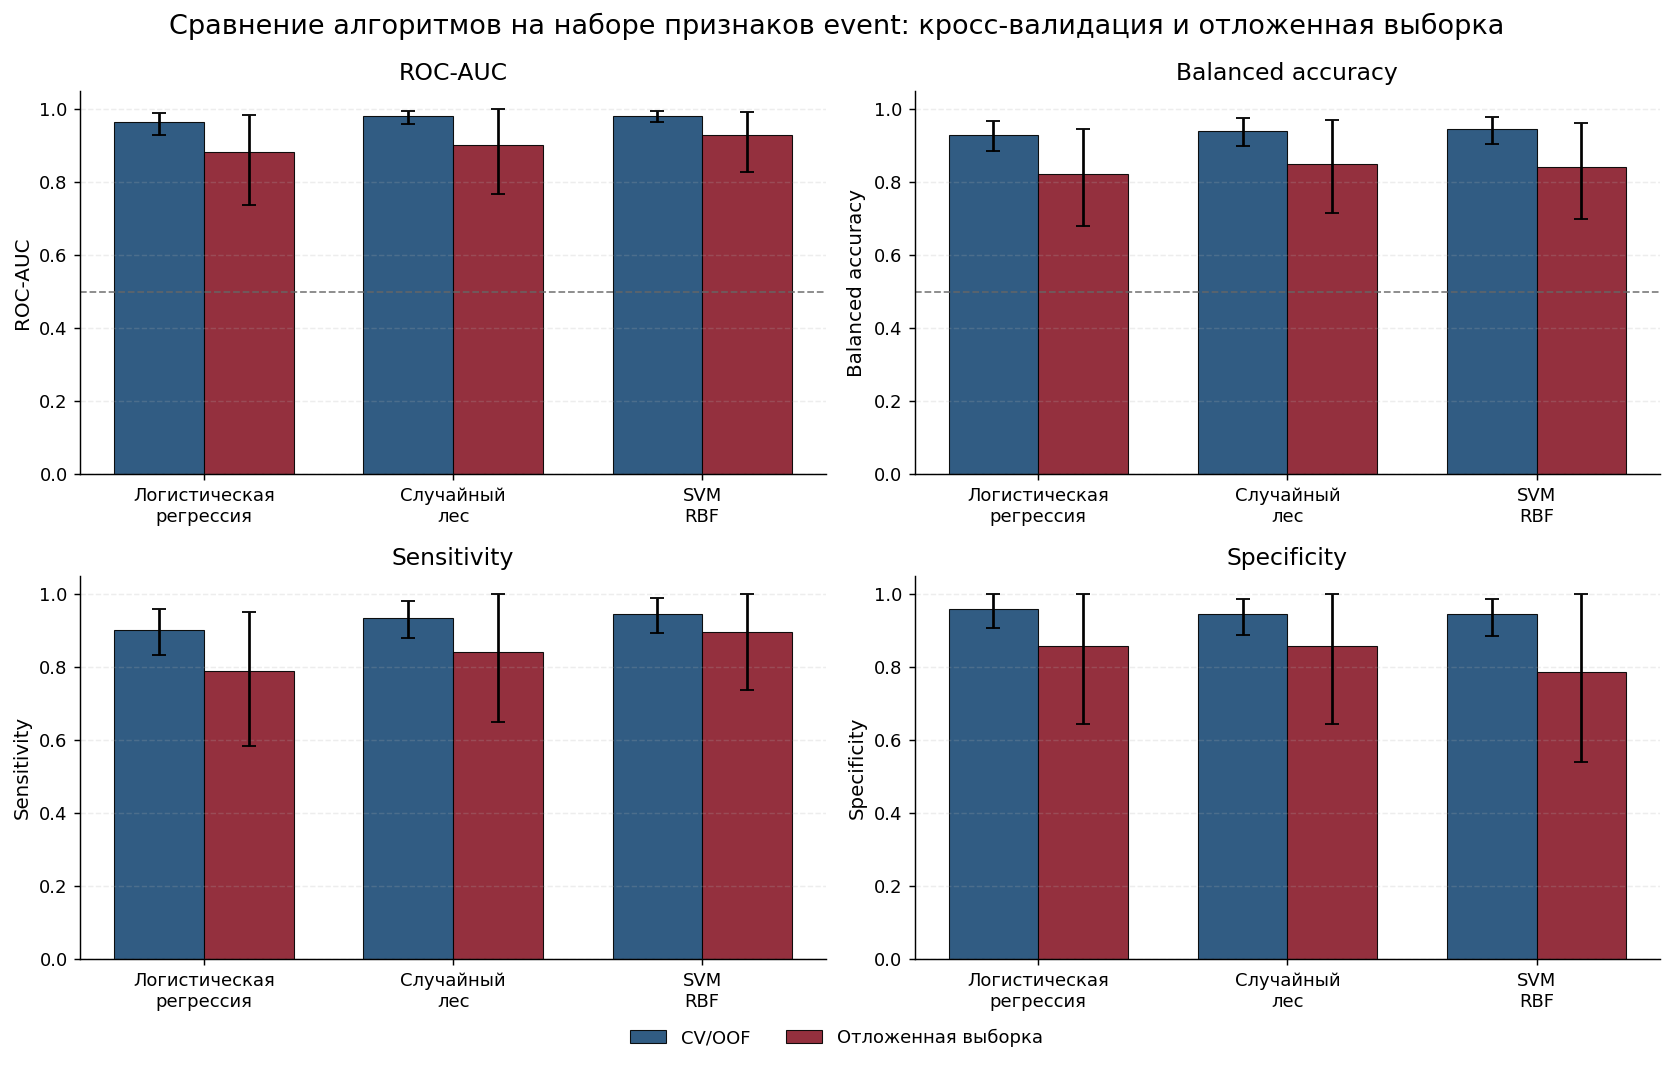

In [24]:
# @title 4.X. Сравнение алгоритмов: CV/OOF и holdout на одном графике

PLOT_METRICS = [
    "roc_auc",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
]


def plot_metric_cv_vs_holdout(df, metric, ax=None):
    sub = df[
        (df["metric"] == metric)
        & (df["validation"].isin(["cv_oof", "holdout"]))
    ].copy()

    if sub.empty:
        raise ValueError(f"Нет данных для метрики: {metric}")

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(MODEL_ORDER))
    width = 0.36

    for i, validation in enumerate(["cv_oof", "holdout"]):
        vals = []
        err_low = []
        err_high = []

        for model in MODEL_ORDER:
            row = sub[
                (sub["model"] == model)
                & (sub["validation"] == validation)
            ]

            if row.empty:
                vals.append(np.nan)
                err_low.append(0)
                err_high.append(0)
                continue

            row = row.iloc[0]
            value = float(row["value"])
            ci_low = float(row["ci_low"])
            ci_high = float(row["ci_high"])

            vals.append(value)
            err_low.append(value - ci_low)
            err_high.append(ci_high - value)

        offset = (i - 0.5) * width

        ax.bar(
            x + offset,
            vals,
            width=width,
            yerr=np.vstack([err_low, err_high]),
            capsize=4,
            color=VALIDATION_COLORS[validation],
            alpha=0.92,
            edgecolor="black",
            linewidth=0.6,
            label=VALIDATION_RU[validation],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS_SHORT[m] for m in MODEL_ORDER])
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel(METRIC_RU.get(metric, metric))
    ax.set_title(METRIC_RU.get(metric, metric))

    if metric in ["roc_auc", "balanced_accuracy"]:
        ax.axhline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY, alpha=0.8)

    apply_vkr_axes_style(ax, grid_axis="y")
    ax.grid(axis="x", visible=False)

    return ax


fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, PLOT_METRICS):
    plot_metric_cv_vs_holdout(algorithm_metrics_long_df, metric=metric, ax=ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    f"Сравнение алгоритмов на наборе признаков {REFERENCE_FEATURE_SET}: "
    "кросс-валидация и отложенная выборка",
    fontsize=15,
)

save_figure("04_algorithm_comparison_cv_vs_holdout_ci.png")
plt.show()


Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/04_algorithm_comparison_roc_auc.png


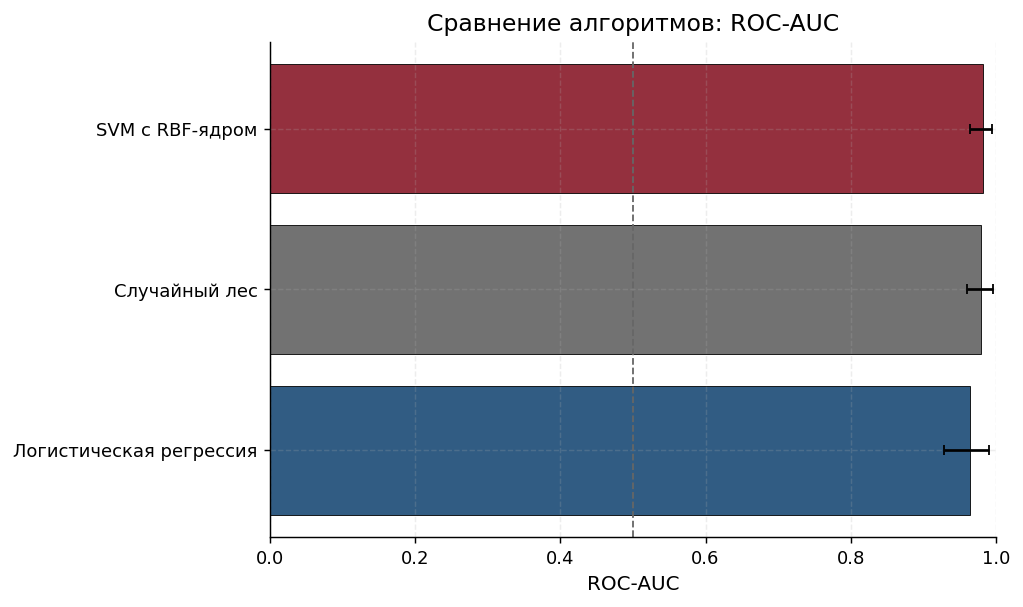

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/04_algorithm_comparison_balanced_accuracy.png


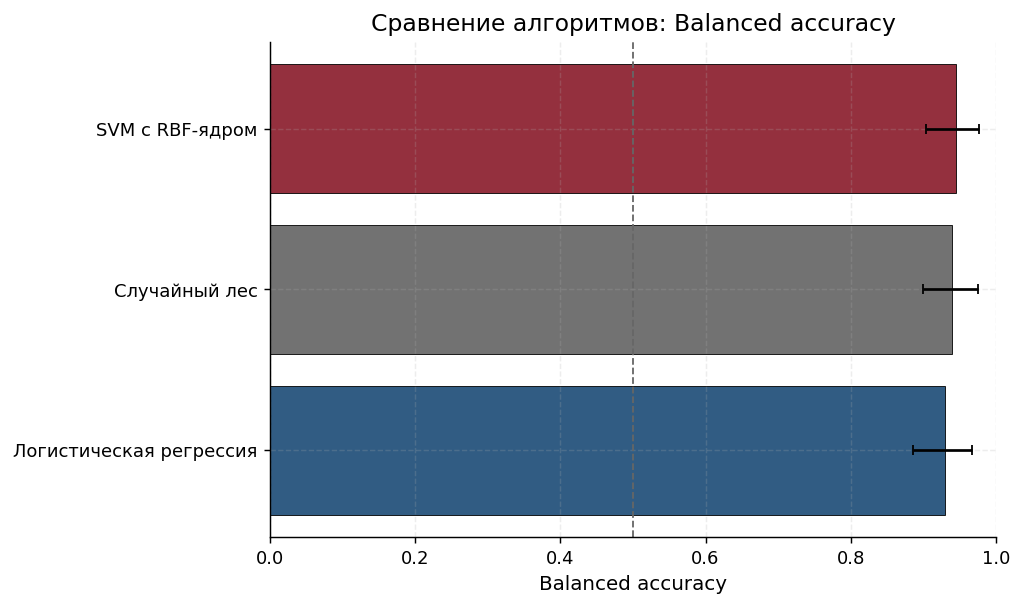

In [25]:
# @title 4.4. График сравнения алгоритмов по ROC-AUC и balanced accuracy

plot_data = algorithm_metrics_long_df[
    (algorithm_metrics_long_df["validation"] == "cv_oof")
    & (algorithm_metrics_long_df["metric"].isin(["roc_auc", "balanced_accuracy"]))
].copy()

for metric in ["roc_auc", "balanced_accuracy"]:
    tmp = plot_data[plot_data["metric"] == metric].copy()
    tmp = tmp.sort_values("value")

    fig, ax = plt.subplots(figsize=(8, 4.8))
    y_pos = np.arange(len(tmp))
    xerr = np.vstack([
        tmp["value"] - tmp["ci_low"],
        tmp["ci_high"] - tmp["value"],
    ])
    colors = tmp["model"].map(MODEL_COLORS).fillna(COLOR_GRAY)
    ax.barh(y_pos, tmp["value"], xerr=xerr, capsize=3, color=colors, alpha=0.92, edgecolor="black", linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tmp["model_ru"])
    ax.set_xlim(0, 1)
    ax.set_xlabel(METRIC_RU.get(metric, metric))
    ax.set_title(f"Сравнение алгоритмов: {METRIC_RU.get(metric, metric)}")
    ax.axvline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY)
    apply_vkr_axes_style(ax, grid_axis="x")
    save_figure(f"04_algorithm_comparison_{metric}.png")
    plt.show()


## 5. Baseline-модель: интерпретируемый спектральный набор

In [26]:
# @title 5.1. Спектральный baseline: CV/OОF и holdout для трёх алгоритмов

BASELINE_FEATURE_SET = "spectral_baseline"

if BASELINE_FEATURE_SET not in FEATURE_SETS or len(FEATURE_SETS[BASELINE_FEATURE_SET]) == 0:
    print("Спектральный baseline не найден. Проверь FEATURE_SETS.")
    baseline_eval = None
    baseline_metrics_df = pd.DataFrame()
    baseline_cv_results = {}
    baseline_holdout_results = {}
    baseline_cv_res = None
    baseline_holdout_res = None
else:
    baseline_features = FEATURE_SETS[BASELINE_FEATURE_SET]
    print("Baseline:", BASELINE_FEATURE_SET)
    print("Число признаков:", len(baseline_features))

    baseline_eval = evaluate_feature_set_all_models(
        subject_df,
        baseline_features,
        feature_set_name=BASELINE_FEATURE_SET,
        run_holdout=True,
    )
    baseline_metrics_df = baseline_eval["metrics"]
    baseline_cv_results = baseline_eval["cv"]
    baseline_holdout_results = baseline_eval["holdout"]

    # Для совместимости со старыми ячейками оставляем логистическую регрессию как интерпретируемую основную версию.
    baseline_cv_res = baseline_cv_results.get("logreg")
    baseline_holdout_res = baseline_holdout_results.get("logreg")

    baseline_main_table = baseline_metrics_df[
        baseline_metrics_df["metric"].isin(["roc_auc", "pr_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "f1", "mcc"])
    ].pivot_table(
        index=["validation", "model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value_ci",
        aggfunc="first",
    ).reset_index()

    display(baseline_main_table)
    display(baseline_eval["counts"])
    save_table(baseline_metrics_df, "05_spectral_baseline_metrics_all_models.csv")
    save_table(baseline_main_table, "05_spectral_baseline_main_table_all_models.csv")
    save_table(baseline_eval["counts"], "05_spectral_baseline_counts_all_models.csv")


Baseline: spectral_baseline
Число признаков: 61


metric,validation,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
0,cv_oof,logreg,Логистическая регрессия,spectral_baseline,61,0.762 [0.695; 0.823],0.765 [0.696; 0.829],0.777 [0.699; 0.837],0.527 [0.389; 0.654],0.882 [0.823; 0.927],0.831 [0.766; 0.888],0.739 [0.645; 0.823],0.792 [0.697; 0.881]
1,cv_oof,rf,Случайный лес,spectral_baseline,61,0.750 [0.689; 0.817],0.750 [0.686; 0.817],0.771 [0.699; 0.836],0.497 [0.371; 0.631],0.856 [0.786; 0.916],0.812 [0.747; 0.877],0.750 [0.667; 0.837],0.750 [0.650; 0.848]
2,cv_oof,svc_rbf,SVM с RBF-ядром,spectral_baseline,61,0.707 [0.634; 0.774],0.700 [0.626; 0.768],0.745 [0.670; 0.810],0.403 [0.253; 0.540],0.845 [0.769; 0.907],0.793 [0.719; 0.860],0.761 [0.674; 0.846],0.639 [0.521; 0.753]
3,holdout,logreg,Логистическая регрессия,spectral_baseline,61,0.848 [0.727; 0.970],0.840 [0.705; 0.962],0.872 [0.743; 0.971],0.688 [0.422; 0.935],0.919 [0.794; 0.993],0.883 [0.744; 0.989],0.895 [0.737; 1.000],0.786 [0.538; 1.000]
4,holdout,rf,Случайный лес,spectral_baseline,61,0.788 [0.636; 0.909],0.797 [0.646; 0.925],0.800 [0.632; 0.927],0.587 [0.286; 0.831],0.921 [0.823; 0.984],0.872 [0.738; 0.968],0.737 [0.529; 0.917],0.857 [0.666; 1.000]
5,holdout,svc_rbf,SVM с RBF-ядром,spectral_baseline,61,0.727 [0.576; 0.879],0.716 [0.545; 0.864],0.769 [0.595; 0.898],0.437 [0.092; 0.722],0.881 [0.750; 0.966],0.805 [0.632; 0.938],0.789 [0.579; 0.950],0.643 [0.364; 0.909]


,fold,n_train_total,n_train_control,n_train_tbi,n_test_total,n_test_control,n_test_tbi,model,feature_set,validation
0,1.0,131,57,74,33,15,18,logreg,spectral_baseline,NaN
1,2.0,131,57,74,33,15,18,logreg,spectral_baseline,NaN
2,3.0,131,58,73,33,14,19,logreg,spectral_baseline,NaN
3,4.0,131,58,73,33,14,19,logreg,spectral_baseline,NaN
4,5.0,132,58,74,32,14,18,logreg,spectral_baseline,NaN
5,NaN,131,58,73,33,14,19,logreg,spectral_baseline,holdout
6,1.0,131,57,74,33,15,18,rf,spectral_baseline,NaN
7,2.0,131,57,74,33,15,18,rf,spectral_baseline,NaN
8,3.0,131,58,73,33,14,19,rf,spectral_baseline,NaN
9,4.0,131,58,73,33,14,19,rf,spectral_baseline,NaN


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/05_spectral_baseline_metrics_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/05_spectral_baseline_main_table_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/05_spectral_baseline_counts_all_models.csv


Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/05_spectral_baseline_roc_curve.png


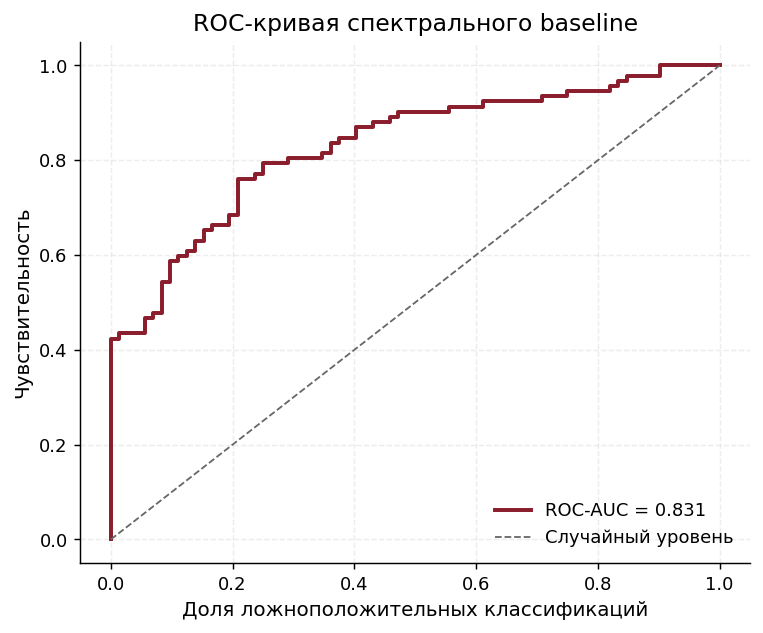

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/05_spectral_baseline_pr_curve.png


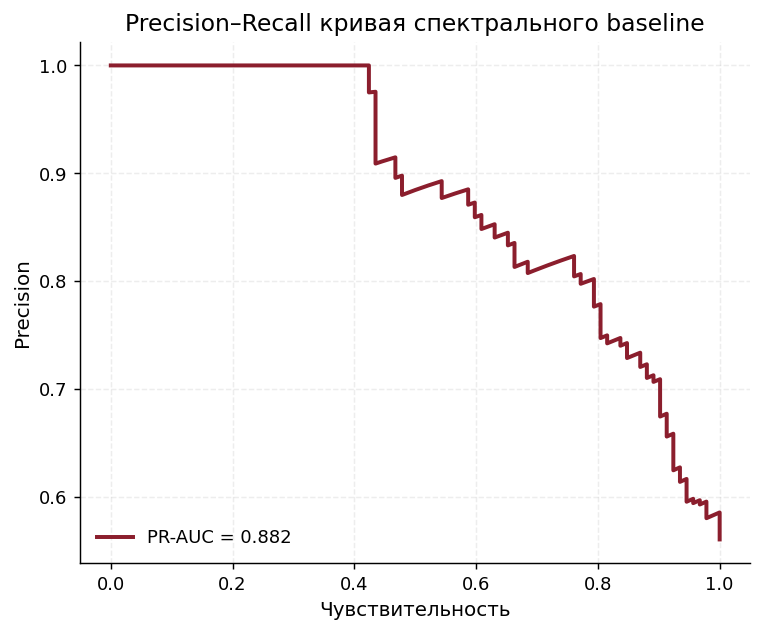

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/05_spectral_baseline_confusion_matrix.png


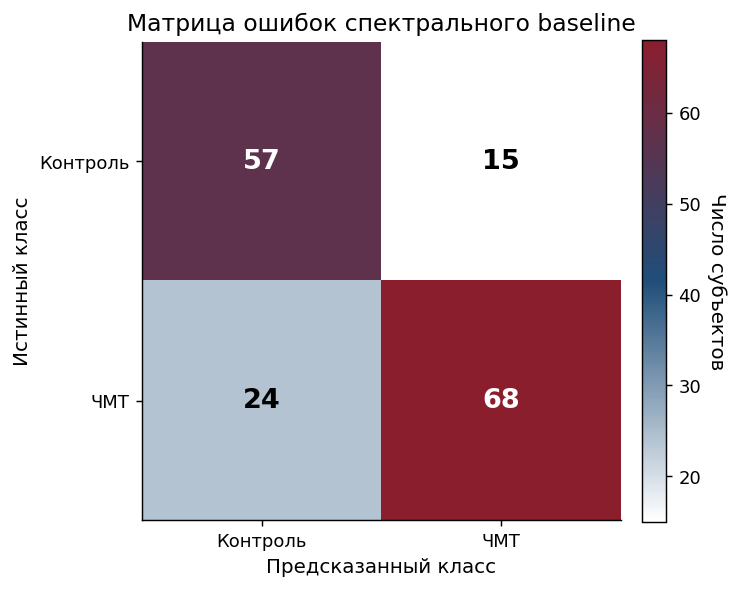

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/05_spectral_baseline_calibration.png


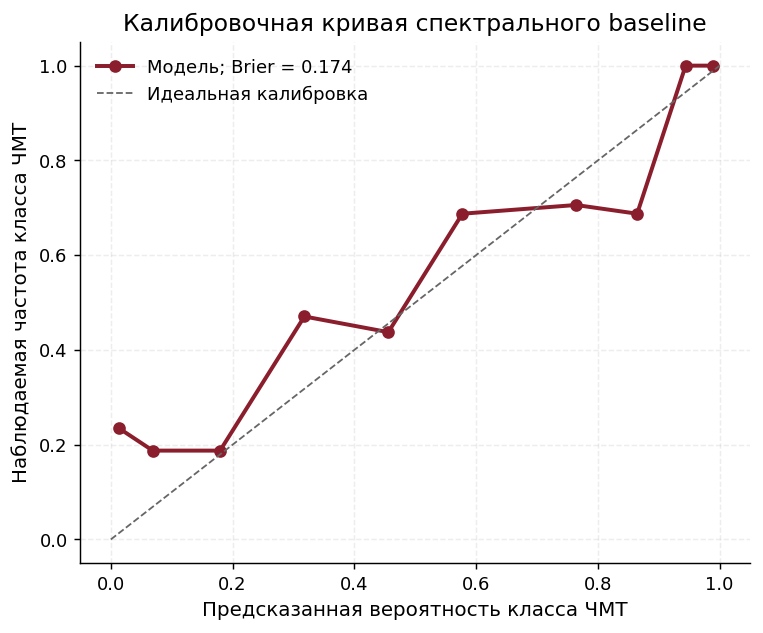

In [27]:
# @title 5.2. Спектральный baseline: ROC, PR, калибровка и матрица ошибок

if baseline_cv_res is not None:
    y_base = baseline_cv_res["y_true"]
    p_base = baseline_cv_res["oof_proba"]
    plot_roc_curve_ru(y_base, p_base, "ROC-кривая спектрального baseline", "05_spectral_baseline_roc_curve.png")
    plot_pr_curve_ru(y_base, p_base, "Precision–Recall кривая спектрального baseline", "05_spectral_baseline_pr_curve.png")
    plot_confusion_matrix_ru(y_base, p_base, "Матрица ошибок спектрального baseline", "05_spectral_baseline_confusion_matrix.png")
    plot_calibration_ru(y_base, p_base, "Калибровочная кривая спектрального baseline", "05_spectral_baseline_calibration.png")


## 6. Сравнение групп признаков одной и той же моделью

Раздел оценивает вклад разных блоков признаков при фиксированном алгоритме — логистической регрессии с весами классов. Модель `all_features` не используется. Gamma-признаки исключены. Для каждого блока выводится число признаков, чтобы учитывать влияние размерности на качество.

In [28]:
# @title 6.1. Block-wise сравнение: полный блок признаков для трёх алгоритмов

blockwise_results = []
blockwise_counts = []
blockwise_cv_results = {}

for feature_set_name, feats in FEATURE_SETS.items():
    if feature_set_name == "event_compact" or len(feats) == 0:
        continue

    eval_res = evaluate_feature_set_all_models(
        subject_df,
        feats,
        feature_set_name=feature_set_name,
        run_holdout=False,
    )
    blockwise_results.append(eval_res["metrics"])
    blockwise_counts.append(eval_res["counts"].assign(n_features=len(feats)))
    blockwise_cv_results[feature_set_name] = eval_res["cv"]

blockwise_metrics_long_df = pd.concat(blockwise_results, ignore_index=True)
blockwise_counts_df = pd.concat(blockwise_counts, ignore_index=True)

blockwise_main_table = blockwise_metrics_long_df[
    blockwise_metrics_long_df["metric"].isin(["roc_auc", "pr_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "f1", "mcc"])
].pivot_table(
    index=["model", "model_ru", "feature_set", "n_features"],
    columns="metric",
    values="value_ci",
    aggfunc="first",
).reset_index()

roc_values = blockwise_metrics_long_df[
    blockwise_metrics_long_df["metric"] == "roc_auc"
][["model", "feature_set", "value"]]
blockwise_main_table = (
    blockwise_main_table
    .merge(roc_values, on=["model", "feature_set"], how="left")
    .rename(columns={"value": "roc_auc_value"})
    .sort_values(["model", "roc_auc_value"], ascending=[True, False])
    .drop(columns="roc_auc_value")
)

display(blockwise_main_table)
save_table(blockwise_metrics_long_df, "06_blockwise_full_metrics_long_all_models.csv")
save_table(blockwise_main_table, "06_blockwise_full_main_table_all_models.csv")
save_table(blockwise_counts_df, "06_blockwise_full_fold_counts_all_models.csv")


,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
5,logreg,Логистическая регрессия,event,14,0.927 [0.878; 0.963],0.930 [0.886; 0.966],0.933 [0.888; 0.968],0.855 [0.768; 0.928],0.978 [0.958; 0.993],0.964 [0.929; 0.990],0.902 [0.833; 0.958],0.958 [0.908; 1.000]
3,logreg,Логистическая регрессия,conn,172,0.860 [0.805; 0.909],0.861 [0.804; 0.913],0.872 [0.810; 0.919],0.719 [0.603; 0.819],0.947 [0.908; 0.976],0.929 [0.886; 0.965],0.848 [0.767; 0.920],0.875 [0.791; 0.948]
2,logreg,Логистическая регрессия,burst,40,0.848 [0.787; 0.902],0.849 [0.791; 0.901],0.860 [0.802; 0.911],0.694 [0.575; 0.800],0.940 [0.900; 0.970],0.915 [0.868; 0.955],0.837 [0.760; 0.909],0.861 [0.773; 0.935]
7,logreg,Логистическая регрессия,spectral_baseline,61,0.762 [0.695; 0.823],0.765 [0.696; 0.829],0.777 [0.699; 0.837],0.527 [0.389; 0.654],0.882 [0.823; 0.927],0.831 [0.766; 0.888],0.739 [0.645; 0.823],0.792 [0.697; 0.881]
1,logreg,Логистическая регрессия,aper,31,0.738 [0.671; 0.805],0.738 [0.668; 0.804],0.760 [0.686; 0.825],0.473 [0.332; 0.606],0.844 [0.768; 0.906],0.797 [0.730; 0.865],0.739 [0.649; 0.823],0.736 [0.625; 0.833]
0,logreg,Логистическая регрессия,alpha_peak,15,0.689 [0.616; 0.756],0.687 [0.611; 0.756],0.718 [0.639; 0.786],0.372 [0.222; 0.510],0.790 [0.697; 0.878],0.768 [0.690; 0.837],0.707 [0.607; 0.794],0.667 [0.551; 0.776]
6,logreg,Логистическая регрессия,spec_shape,15,0.720 [0.652; 0.787],0.718 [0.648; 0.790],0.744 [0.667; 0.813],0.435 [0.294; 0.573],0.786 [0.687; 0.872],0.766 [0.688; 0.842],0.728 [0.633; 0.812],0.708 [0.600; 0.817]
8,logreg,Логистическая регрессия,tfr,5,0.659 [0.585; 0.732],0.655 [0.579; 0.729],0.692 [0.611; 0.763],0.309 [0.158; 0.457],0.799 [0.711; 0.881],0.756 [0.680; 0.829],0.685 [0.589; 0.774],0.625 [0.507; 0.739]
4,logreg,Логистическая регрессия,dfa,10,0.665 [0.591; 0.738],0.662 [0.589; 0.732],0.696 [0.613; 0.769],0.322 [0.177; 0.464],0.750 [0.655; 0.846],0.735 [0.659; 0.807],0.685 [0.591; 0.778],0.639 [0.529; 0.743]
14,rf,Случайный лес,event,14,0.939 [0.896; 0.976],0.940 [0.899; 0.976],0.945 [0.907; 0.978],0.877 [0.794; 0.951],0.985 [0.967; 0.997],0.980 [0.960; 0.995],0.935 [0.880; 0.980],0.944 [0.889; 0.987]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_full_metrics_long_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_full_main_table_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_full_fold_counts_all_models.csv


PosixPath('/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_full_fold_counts_all_models.csv')

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/06_blockwise_full_roc_auc_with_ci_all_models.png


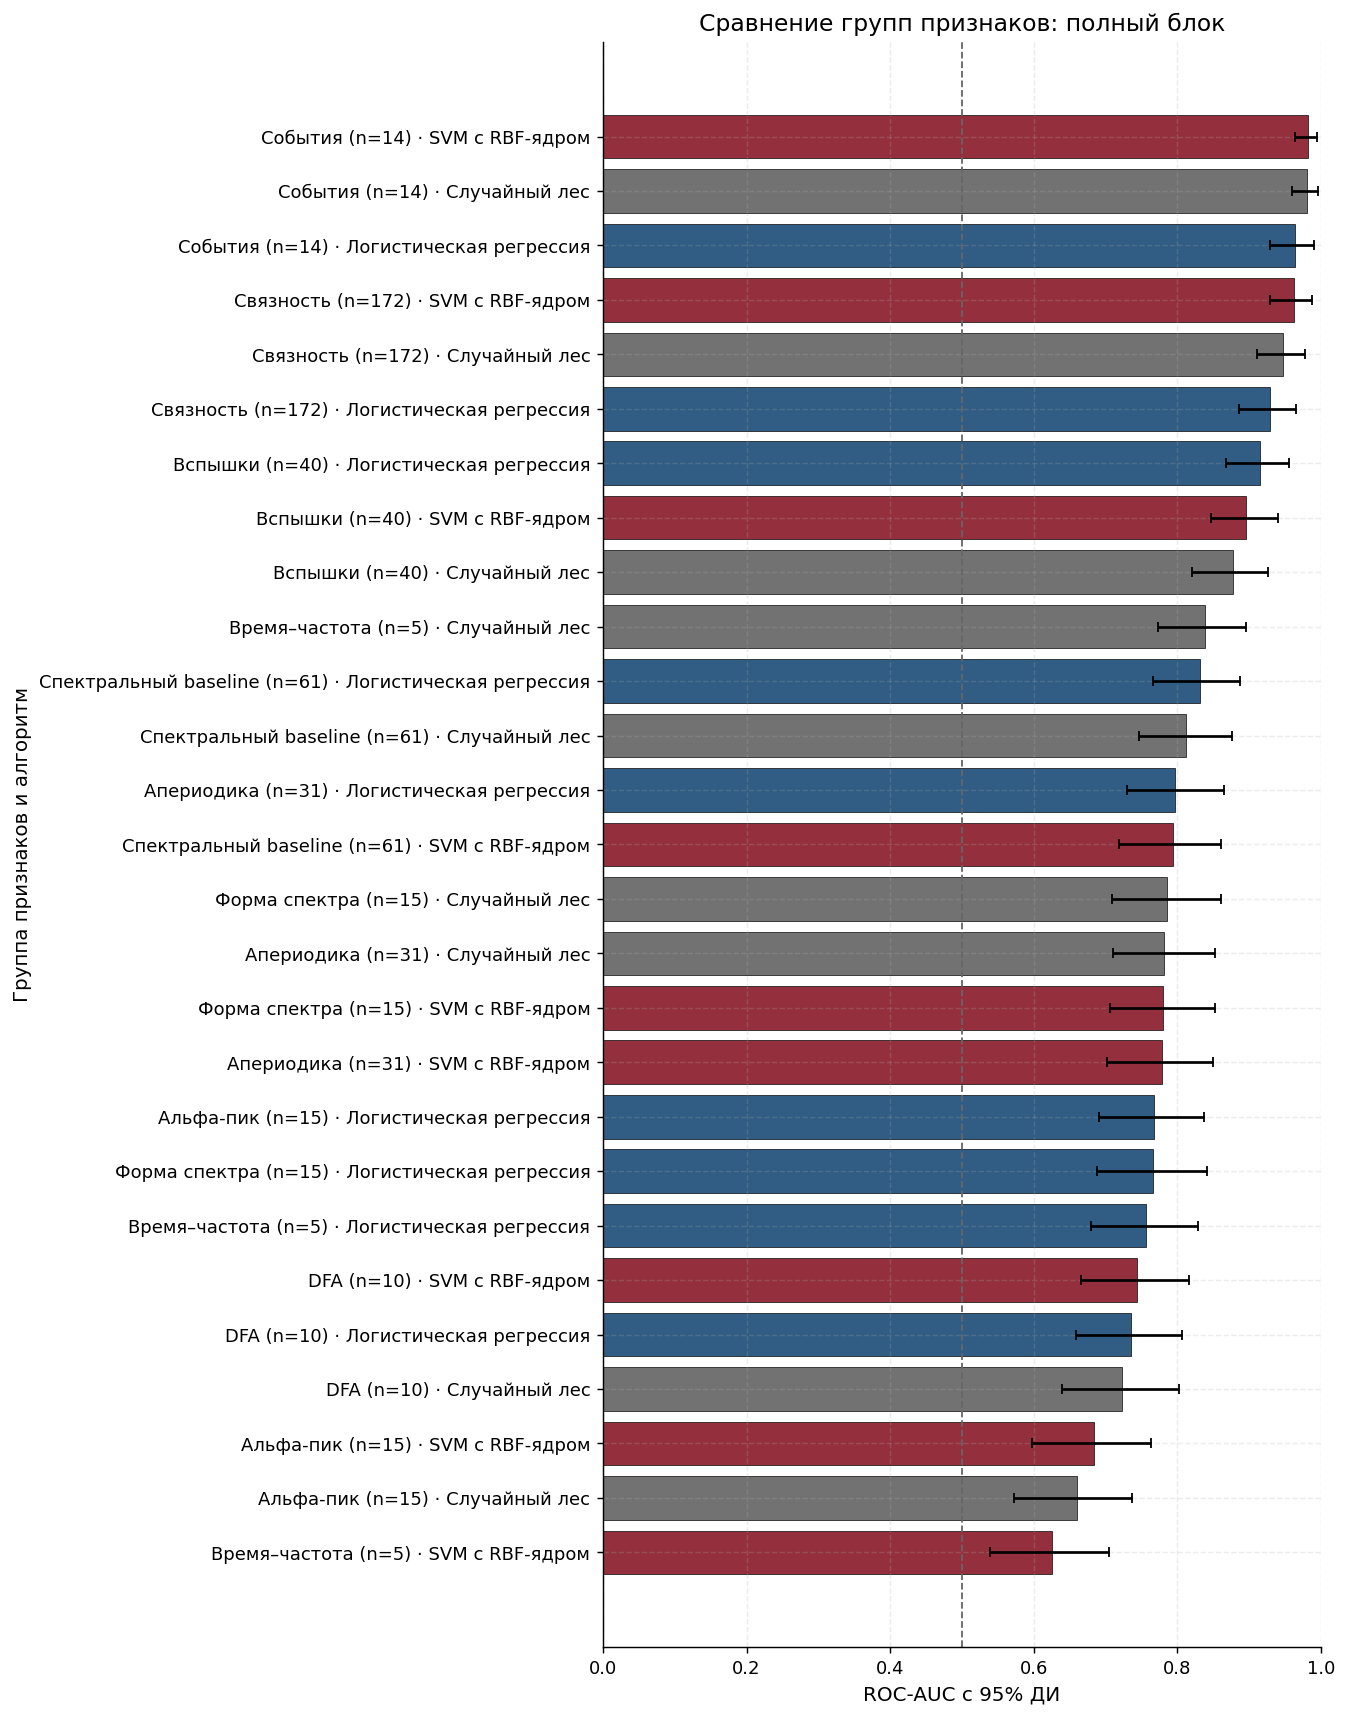

In [29]:
# @title 6.2. График block-wise сравнения с учётом числа признаков

metric_to_plot = "roc_auc"
plot_df = blockwise_metrics_long_df[blockwise_metrics_long_df["metric"] == metric_to_plot].copy()
plot_df["label"] = plot_df["feature_set"].map(clean_feature_label) + " (n=" + plot_df["n_features"].astype(str) + ")"
plot_df["label_model"] = plot_df["label"] + " · " + plot_df["model"].map(MODEL_LABELS)
plot_df = plot_df.sort_values(["value", "model"])

fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(plot_df) + 2))
y_pos = np.arange(len(plot_df))
xerr = np.vstack([
    plot_df["value"] - plot_df["ci_low"],
    plot_df["ci_high"] - plot_df["value"],
])
colors = plot_df["model"].map(MODEL_COLORS).fillna(COLOR_GRAY)
ax.barh(y_pos, plot_df["value"], xerr=xerr, capsize=3, color=colors, alpha=0.92, edgecolor="black", linewidth=0.4)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label_model"])
ax.set_xlim(0, 1)
ax.set_xlabel("ROC-AUC с 95% ДИ")
ax.set_ylabel("Группа признаков и алгоритм")
ax.set_title("Сравнение групп признаков: полный блок")
ax.axvline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY)
apply_vkr_axes_style(ax, grid_axis="x")
save_figure("06_blockwise_full_roc_auc_with_ci_all_models.png")
plt.show()


In [30]:
# @title 6.3. Контроль влияния числа признаков: train-only top-k внутри каждого блока для трёх алгоритмов

def select_top_k_on_train(X_train, y_train, features, k=TOP_K_PER_BLOCK):
    rows = []
    y_train = np.asarray(y_train).astype(int)
    for feat in features:
        x = pd.Series(X_train[feat]).astype(float)
        fill = x.median()
        x_filled = x.fillna(fill).values
        if np.nanstd(x_filled) == 0:
            score = 0.5
        else:
            try:
                auc_val = roc_auc_score(y_train, x_filled)
                score = max(auc_val, 1 - auc_val)
            except Exception:
                score = 0.5
        rows.append({"feature": feat, "score": score})
    ranking = pd.DataFrame(rows).sort_values("score", ascending=False)
    return ranking.head(min(k, len(ranking)))["feature"].tolist()


def evaluate_block_topk_train_only(df, feature_set_name, features, model_name="logreg", k=TOP_K_PER_BLOCK):
    X_all = df[features].copy()
    y_all = df["y"].astype(int).reset_index(drop=True)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pipe = make_model(model_name)
    oof_proba = np.zeros(len(y_all), dtype=float)
    selected_rows = []
    fold_counts = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all), start=1):
        selected = select_top_k_on_train(X_all.iloc[train_idx], y_all.iloc[train_idx], features, k=k)
        selected_rows.extend([
            {"feature_set": feature_set_name, "model": model_name, "fold": fold, "feature": f}
            for f in selected
        ])
        pipe_fold = clone(pipe)
        pipe_fold.fit(X_all.iloc[train_idx][selected], y_all.iloc[train_idx])
        oof_proba[test_idx] = pipe_fold.predict_proba(X_all.iloc[test_idx][selected])[:, 1]
        fold_counts.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "fold": fold,
            "n_selected": len(selected),
            "n_train_total": len(train_idx),
            "n_train_control": int((y_all.iloc[train_idx] == 0).sum()),
            "n_train_tbi": int((y_all.iloc[train_idx] == 1).sum()),
            "n_test_total": len(test_idx),
            "n_test_control": int((y_all.iloc[test_idx] == 0).sum()),
            "n_test_tbi": int((y_all.iloc[test_idx] == 1).sum()),
        })

    metric_ci = bootstrap_ci_for_metrics(y_all, oof_proba, threshold=0.5)
    metric_ci.insert(0, "validation", "cv_oof_topk_train_only")
    metric_ci.insert(0, "feature_set", feature_set_name)
    metric_ci.insert(0, "n_features", min(k, len(features)))
    metric_ci.insert(0, "model_ru", MODEL_LABELS[model_name])
    metric_ci.insert(0, "model", model_name)

    return metric_ci, pd.DataFrame(selected_rows), pd.DataFrame(fold_counts), oof_proba


topk_results = []
topk_selected = []
topk_counts = []
topk_oof_predictions = {}

for feature_set_name, feats in FEATURE_SETS.items():
    if feature_set_name == "event_compact" or len(feats) == 0:
        continue
    for model_name in MODEL_ORDER:
        metric_ci, selected_df, counts_df, oof_proba = evaluate_block_topk_train_only(
            subject_df,
            feature_set_name,
            feats,
            model_name=model_name,
            k=TOP_K_PER_BLOCK,
        )
        topk_results.append(metric_ci)
        topk_selected.append(selected_df)
        topk_counts.append(counts_df)
        topk_oof_predictions[(feature_set_name, model_name)] = oof_proba

topk_metrics_long_df = pd.concat(topk_results, ignore_index=True)
topk_selected_df = pd.concat(topk_selected, ignore_index=True)
topk_counts_df = pd.concat(topk_counts, ignore_index=True)

selection_frequency_df = (
    topk_selected_df.groupby(["feature_set", "model", "feature"])
    .size()
    .reset_index(name="n_selected_folds")
    .sort_values(["feature_set", "model", "n_selected_folds"], ascending=[True, True, False])
)

display(topk_metrics_long_df.head())
display(selection_frequency_df.head(30))
save_table(topk_metrics_long_df, "06_blockwise_topk_train_only_metrics_long_all_models.csv")
save_table(selection_frequency_df, "06_blockwise_topk_train_only_selection_frequency_all_models.csv")
save_table(topk_counts_df, "06_blockwise_topk_train_only_fold_counts_all_models.csv")


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci
0,logreg,Логистическая регрессия,10,alpha_peak,cv_oof_topk_train_only,roc_auc,0.774306,0.695736,0.842194,0.774 [0.696; 0.842]
1,logreg,Логистическая регрессия,10,alpha_peak,cv_oof_topk_train_only,pr_auc,0.802200,0.713520,0.883061,0.802 [0.714; 0.883]
2,logreg,Логистическая регрессия,10,alpha_peak,cv_oof_topk_train_only,accuracy,0.725610,0.652439,0.792683,0.726 [0.652; 0.793]
3,logreg,Логистическая регрессия,10,alpha_peak,cv_oof_topk_train_only,balanced_accuracy,0.725242,0.652669,0.791923,0.725 [0.653; 0.792]
4,logreg,Логистическая регрессия,10,alpha_peak,cv_oof_topk_train_only,sensitivity,0.728261,0.629980,0.813190,0.728 [0.630; 0.813]


,feature_set,model,feature,n_selected_folds
0,alpha_peak,logreg,alpha_peak__alpha_peak_amp_db__central,5
3,alpha_peak,logreg,alpha_peak__alpha_peak_amp_db__parietal,5
5,alpha_peak,logreg,alpha_peak__alpha_peak_db__central,5
6,alpha_peak,logreg,alpha_peak__alpha_peak_db__frontal,5
7,alpha_peak,logreg,alpha_peak__alpha_peak_db__occipital,5
8,alpha_peak,logreg,alpha_peak__alpha_peak_db__parietal,5
9,alpha_peak,logreg,alpha_peak__alpha_peak_db__temporal,5
1,alpha_peak,logreg,alpha_peak__alpha_peak_amp_db__frontal,4
2,alpha_peak,logreg,alpha_peak__alpha_peak_amp_db__occipital,4
12,alpha_peak,logreg,alpha_peak__paf_hz__temporal,3


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_topk_train_only_metrics_long_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_topk_train_only_selection_frequency_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_topk_train_only_fold_counts_all_models.csv


PosixPath('/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/06_blockwise_topk_train_only_fold_counts_all_models.csv')

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/06_blockwise_topk_roc_auc_with_ci_all_models.png


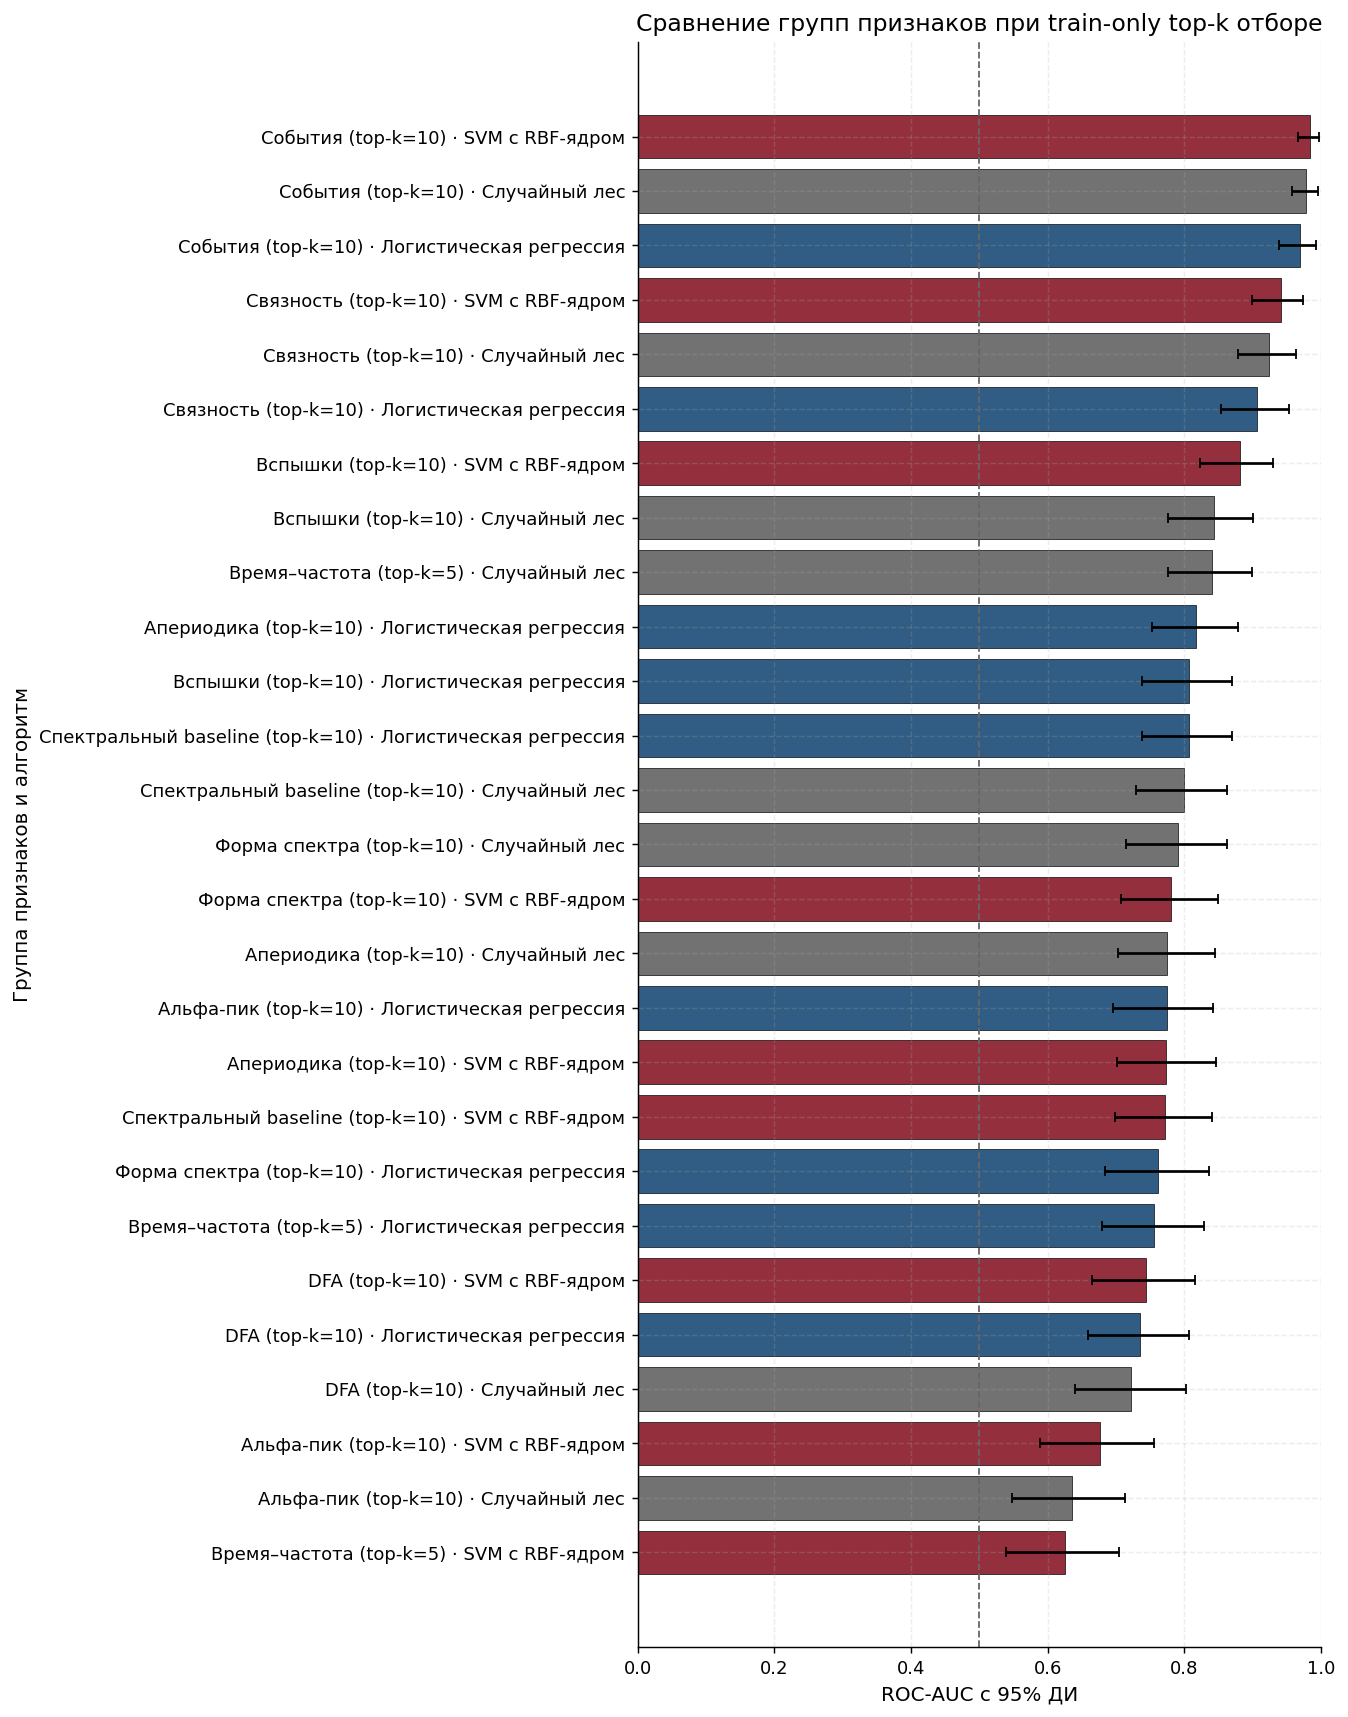

In [31]:
# @title 6.4. График block-wise сравнения при одинаковом ограничении top-k

metric_to_plot = "roc_auc"
plot_df = topk_metrics_long_df[topk_metrics_long_df["metric"] == metric_to_plot].copy()
plot_df["label"] = plot_df["feature_set"].map(clean_feature_label) + " (top-k=" + plot_df["n_features"].astype(str) + ")"
plot_df["label_model"] = plot_df["label"] + " · " + plot_df["model"].map(MODEL_LABELS)
plot_df = plot_df.sort_values(["value", "model"])

fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(plot_df) + 2))
y_pos = np.arange(len(plot_df))
xerr = np.vstack([
    plot_df["value"] - plot_df["ci_low"],
    plot_df["ci_high"] - plot_df["value"],
])
colors = plot_df["model"].map(MODEL_COLORS).fillna(COLOR_GRAY)
ax.barh(y_pos, plot_df["value"], xerr=xerr, capsize=3, color=colors, alpha=0.92, edgecolor="black", linewidth=0.4)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label_model"])
ax.set_xlim(0, 1)
ax.set_xlabel("ROC-AUC с 95% ДИ")
ax.set_ylabel("Группа признаков и алгоритм")
ax.set_title("Сравнение групп признаков при train-only top-k отборе")
ax.axvline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY)
apply_vkr_axes_style(ax, grid_axis="x")
save_figure("06_blockwise_topk_roc_auc_with_ci_all_models.png")
plt.show()


## 7. Вторичная holdout-проверка для групп признаков

Раздел выполняет дополнительную holdout-проверку. Она не заменяет CV/OОF-оценку, но помогает показать, насколько результаты сохраняются на одной отложенной подвыборке. Размер holdout задаётся параметром `HOLDOUT_SIZE`.

In [32]:
# @title 7.1. Holdout-сравнение групп признаков для трёх алгоритмов

holdout_block_results = []
holdout_block_counts = []
holdout_block_results_objects = {}

for feature_set_name, feats in FEATURE_SETS.items():
    if feature_set_name == "event_compact" or len(feats) == 0:
        continue
    for model_name in MODEL_ORDER:
        hold_res = evaluate_model_holdout(
            subject_df,
            feats,
            model_name=model_name,
            feature_set_name=feature_set_name,
        )
        holdout_block_results.append(hold_res["metric_ci"])
        holdout_block_counts.append(
            hold_res["counts"].assign(model=model_name, feature_set=feature_set_name, n_features=len(feats))
        )
        holdout_block_results_objects[(feature_set_name, model_name)] = hold_res

holdout_block_metrics_long_df = pd.concat(holdout_block_results, ignore_index=True)
holdout_block_counts_df = pd.concat(holdout_block_counts, ignore_index=True)

holdout_block_main_table = holdout_block_metrics_long_df[
    holdout_block_metrics_long_df["metric"].isin(["roc_auc", "pr_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "f1", "mcc"])
].pivot_table(
    index=["model", "model_ru", "feature_set", "n_features"],
    columns="metric",
    values="value_ci",
    aggfunc="first",
).reset_index()

display(holdout_block_main_table)
display(holdout_block_counts_df.drop_duplicates(subset=["model", "feature_set"]))
save_table(holdout_block_metrics_long_df, "07_holdout_blockwise_metrics_long_all_models.csv")
save_table(holdout_block_main_table, "07_holdout_blockwise_main_table_all_models.csv")
save_table(holdout_block_counts_df, "07_holdout_blockwise_counts_all_models.csv")


metric,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
0,logreg,Логистическая регрессия,alpha_peak,15,0.727 [0.576; 0.879],0.716 [0.544; 0.879],0.769 [0.594; 0.905],0.437 [0.089; 0.759],0.899 [0.768; 0.980],0.842 [0.684; 0.963],0.789 [0.600; 0.950],0.643 [0.357; 0.900]
1,logreg,Логистическая регрессия,aper,31,0.818 [0.667; 0.939],0.814 [0.663; 0.938],0.842 [0.692; 0.947],0.628 [0.332; 0.876],0.949 [0.873; 0.995],0.910 [0.792; 0.993],0.842 [0.667; 1.000],0.786 [0.545; 1.000]
2,logreg,Логистическая регрессия,burst,40,0.818 [0.667; 0.939],0.805 [0.656; 0.935],0.850 [0.706; 0.950],0.626 [0.336; 0.876],0.944 [0.854; 0.998],0.914 [0.789; 0.996],0.895 [0.737; 1.000],0.714 [0.455; 0.929]
3,logreg,Логистическая регрессия,conn,172,0.909 [0.788; 1.000],0.921 [0.825; 1.000],0.914 [0.788; 1.000],0.833 [0.650; 1.000],0.992 [0.963; 1.000],0.989 [0.952; 1.000],0.842 [0.650; 1.000],1.000 [1.000; 1.000]
4,logreg,Логистическая регрессия,dfa,10,0.758 [0.606; 0.909],0.742 [0.583; 0.893],0.800 [0.629; 0.919],0.498 [0.173; 0.793],0.862 [0.702; 0.967],0.801 [0.631; 0.945],0.842 [0.667; 1.000],0.643 [0.364; 0.882]
5,logreg,Логистическая регрессия,event,14,0.818 [0.667; 0.939],0.823 [0.681; 0.944],0.833 [0.681; 0.947],0.639 [0.359; 0.881],0.934 [0.838; 0.990],0.883 [0.736; 0.985],0.789 [0.583; 0.950],0.857 [0.643; 1.000]
6,logreg,Логистическая регрессия,spec_shape,15,0.727 [0.576; 0.879],0.735 [0.569; 0.878],0.743 [0.552; 0.882],0.465 [0.139; 0.746],0.793 [0.607; 0.957],0.756 [0.574; 0.914],0.684 [0.471; 0.889],0.786 [0.538; 1.000]
7,logreg,Логистическая регрессия,spectral_baseline,61,0.848 [0.727; 0.970],0.840 [0.705; 0.962],0.872 [0.743; 0.971],0.688 [0.422; 0.935],0.919 [0.794; 0.993],0.883 [0.744; 0.989],0.895 [0.737; 1.000],0.786 [0.538; 1.000]
8,logreg,Логистическая регрессия,tfr,5,0.697 [0.545; 0.848],0.690 [0.521; 0.846],0.737 [0.555; 0.875],0.380 [0.037; 0.692],0.835 [0.655; 0.959],0.782 [0.593; 0.921],0.737 [0.526; 0.923],0.643 [0.364; 0.889]
9,rf,Случайный лес,alpha_peak,15,0.727 [0.576; 0.879],0.716 [0.548; 0.869],0.769 [0.600; 0.900],0.437 [0.097; 0.745],0.883 [0.740; 0.974],0.831 [0.669; 0.952],0.789 [0.588; 0.950],0.643 [0.368; 0.900]


,validation,n_train_total,n_train_control,n_train_tbi,n_test_total,n_test_control,n_test_tbi,model,feature_set,n_features
0,holdout,131,58,73,33,14,19,logreg,alpha_peak,15
1,holdout,131,58,73,33,14,19,rf,alpha_peak,15
2,holdout,131,58,73,33,14,19,svc_rbf,alpha_peak,15
3,holdout,131,58,73,33,14,19,logreg,aper,31
4,holdout,131,58,73,33,14,19,rf,aper,31
5,holdout,131,58,73,33,14,19,svc_rbf,aper,31
6,holdout,131,58,73,33,14,19,logreg,burst,40
7,holdout,131,58,73,33,14,19,rf,burst,40
8,holdout,131,58,73,33,14,19,svc_rbf,burst,40
9,holdout,131,58,73,33,14,19,logreg,conn,172


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/07_holdout_blockwise_metrics_long_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/07_holdout_blockwise_main_table_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/07_holdout_blockwise_counts_all_models.csv


PosixPath('/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/07_holdout_blockwise_counts_all_models.csv')

## 8. Подробный раздел компактной событийной модели

Раздел повторяет все проверки для компактной модели на двух событийных признаках: `event__z_peak` и `event__propagation_ms`. Включены CV/OОF, holdout, repeated CV, permutation test, bootstrap CI, матрица ошибок, анализ порога, калибровка, коэффициенты, odds ratio, стабильность знаков, абляция и анализ ошибок.

In [33]:
# @title 8.1. Компактная событийная модель: CV/OОF и holdout для трёх алгоритмов

if len(EVENT_CORE) != 2:
    print("Внимание: не найдены оба признака компактной событийной модели.")
    print("Найденные признаки:", EVENT_CORE)
    event_metrics_df = pd.DataFrame()
    event_cv_results = {}
    event_holdout_results = {}
    event_cv_res = None
    event_holdout_res = None
else:
    event_eval = evaluate_feature_set_all_models(
        subject_df,
        EVENT_CORE,
        feature_set_name="event_compact",
        run_holdout=True,
    )
    event_metrics_df = event_eval["metrics"]
    event_cv_results = event_eval["cv"]
    event_holdout_results = event_eval["holdout"]

    # Для интерпретации коэффициентов и старых ячеек оставляем логистическую регрессию основной компактной версией.
    event_cv_res = event_cv_results.get("logreg")
    event_holdout_res = event_holdout_results.get("logreg")

    event_main_table = event_metrics_df[
        event_metrics_df["metric"].isin(["roc_auc", "pr_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "f1", "mcc"])
    ].pivot_table(
        index=["validation", "model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value_ci",
        aggfunc="first",
    ).reset_index()

    display(event_main_table)
    display(event_eval["counts"])
    save_table(event_metrics_df, "08_event_compact_metrics_cv_holdout_all_models.csv")
    save_table(event_main_table, "08_event_compact_main_table_all_models.csv")
    save_table(event_eval["counts"], "08_event_compact_counts_all_models.csv")


metric,validation,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
0,cv_oof,logreg,Логистическая регрессия,event_compact,2,0.927 [0.884; 0.963],0.929 [0.884; 0.967],0.933 [0.891; 0.969],0.853 [0.764; 0.929],0.985 [0.969; 0.997],0.976 [0.948; 0.996],0.913 [0.849; 0.967],0.944 [0.884; 0.987]
1,cv_oof,rf,Случайный лес,event_compact,2,0.945 [0.909; 0.976],0.945 [0.907; 0.979],0.951 [0.915; 0.981],0.889 [0.813; 0.952],0.986 [0.971; 0.997],0.982 [0.964; 0.996],0.946 [0.895; 0.989],0.944 [0.889; 0.987]
2,cv_oof,svc_rbf,SVM с RBF-ядром,event_compact,2,0.945 [0.909; 0.982],0.945 [0.906; 0.981],0.951 [0.914; 0.982],0.889 [0.811; 0.962],0.977 [0.943; 0.998],0.977 [0.950; 0.997],0.946 [0.894; 0.989],0.944 [0.884; 0.987]
3,holdout,logreg,Логистическая регрессия,event_compact,2,0.818 [0.667; 0.939],0.823 [0.681; 0.944],0.833 [0.681; 0.947],0.639 [0.359; 0.881],0.920 [0.812; 0.986],0.861 [0.710; 0.974],0.789 [0.583; 0.950],0.857 [0.643; 1.000]
4,holdout,rf,Случайный лес,event_compact,2,0.848 [0.727; 0.970],0.850 [0.716; 0.969],0.865 [0.727; 0.971],0.694 [0.426; 0.938],0.941 [0.843; 1.000],0.915 [0.800; 1.000],0.842 [0.650; 1.000],0.857 [0.643; 1.000]
5,holdout,svc_rbf,SVM с RBF-ядром,event_compact,2,0.848 [0.727; 0.970],0.850 [0.719; 0.962],0.865 [0.727; 0.968],0.694 [0.434; 0.935],0.894 [0.755; 0.992],0.872 [0.722; 0.985],0.842 [0.667; 1.000],0.857 [0.643; 1.000]


,fold,n_train_total,n_train_control,n_train_tbi,n_test_total,n_test_control,n_test_tbi,model,feature_set,validation
0,1.0,131,57,74,33,15,18,logreg,event_compact,NaN
1,2.0,131,57,74,33,15,18,logreg,event_compact,NaN
2,3.0,131,58,73,33,14,19,logreg,event_compact,NaN
3,4.0,131,58,73,33,14,19,logreg,event_compact,NaN
4,5.0,132,58,74,32,14,18,logreg,event_compact,NaN
5,NaN,131,58,73,33,14,19,logreg,event_compact,holdout
6,1.0,131,57,74,33,15,18,rf,event_compact,NaN
7,2.0,131,57,74,33,15,18,rf,event_compact,NaN
8,3.0,131,58,73,33,14,19,rf,event_compact,NaN
9,4.0,131,58,73,33,14,19,rf,event_compact,NaN


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_metrics_cv_holdout_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_main_table_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_counts_all_models.csv


Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_roc_curve_logreg.png


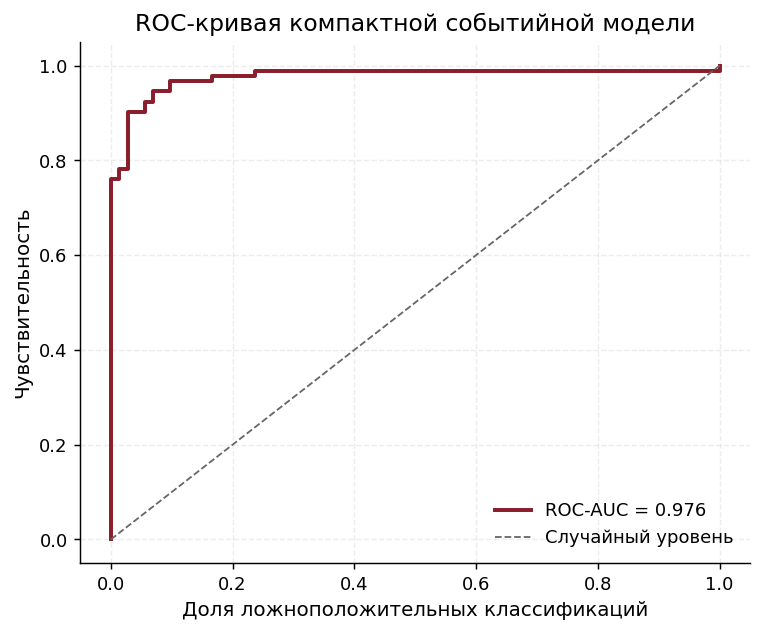

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_pr_curve_logreg.png


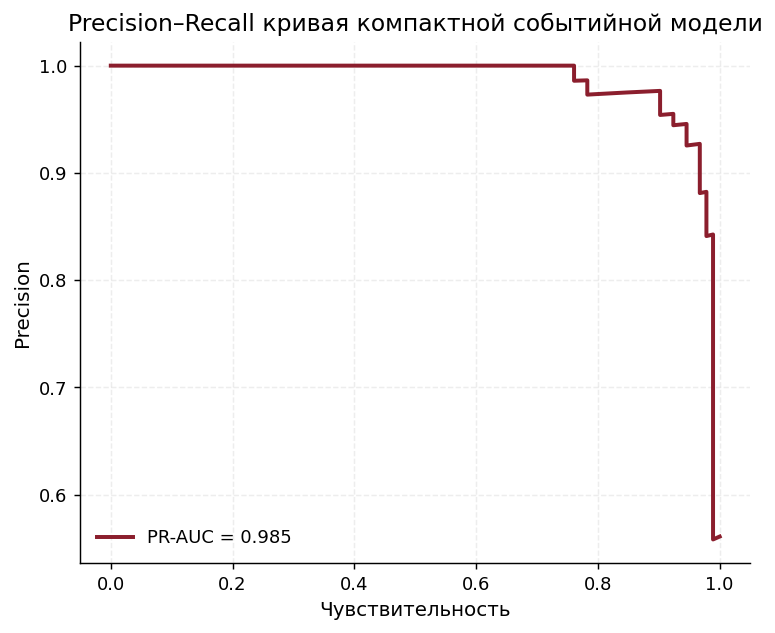

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_confusion_matrix_logreg.png


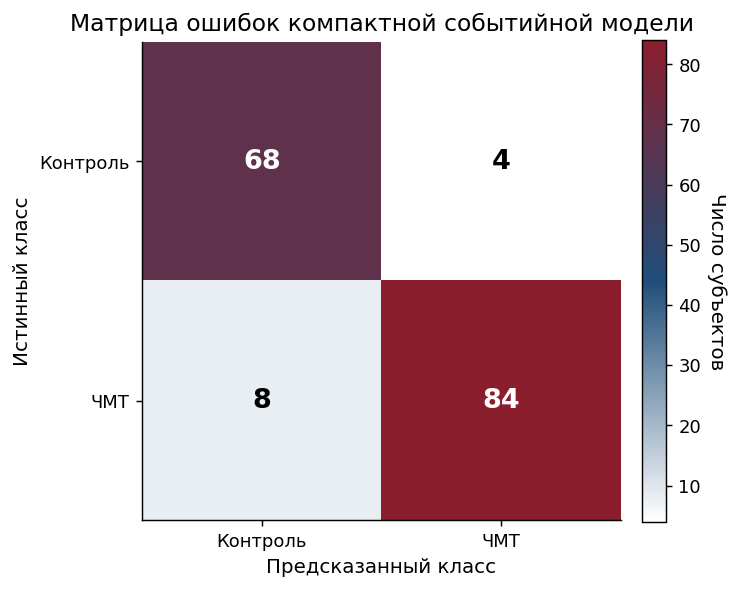

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_calibration_logreg.png


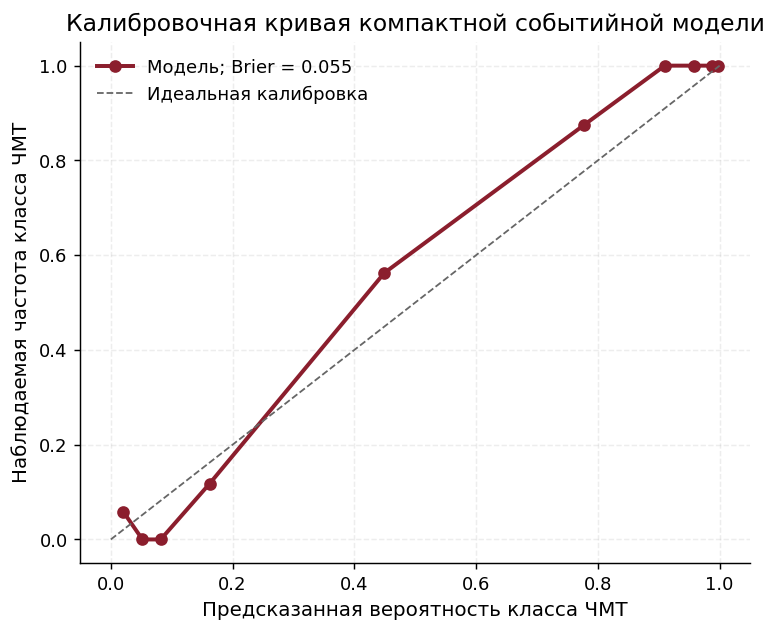

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_roc_curves_all_models.png


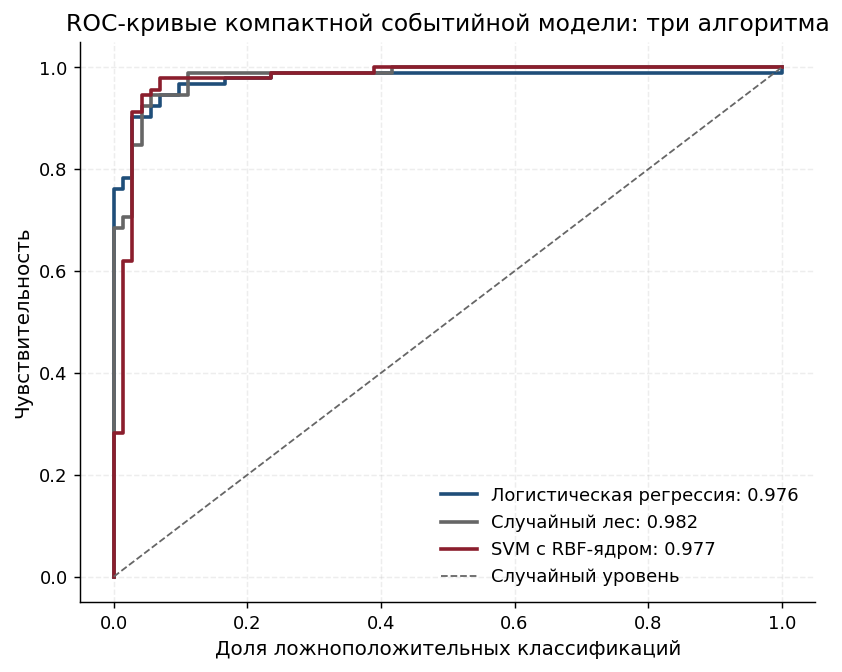

In [34]:
# @title 8.2. Компактная событийная модель: ROC, PR, матрица ошибок и калибровка

if len(EVENT_CORE) == 2 and event_cv_res is not None:
    y_event = event_cv_res["y_true"]
    p_event = event_cv_res["oof_proba"]
    plot_roc_curve_ru(y_event, p_event, "ROC-кривая компактной событийной модели", "08_event_compact_roc_curve_logreg.png")
    plot_pr_curve_ru(y_event, p_event, "Precision–Recall кривая компактной событийной модели", "08_event_compact_pr_curve_logreg.png")
    plot_confusion_matrix_ru(y_event, p_event, "Матрица ошибок компактной событийной модели", "08_event_compact_confusion_matrix_logreg.png")
    plot_calibration_ru(y_event, p_event, "Калибровочная кривая компактной событийной модели", "08_event_compact_calibration_logreg.png")

    fig, ax = plt.subplots(figsize=(6.5, 5.3))
    for model_name in MODEL_ORDER:
        res = event_cv_results[model_name]
        fpr, tpr, _ = roc_curve(res["y_true"], res["oof_proba"])
        auc_val = roc_auc_score(res["y_true"], res["oof_proba"])
        ax.plot(fpr, tpr, linewidth=2.0, color=MODEL_COLORS[model_name], label=f"{MODEL_LABELS[model_name]}: {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color=COLOR_GRAY, label="Случайный уровень")
    ax.set_xlabel("Доля ложноположительных классификаций")
    ax.set_ylabel("Чувствительность")
    ax.set_title("ROC-кривые компактной событийной модели: три алгоритма")
    ax.legend(loc="lower right", frameon=False)
    apply_vkr_axes_style(ax, grid_axis="both")
    save_figure("08_event_compact_roc_curves_all_models.png")
    plt.show()


In [35]:
# @title 8.3. Компактная событийная модель: repeated CV

if len(EVENT_CORE) == 2:
    X_event = subject_df[EVENT_CORE].copy()
    y_event_series = subject_df["y"].astype(int)
    rcv = RepeatedStratifiedKFold(
        n_splits=N_SPLITS,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE,
    )
    pipe_event = make_model("logreg")
    scoring = {
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "accuracy": "accuracy",
        "f1": "f1",
    }
    repeated_scores = cross_validate(
        pipe_event,
        X_event,
        y_event_series,
        cv=rcv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    repeated_df = pd.DataFrame({
        "metric": ["roc_auc", "balanced_accuracy", "accuracy", "f1"],
        "mean": [
            repeated_scores["test_roc_auc"].mean(),
            repeated_scores["test_balanced_accuracy"].mean(),
            repeated_scores["test_accuracy"].mean(),
            repeated_scores["test_f1"].mean(),
        ],
        "std": [
            repeated_scores["test_roc_auc"].std(ddof=1),
            repeated_scores["test_balanced_accuracy"].std(ddof=1),
            repeated_scores["test_accuracy"].std(ddof=1),
            repeated_scores["test_f1"].std(ddof=1),
        ],
    })
    display(repeated_df)
    save_table(repeated_df, "08_event_compact_repeated_cv.csv")

,metric,mean,std
0,roc_auc,0.973880,0.027986
1,balanced_accuracy,0.926211,0.044339
2,accuracy,0.924034,0.045860
3,f1,0.929509,0.044378


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_repeated_cv.csv


,observed_cv_roc_auc,permutation_mean,permutation_std,empirical_p_value
0,0.972309,0.506708,0.062347,0.001996


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_permutation_scores.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_permutation_summary.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_permutation_test.png


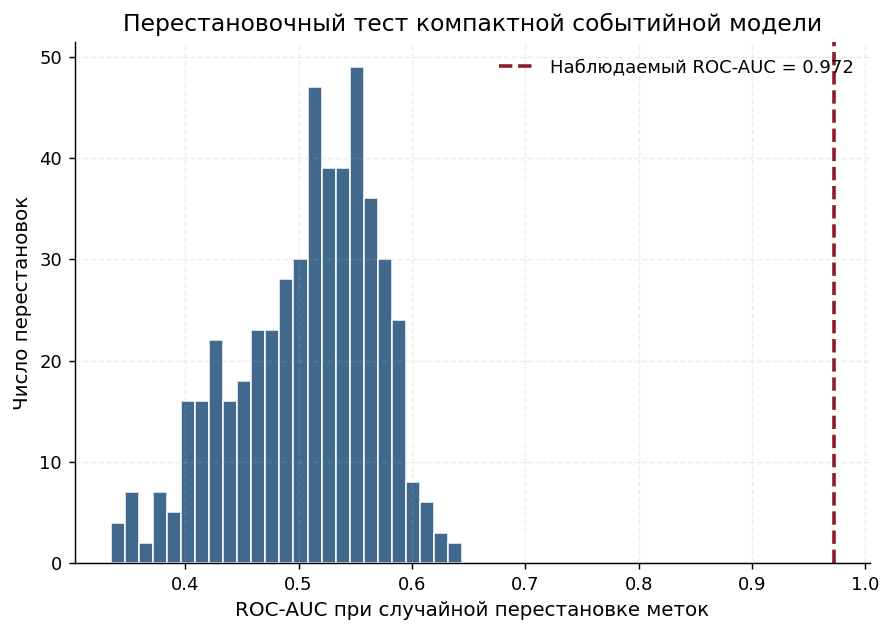

In [36]:
# @title 8.4. Компактная событийная модель: permutation test

if len(EVENT_CORE) == 2:
    X_event = subject_df[EVENT_CORE].copy()
    y_event_series = subject_df["y"].astype(int)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pipe_event = make_model("logreg")
    score, perm_scores, p_value = permutation_test_score(
        pipe_event,
        X_event,
        y_event_series,
        cv=cv,
        scoring="roc_auc",
        n_permutations=500,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    perm_df = pd.DataFrame({"permutation_roc_auc": perm_scores})
    perm_summary_df = pd.DataFrame([{
        "observed_cv_roc_auc": score,
        "permutation_mean": perm_scores.mean(),
        "permutation_std": perm_scores.std(ddof=1),
        "empirical_p_value": p_value,
    }])
    display(perm_summary_df)
    save_table(perm_df, "08_event_compact_permutation_scores.csv")
    save_table(perm_summary_df, "08_event_compact_permutation_summary.csv")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(perm_scores, bins=25, color=COLOR_CONTROL, alpha=0.85, edgecolor="white")
    ax.axvline(score, linestyle="--", linewidth=2, color=COLOR_TBI, label=f"Наблюдаемый ROC-AUC = {score:.3f}")
    ax.set_xlabel("ROC-AUC при случайной перестановке меток")
    ax.set_ylabel("Число перестановок")
    ax.set_title("Перестановочный тест компактной событийной модели")
    ax.legend(frameon=False)
    apply_vkr_axes_style(ax, grid_axis="y")
    save_figure("08_event_compact_permutation_test.png")
    plt.show()


,roc_auc,pr_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision,npv,f1,mcc,threshold,youden_j
32,0.976298,0.985181,0.939024,0.935085,0.967391,0.902778,0.927083,0.955882,0.946809,0.876544,0.33,0.870169


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_threshold_analysis.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_threshold_analysis.png


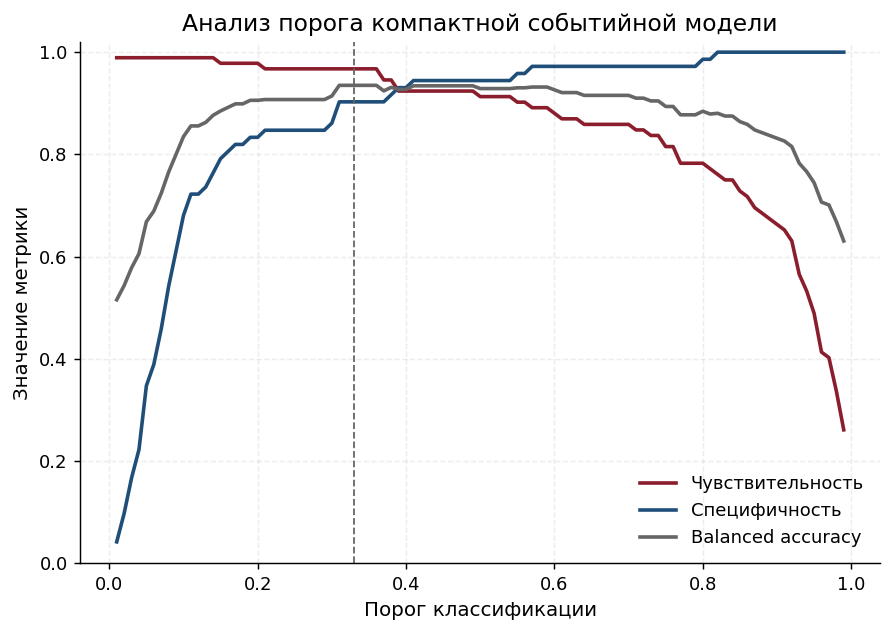

In [37]:
# @title 8.5. Компактная событийная модель: анализ порога по критерию Юдена

if len(EVENT_CORE) == 2 and event_cv_res is not None:
    y_true = event_cv_res["y_true"]
    y_proba = event_cv_res["oof_proba"]
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for thr in thresholds:
        metrics = compute_metrics(y_true, y_proba, threshold=thr)
        metrics["youden_j"] = metrics["sensitivity"] + metrics["specificity"] - 1
        rows.append(metrics)
    threshold_df = pd.DataFrame(rows)
    best_thr_row = threshold_df.sort_values("youden_j", ascending=False).head(1)
    display(best_thr_row)
    save_table(threshold_df, "08_event_compact_threshold_analysis.csv")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(threshold_df["threshold"], threshold_df["sensitivity"], color=COLOR_TBI, linewidth=2, label="Чувствительность")
    ax.plot(threshold_df["threshold"], threshold_df["specificity"], color=COLOR_CONTROL, linewidth=2, label="Специфичность")
    ax.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], color=COLOR_GRAY, linewidth=2, label="Balanced accuracy")
    ax.axvline(float(best_thr_row["threshold"].iloc[0]), linestyle="--", linewidth=1, color=COLOR_GRAY)
    ax.set_xlabel("Порог классификации")
    ax.set_ylabel("Значение метрики")
    ax.set_title("Анализ порога компактной событийной модели")
    ax.legend(loc="best", frameon=False)
    ax.set_ylim(0, 1.02)
    apply_vkr_axes_style(ax, grid_axis="both")
    save_figure("08_event_compact_threshold_analysis.png")
    plt.show()


,fold,feature,coef
0,1,event__z_peak,-1.787822
1,1,event__propagation_ms,1.588279
2,2,event__z_peak,-2.057159
3,2,event__propagation_ms,1.479554
4,3,event__z_peak,-1.741803
5,3,event__propagation_ms,1.513237
6,4,event__z_peak,-2.302787
7,4,event__propagation_ms,1.730510
8,5,event__z_peak,-1.820429
9,5,event__propagation_ms,1.560244


,feature,coef_mean,coef_std,coef_min,coef_max,n_positive,n_negative,n_folds,sign_stability,odds_ratio_per_1sd,direction
0,event__propagation_ms,1.574365,0.096825,1.479554,1.730510,5,0,5,1.0,4.827674,увеличивает вероятность ЧМТ
1,event__z_peak,-1.942000,0.235615,-2.302787,-1.741803,0,5,5,1.0,0.143417,снижает вероятность ЧМТ


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_coefficients_by_fold.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_coefficients_summary.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_event_compact_coefficients.png


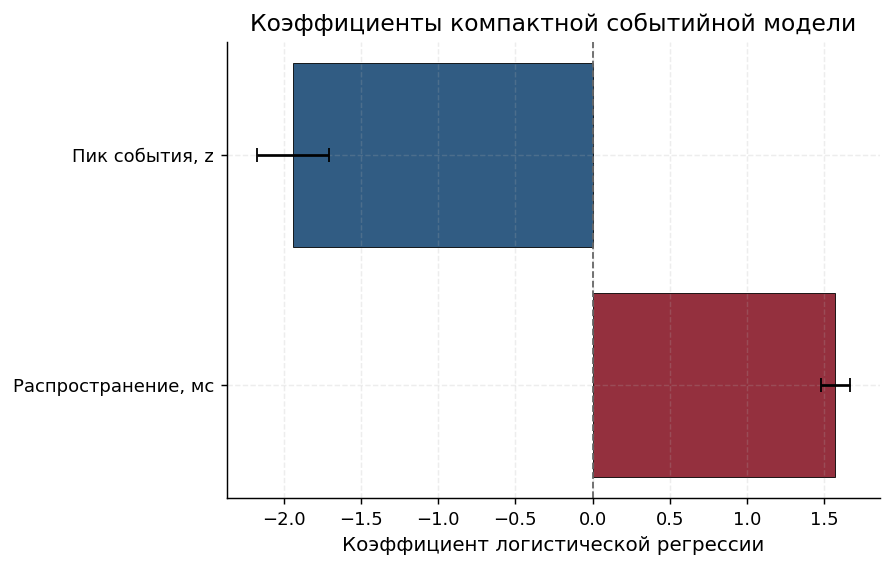

In [38]:
# @title 8.6. Компактная событийная модель: коэффициенты, odds ratio и стабильность знака

if len(EVENT_CORE) == 2:
    X_event = subject_df[EVENT_CORE].copy()
    y_event_series = subject_df["y"].astype(int).reset_index(drop=True)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pipe = make_model("logreg")

    coef_rows = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_event, y_event_series), start=1):
        pipe_fold = clone(pipe)
        pipe_fold.fit(X_event.iloc[train_idx], y_event_series.iloc[train_idx])
        coefs = pipe_fold.named_steps["clf"].coef_[0]
        for feat, coef in zip(EVENT_CORE, coefs):
            coef_rows.append({"fold": fold, "feature": feat, "coef": coef})

    coef_long_df = pd.DataFrame(coef_rows)
    coef_summary_df = (
        coef_long_df.groupby("feature")
        .agg(
            coef_mean=("coef", "mean"),
            coef_std=("coef", "std"),
            coef_min=("coef", "min"),
            coef_max=("coef", "max"),
            n_positive=("coef", lambda s: int((s > 0).sum())),
            n_negative=("coef", lambda s: int((s < 0).sum())),
            n_folds=("coef", "count"),
        )
        .reset_index()
    )
    coef_summary_df["sign_stability"] = coef_summary_df[["n_positive", "n_negative"]].max(axis=1) / coef_summary_df["n_folds"]
    coef_summary_df["odds_ratio_per_1sd"] = np.exp(coef_summary_df["coef_mean"])
    coef_summary_df["direction"] = np.where(
        coef_summary_df["coef_mean"] > 0,
        "увеличивает вероятность ЧМТ",
        "снижает вероятность ЧМТ",
    )

    display(coef_long_df)
    display(coef_summary_df)
    save_table(coef_long_df, "08_event_compact_coefficients_by_fold.csv")
    save_table(coef_summary_df, "08_event_compact_coefficients_summary.csv")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    plot_df = coef_summary_df.copy()
    y_pos = np.arange(len(plot_df))
    colors = np.where(plot_df["coef_mean"] >= 0, COLOR_TBI, COLOR_CONTROL)
    ax.barh(y_pos, plot_df["coef_mean"], xerr=plot_df["coef_std"], capsize=4, color=colors, alpha=0.92, edgecolor="black", linewidth=0.5)
    ax.axvline(0, linestyle="--", linewidth=1, color=COLOR_GRAY)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([clean_feature_label(f) for f in plot_df["feature"]])
    ax.set_xlabel("Коэффициент логистической регрессии")
    ax.set_title("Коэффициенты компактной событийной модели")
    apply_vkr_axes_style(ax, grid_axis="x")
    save_figure("08_event_compact_coefficients.png")
    plt.show()


In [39]:
# @title 8.7. Компактная событийная модель: абляция двух признаков для трёх алгоритмов

if len(EVENT_CORE) == 2:
    variants = {
        "z_peak_only": ["event__z_peak"],
        "propagation_only": ["event__propagation_ms"],
        "both_features": EVENT_CORE,
    }
    ablation_results = []
    ablation_cv_results = {}
    for name, feats in variants.items():
        eval_res = evaluate_feature_set_all_models(
            subject_df,
            feats,
            feature_set_name=name,
            run_holdout=False,
        )
        ablation_results.append(eval_res["metrics"])
        ablation_cv_results[name] = eval_res["cv"]

    ablation_metrics_long_df = pd.concat(ablation_results, ignore_index=True)
    ablation_main_table = ablation_metrics_long_df[
        ablation_metrics_long_df["metric"].isin(["roc_auc", "balanced_accuracy", "accuracy", "f1", "sensitivity", "specificity"])
    ].pivot_table(
        index=["model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value_ci",
        aggfunc="first",
    ).reset_index()
    display(ablation_main_table)
    save_table(ablation_metrics_long_df, "08_event_compact_ablation_metrics_long_all_models.csv")
    save_table(ablation_main_table, "08_event_compact_ablation_main_table_all_models.csv")


metric,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,roc_auc,sensitivity,specificity
0,logreg,Логистическая регрессия,both_features,2,0.927 [0.884; 0.963],0.929 [0.884; 0.967],0.933 [0.891; 0.969],0.976 [0.948; 0.996],0.913 [0.849; 0.967],0.944 [0.884; 0.987]
1,logreg,Логистическая регрессия,propagation_only,1,0.890 [0.835; 0.933],0.892 [0.840; 0.937],0.900 [0.847; 0.943],0.940 [0.898; 0.974],0.880 [0.811; 0.946],0.903 [0.829; 0.969]
2,logreg,Логистическая регрессия,z_peak_only,1,0.945 [0.909; 0.982],0.947 [0.909; 0.981],0.950 [0.914; 0.982],0.965 [0.927; 0.996],0.935 [0.880; 0.980],0.958 [0.908; 1.000]
3,rf,Случайный лес,both_features,2,0.945 [0.909; 0.976],0.945 [0.907; 0.979],0.951 [0.915; 0.981],0.982 [0.964; 0.996],0.946 [0.895; 0.989],0.944 [0.889; 0.987]
4,rf,Случайный лес,propagation_only,1,0.872 [0.817; 0.921],0.871 [0.816; 0.921],0.885 [0.834; 0.931],0.923 [0.875; 0.964],0.880 [0.810; 0.946],0.861 [0.776; 0.938]
5,rf,Случайный лес,z_peak_only,1,0.945 [0.909; 0.976],0.945 [0.907; 0.979],0.951 [0.915; 0.981],0.985 [0.970; 0.996],0.946 [0.895; 0.989],0.944 [0.889; 0.987]
6,svc_rbf,SVM с RBF-ядром,both_features,2,0.945 [0.909; 0.982],0.945 [0.906; 0.981],0.951 [0.914; 0.982],0.977 [0.950; 0.997],0.946 [0.894; 0.989],0.944 [0.884; 0.987]
7,svc_rbf,SVM с RBF-ядром,propagation_only,1,0.890 [0.835; 0.933],0.892 [0.840; 0.937],0.900 [0.847; 0.943],0.927 [0.876; 0.968],0.880 [0.811; 0.946],0.903 [0.829; 0.969]
8,svc_rbf,SVM с RBF-ядром,z_peak_only,1,0.945 [0.909; 0.976],0.945 [0.907; 0.979],0.951 [0.914; 0.981],0.982 [0.962; 0.997],0.946 [0.894; 0.989],0.944 [0.889; 0.987]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_ablation_metrics_long_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_ablation_main_table_all_models.csv


In [40]:
# @title 8.8. Компактная событийная модель: анализ ошибок и пограничных наблюдений

if len(EVENT_CORE) == 2:
    error_df = subject_df[["subject_id", "group", "y", "n_records_subject"] + EVENT_CORE].copy()
    error_df["oof_proba"] = event_cv_res["oof_proba"]
    error_df["oof_pred"] = (error_df["oof_proba"] >= 0.5).astype(int)
    error_df["correct"] = (error_df["y"] == error_df["oof_pred"]).astype(int)

    def error_type(row):
        if row["y"] == 1 and row["oof_pred"] == 1:
            return "TP: ЧМТ верно"
        if row["y"] == 0 and row["oof_pred"] == 0:
            return "TN: контроль верно"
        if row["y"] == 1 and row["oof_pred"] == 0:
            return "FN: ЧМТ → контроль"
        return "FP: контроль → ЧМТ"

    error_df["error_type"] = error_df.apply(error_type, axis=1)
    error_counts = error_df["error_type"].value_counts().reset_index()
    error_counts.columns = ["error_type", "count"]

    feature_error_summary = error_df.groupby("correct")[EVENT_CORE + ["n_records_subject"]].agg(["median", "mean", "std"])

    display(error_counts)
    display(feature_error_summary)
    display(error_df.sort_values("oof_proba", ascending=False).head(20))
    display(error_df.sort_values("oof_proba", ascending=True).head(20))

    save_table(error_df, "08_event_compact_error_analysis_subjects.csv")
    save_table(error_counts, "08_event_compact_error_counts.csv")

,error_type,count
0,TP: ЧМТ верно,84
1,TN: контроль верно,68
2,FN: ЧМТ → контроль,8
3,FP: контроль → ЧМТ,4


event__z_peak                     event__propagation_ms             \
               median      mean       std                median       mean   
correct                                                                      
0            3.721582  3.986540  0.937000                 57.25  56.375000   
1            3.386574  3.531332  0.742692                 61.00  60.842105   

                   n_records_subject                      
               std            median      mean       std  
correct                                                   
0        10.647503               3.0  3.583333  2.274696  
1        13.653641               3.0  3.526316  1.862660

,subject_id,group,y,n_records_subject,event__z_peak,event__propagation_ms,oof_proba,oof_pred,correct,error_type
123,tbi-3053,TBI,1,1,1.110964,68.0,0.999528,1,1,TP: ЧМТ верно
107,tbi-3037,TBI,1,3,2.776297,98.0,0.998807,1,1,TP: ЧМТ верно
80,tbi-3009,TBI,1,2,2.630927,85.0,0.998729,1,1,TP: ЧМТ верно
140,tbi-3074,TBI,1,2,1.958783,77.0,0.998621,1,1,TP: ЧМТ верно
152,tbi-3098,TBI,1,3,2.744629,86.0,0.998415,1,1,TP: ЧМТ верно
84,tbi-3013,TBI,1,3,2.518465,90.0,0.998106,1,1,TP: ЧМТ верно
160,tbi-3114,TBI,1,1,2.534316,90.0,0.998036,1,1,TP: ЧМТ верно
135,tbi-3065,TBI,1,3,2.212422,78.0,0.997690,1,1,TP: ЧМТ верно
103,tbi-3033,TBI,1,3,2.520266,84.0,0.997001,1,1,TP: ЧМТ верно
81,tbi-3010,TBI,1,3,2.933146,84.0,0.996318,1,1,TP: ЧМТ верно


,subject_id,group,y,n_records_subject,event__z_peak,event__propagation_ms,oof_proba,oof_pred,correct,error_type
151,tbi-3096,TBI,1,1,6.557851,32.0,0.000004,0,0,FN: ЧМТ → контроль
2,sub-003,Control,0,4,4.856647,33.0,0.003275,0,1,TN: контроль верно
61,sub-140,Control,0,4,5.143043,42.0,0.005538,0,1,TN: контроль верно
16,sub-057,Control,0,4,4.483102,42.5,0.009645,0,1,TN: контроль верно
71,sub-150,Control,0,4,5.148175,59.0,0.010711,0,1,TN: контроль верно
13,sub-054,Control,0,4,4.290893,41.5,0.015242,0,1,TN: контроль верно
5,sub-006,Control,0,4,4.328189,44.0,0.018780,0,1,TN: контроль верно
27,sub-106,Control,0,4,4.407399,38.5,0.019629,0,1,TN: контроль верно
6,sub-007,Control,0,4,4.682498,46.5,0.022326,0,1,TN: контроль верно
29,sub-108,Control,0,4,4.295837,45.0,0.023548,0,1,TN: контроль верно


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_error_analysis_subjects.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_compact_error_counts.csv


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci,comparison_group
0,logreg,Логистическая регрессия,61,spectral_baseline,cv_oof,roc_auc,0.831069,0.766245,0.887840,0.831 [0.766; 0.888],spectral_baseline
3,logreg,Логистическая регрессия,61,spectral_baseline,cv_oof,balanced_accuracy,0.765399,0.696215,0.829281,0.765 [0.696; 0.829],spectral_baseline
4,logreg,Логистическая регрессия,61,spectral_baseline,cv_oof,sensitivity,0.739130,0.644730,0.822788,0.739 [0.645; 0.823],spectral_baseline
5,logreg,Логистическая регрессия,61,spectral_baseline,cv_oof,specificity,0.791667,0.696605,0.880597,0.792 [0.697; 0.881],spectral_baseline
10,logreg,Логистическая регрессия,61,spectral_baseline,holdout,roc_auc,0.883459,0.744361,0.989015,0.883 [0.744; 0.989],spectral_baseline
13,logreg,Логистическая регрессия,61,spectral_baseline,holdout,balanced_accuracy,0.840226,0.704545,0.961607,0.840 [0.705; 0.962],spectral_baseline
14,logreg,Логистическая регрессия,61,spectral_baseline,holdout,sensitivity,0.894737,0.736842,1.000000,0.895 [0.737; 1.000],spectral_baseline
15,logreg,Логистическая регрессия,61,spectral_baseline,holdout,specificity,0.785714,0.538462,1.000000,0.786 [0.538; 1.000],spectral_baseline
20,rf,Случайный лес,61,spectral_baseline,cv_oof,roc_auc,0.812198,0.747310,0.876666,0.812 [0.747; 0.877],spectral_baseline
23,rf,Случайный лес,61,spectral_baseline,cv_oof,balanced_accuracy,0.750000,0.685908,0.817074,0.750 [0.686; 0.817],spectral_baseline


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_baseline_vs_event_compact_metrics_long_all_models.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_baseline_vs_event_compact_roc_auc_all_models.png


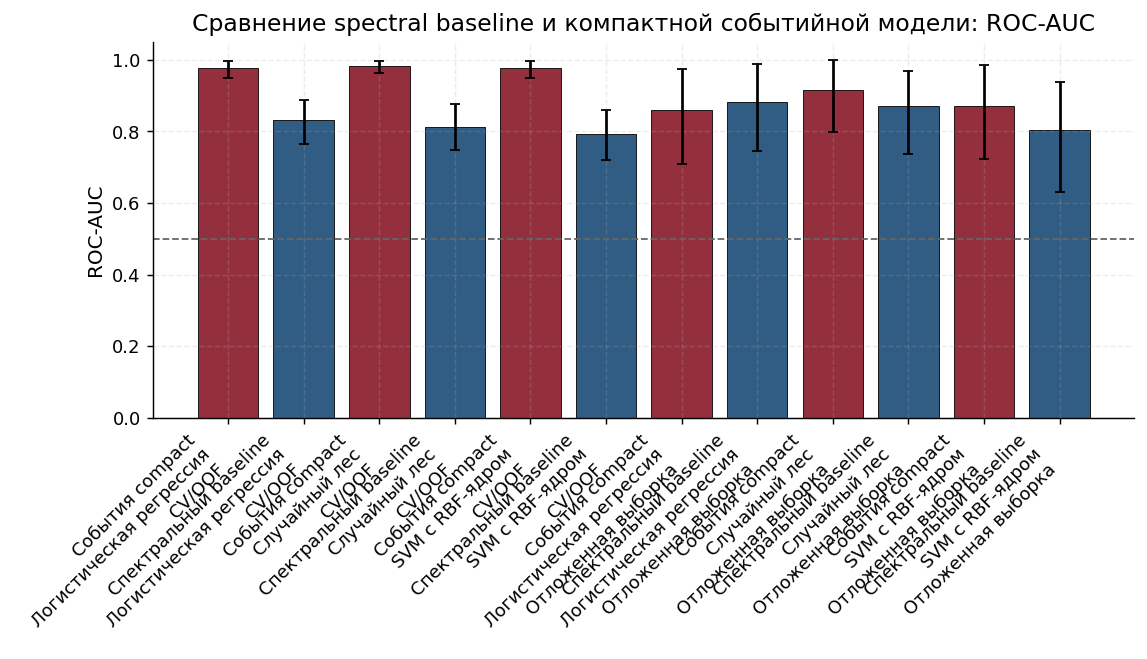

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_baseline_vs_event_compact_balanced_accuracy_all_models.png


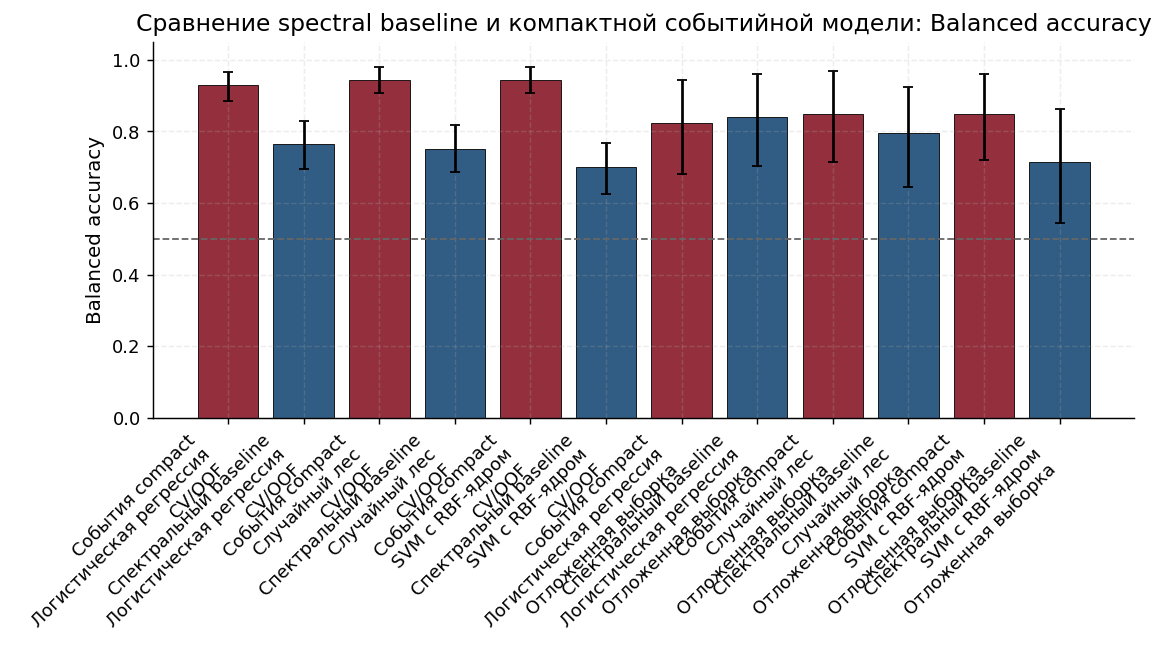

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_baseline_vs_event_compact_sensitivity_all_models.png


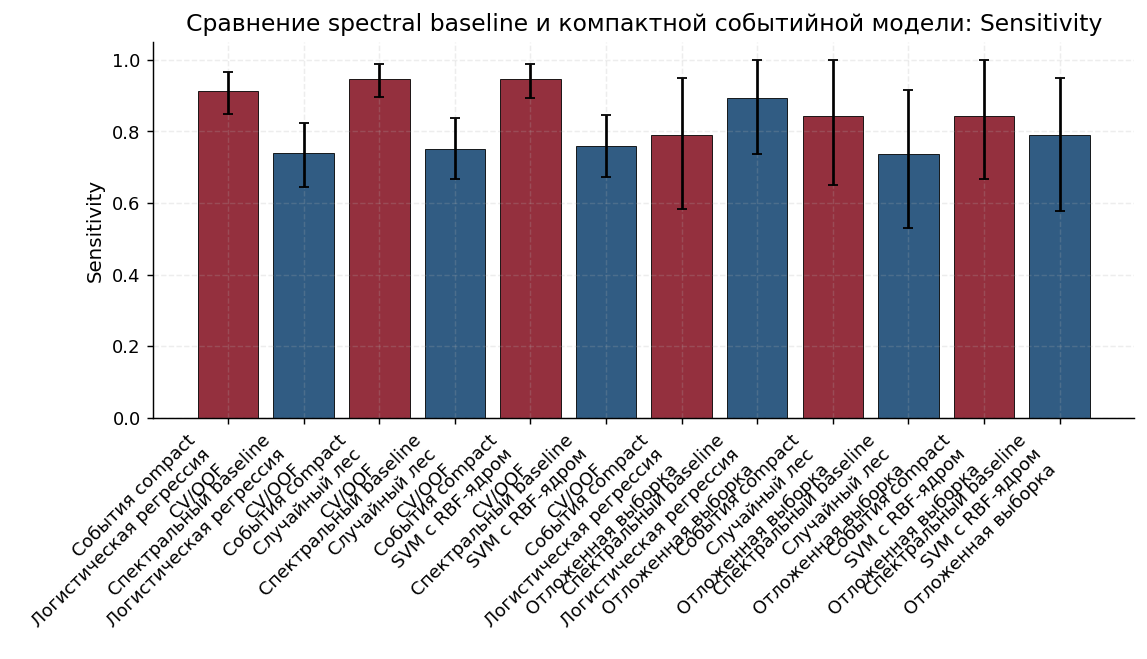

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/08_baseline_vs_event_compact_specificity_all_models.png


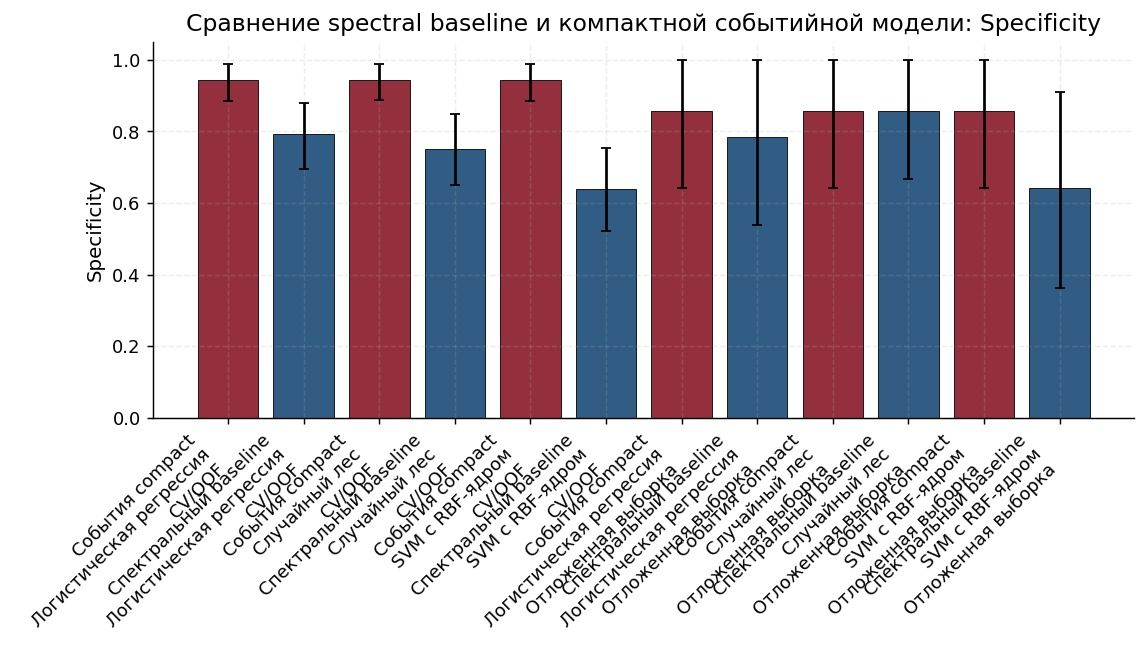

In [41]:
# @title 8.9. Прямое сравнение spectral baseline и компактной событийной модели

if (
    "baseline_metrics_df" in globals()
    and "event_metrics_df" in globals()
    and len(baseline_metrics_df) > 0
    and len(event_metrics_df) > 0
):
    baseline_vs_event_metrics_df = pd.concat([
        baseline_metrics_df.assign(comparison_group="spectral_baseline"),
        event_metrics_df.assign(comparison_group="event_compact"),
    ], ignore_index=True)

    compare_metrics = ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
    plot_df = baseline_vs_event_metrics_df[
        (baseline_vs_event_metrics_df["validation"].isin(["cv_oof", "holdout"]))
        & (baseline_vs_event_metrics_df["metric"].isin(compare_metrics))
    ].copy()

    display(plot_df)
    save_table(baseline_vs_event_metrics_df, "08_baseline_vs_event_compact_metrics_long_all_models.csv")

    for metric in compare_metrics:
        sub = plot_df[plot_df["metric"] == metric].copy()
        sub["x_label"] = (
            sub["feature_set"].map(clean_feature_label)
            + "\n"
            + sub["model"].map(MODEL_LABELS)
            + "\n"
            + sub["validation"].map(VALIDATION_RU)
        )
        sub = sub.sort_values(["validation", "model", "feature_set"])

        fig, ax = plt.subplots(figsize=(max(9, 0.7 * len(sub)), 5.2))
        x = np.arange(len(sub))
        xerr = np.vstack([
            sub["value"] - sub["ci_low"],
            sub["ci_high"] - sub["value"],
        ])
        colors = sub["feature_set"].map({
            "spectral_baseline": COLOR_CONTROL,
            "event_compact": COLOR_TBI,
        }).fillna(COLOR_GRAY)
        ax.bar(x, sub["value"], yerr=xerr, capsize=3, color=colors, alpha=0.92, edgecolor="black", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["x_label"], rotation=45, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(METRIC_RU.get(metric, metric))
        ax.set_title(f"Сравнение spectral baseline и компактной событийной модели: {METRIC_RU.get(metric, metric)}")
        if metric in ["roc_auc", "balanced_accuracy"]:
            ax.axhline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY)
        apply_vkr_axes_style(ax, grid_axis="y")
        save_figure(f"08_baseline_vs_event_compact_{metric}_all_models.png")
        plt.show()
else:
    print("Сначала нужно выполнить разделы 5.1 и 8.1.")


In [42]:
# @title 8.10. Bootstrap-сравнение разницы ROC-AUC: event compact против spectral baseline

def bootstrap_metric_difference(
    y_true,
    proba_a,
    proba_b,
    metric_func,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true).astype(int)
    proba_a = np.asarray(proba_a).astype(float)
    proba_b = np.asarray(proba_b).astype(float)

    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        diffs.append(metric_func(y_true[idx], proba_a[idx]) - metric_func(y_true[idx], proba_b[idx]))

    diffs = np.asarray(diffs)
    point_diff = metric_func(y_true, proba_a) - metric_func(y_true, proba_b)
    return {
        "diff_event_minus_baseline": point_diff,
        "ci_low": np.percentile(diffs, 2.5) if len(diffs) else np.nan,
        "ci_high": np.percentile(diffs, 97.5) if len(diffs) else np.nan,
        "p_boot_two_sided": 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)) if len(diffs) else np.nan,
    }


if "baseline_cv_results" in globals() and "event_cv_results" in globals() and len(EVENT_CORE) == 2:
    diff_rows = []
    for model_name in MODEL_ORDER:
        if model_name not in baseline_cv_results or model_name not in event_cv_results:
            continue
        y_true = event_cv_results[model_name]["y_true"]
        p_event = event_cv_results[model_name]["oof_proba"]
        p_base = baseline_cv_results[model_name]["oof_proba"]

        diff_rows.append({
            "model": model_name,
            "model_ru": MODEL_LABELS[model_name],
            "metric": "roc_auc",
            **bootstrap_metric_difference(y_true, p_event, p_base, roc_auc_score),
        })
        diff_rows.append({
            "model": model_name,
            "model_ru": MODEL_LABELS[model_name],
            "metric": "balanced_accuracy",
            **bootstrap_metric_difference(
                y_true,
                p_event,
                p_base,
                lambda y, p: balanced_accuracy_score(y, (p >= 0.5).astype(int)),
            ),
        })
        diff_rows.append({
            "model": model_name,
            "model_ru": MODEL_LABELS[model_name],
            "metric": "brier_score_negative",
            **bootstrap_metric_difference(
                y_true,
                -p_event,
                -p_base,
                lambda y, p: -brier_score_loss(y, -p),
            ),
        })

    baseline_vs_event_diff_df = pd.DataFrame(diff_rows)
    display(baseline_vs_event_diff_df)
    save_table(baseline_vs_event_diff_df, "08_baseline_vs_event_bootstrap_metric_differences_all_models.csv")
else:
    print("Сначала нужно выполнить baseline_cv_results и event_cv_results.")


,model,model_ru,metric,diff_event_minus_baseline,ci_low,ci_high,p_boot_two_sided
0,logreg,Логистическая регрессия,roc_auc,0.145229,0.082461,0.216803,0.0
1,logreg,Логистическая регрессия,balanced_accuracy,0.163345,0.085568,0.244940,0.0
2,logreg,Логистическая регрессия,brier_score_negative,0.119241,0.075243,0.164535,0.0
3,rf,Случайный лес,roc_auc,0.169837,0.100836,0.237731,0.0
4,rf,Случайный лес,balanced_accuracy,0.195048,0.118700,0.268544,0.0
5,rf,Случайный лес,brier_score_negative,0.129225,0.088312,0.165882,0.0
6,svc_rbf,SVM с RBF-ядром,roc_auc,0.183575,0.107847,0.263832,0.0
7,svc_rbf,SVM с RBF-ядром,balanced_accuracy,0.245169,0.158040,0.327938,0.0
8,svc_rbf,SVM с RBF-ядром,brier_score_negative,0.141956,0.101167,0.179851,0.0


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_baseline_vs_event_bootstrap_metric_differences_all_models.csv


In [43]:
# @title 8.11. Nested-проверка: выбор 2 событийных признаков только внутри train-фолда

def evaluate_event_top2_nested(df, event_features, model_name="logreg", k=2):
    X_all = df[event_features].copy()
    y_all = df["y"].astype(int).reset_index(drop=True)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pipe = make_model(model_name)
    oof_proba = np.zeros(len(y_all), dtype=float)
    selected_rows = []
    fold_counts = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all), start=1):
        selected = select_top_k_on_train(
            X_all.iloc[train_idx],
            y_all.iloc[train_idx],
            event_features,
            k=k,
        )
        selected_rows.extend([
            {"fold": fold, "model": model_name, "feature": feat, "n_selected": len(selected)}
            for feat in selected
        ])

        pipe_fold = clone(pipe)
        pipe_fold.fit(X_all.iloc[train_idx][selected], y_all.iloc[train_idx])
        oof_proba[test_idx] = pipe_fold.predict_proba(X_all.iloc[test_idx][selected])[:, 1]

        fold_counts.append({
            "fold": fold,
            "model": model_name,
            "n_selected": len(selected),
            "n_train_total": len(train_idx),
            "n_test_total": len(test_idx),
            "n_train_control": int((y_all.iloc[train_idx] == 0).sum()),
            "n_train_tbi": int((y_all.iloc[train_idx] == 1).sum()),
            "n_test_control": int((y_all.iloc[test_idx] == 0).sum()),
            "n_test_tbi": int((y_all.iloc[test_idx] == 1).sum()),
        })

    metric_ci = bootstrap_ci_for_metrics(y_all, oof_proba, threshold=0.5)
    metric_ci.insert(0, "validation", "nested_cv_top2_event")
    metric_ci.insert(0, "feature_set", "event_top2_train_only")
    metric_ci.insert(0, "n_features", k)
    metric_ci.insert(0, "model_ru", MODEL_LABELS[model_name])
    metric_ci.insert(0, "model", model_name)

    return metric_ci, pd.DataFrame(selected_rows), pd.DataFrame(fold_counts), oof_proba


event_features_all = FEATURE_SETS.get("event", [])

if len(event_features_all) >= 2:
    nested_results = []
    nested_selected = []
    nested_counts = []
    nested_oof_predictions = {}

    for model_name in MODEL_ORDER:
        metric_ci, selected_df, counts_df, oof_proba = evaluate_event_top2_nested(
            subject_df,
            event_features_all,
            model_name=model_name,
            k=2,
        )
        nested_results.append(metric_ci)
        nested_selected.append(selected_df)
        nested_counts.append(counts_df)
        nested_oof_predictions[model_name] = oof_proba

    nested_event_metrics_df = pd.concat(nested_results, ignore_index=True)
    nested_event_selected_df = pd.concat(nested_selected, ignore_index=True)
    nested_event_counts_df = pd.concat(nested_counts, ignore_index=True)
    nested_event_selection_freq_df = (
        nested_event_selected_df
        .groupby(["model", "feature"])
        .size()
        .reset_index(name="n_selected_folds")
        .sort_values(["model", "n_selected_folds"], ascending=[True, False])
    )

    display(nested_event_metrics_df)
    display(nested_event_selection_freq_df)
    save_table(nested_event_metrics_df, "08_event_top2_nested_cv_metrics_all_models.csv")
    save_table(nested_event_selection_freq_df, "08_event_top2_nested_cv_selection_frequency_all_models.csv")
    save_table(nested_event_counts_df, "08_event_top2_nested_cv_fold_counts_all_models.csv")
else:
    print("Недостаточно event-признаков для nested top-2 проверки.")


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci
0,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,roc_auc,0.969052,0.935564,0.995139,0.969 [0.936; 0.995]
1,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,pr_auc,0.982252,0.963971,0.995985,0.982 [0.964; 0.996]
2,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,accuracy,0.926829,0.884146,0.963415,0.927 [0.884; 0.963]
3,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,balanced_accuracy,0.928744,0.886116,0.967193,0.929 [0.886; 0.967]
4,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,sensitivity,0.913043,0.848828,0.968085,0.913 [0.849; 0.968]
5,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,specificity,0.944444,0.884034,0.987179,0.944 [0.884; 0.987]
6,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,precision,0.954545,0.905882,0.989474,0.955 [0.906; 0.989]
7,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,npv,0.894737,0.819444,0.960539,0.895 [0.819; 0.961]
8,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,f1,0.933333,0.890321,0.969395,0.933 [0.890; 0.969]
9,logreg,Логистическая регрессия,2,event_top2_train_only,nested_cv_top2_event,mcc,0.853375,0.765543,0.929402,0.853 [0.766; 0.929]


,model,feature,n_selected_folds
2,logreg,event__z_peak,5
0,logreg,event__propagation_ms,4
1,logreg,event__spike_to_slow_ratio,1
5,rf,event__z_peak,5
3,rf,event__propagation_ms,4
4,rf,event__spike_to_slow_ratio,1
8,svc_rbf,event__z_peak,5
6,svc_rbf,event__propagation_ms,4
7,svc_rbf,event__spike_to_slow_ratio,1


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_top2_nested_cv_metrics_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_top2_nested_cv_selection_frequency_all_models.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/08_event_top2_nested_cv_fold_counts_all_models.csv


## 9. Проверки на возможные смешивающие факторы

Раздел не доказывает отсутствие всех confounds, но помогает проверить наиболее очевидные источники искажения: число записей на субъект, QC-показатели и технические метаданные. Эти проверки нужны для защиты от вопроса, не классифицирует ли модель качество записи вместо ЧМТ.

In [44]:
# @title 9.1. Связь вероятности ЧМТ с числом записей и QC/meta-показателями

if len(EVENT_CORE) == 2 and event_cv_res is not None:
    pred_meta_rows = []
    available_meta = [c for c in qc_candidates if c in subject_df.columns]
    if "n_records_subject" not in available_meta and "n_records_subject" in subject_df.columns:
        available_meta.append("n_records_subject")

    pred_series = pd.Series(event_cv_res["oof_proba"], name="oof_proba")
    for col in available_meta:
        tmp = pd.DataFrame({"pred": pred_series, "meta": subject_df[col]}).dropna()
        if len(tmp) < 10 or tmp["meta"].std() == 0:
            continue
        pred_meta_rows.append({
            "meta_or_qc": col,
            "spearman_r_with_oof_proba": tmp["pred"].corr(tmp["meta"], method="spearman"),
            "n": len(tmp),
        })

    pred_meta_corr_df = pd.DataFrame(pred_meta_rows)
    if len(pred_meta_corr_df) > 0:
        pred_meta_corr_df["abs_r"] = pred_meta_corr_df["spearman_r_with_oof_proba"].abs()
        pred_meta_corr_df = pred_meta_corr_df.sort_values("abs_r", ascending=False)
        display(pred_meta_corr_df)
        save_table(pred_meta_corr_df, "09_event_prediction_meta_qc_correlations.csv")
    else:
        print("Не найдено подходящих QC/meta столбцов для корреляционного анализа.")


,meta_or_qc,spearman_r_with_oof_proba,n,abs_r
0,n_records_subject,-0.703211,164,0.703211


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/09_event_prediction_meta_qc_correlations.csv


In [45]:
# @title 9.2. Sensitivity analysis: исключение субъектов с одной записью для трёх алгоритмов

if len(EVENT_CORE) == 2 and "n_records_subject" in subject_df.columns:
    subset_df = subject_df[subject_df["n_records_subject"] > 1].copy()
    print("Исходная выборка:", subject_df.shape[0])
    print("После исключения n_records_subject == 1:", subset_df.shape[0])
    print("Контроль:", int((subset_df["y"] == 0).sum()))
    print("ЧМТ:", int((subset_df["y"] == 1).sum()))

    if subset_df["y"].nunique() == 2 and len(subset_df) >= 30:
        sens_eval = evaluate_feature_set_all_models(
            subset_df,
            EVENT_CORE,
            feature_set_name="event_compact_no_single_record_subjects",
            run_holdout=False,
        )
        sens_metrics_df = sens_eval["metrics"]
        display(sens_metrics_df)
        save_table(sens_metrics_df, "09_event_compact_sensitivity_no_single_record_subjects_all_models.csv")
    else:
        print("Недостаточно данных после фильтрации для CV.")


Исходная выборка: 164
После исключения n_records_subject == 1: 145
Контроль: 72
ЧМТ: 73


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci
0,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,roc_auc,0.983447,0.961662,0.998462,0.983 [0.962; 0.998]
1,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,pr_auc,0.986126,0.967681,0.998475,0.986 [0.968; 0.998]
2,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,accuracy,0.951724,0.917241,0.986207,0.952 [0.917; 0.986]
3,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,balanced_accuracy,0.951769,0.916187,0.986015,0.952 [0.916; 0.986]
4,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,sensitivity,0.945205,0.887500,0.988515,0.945 [0.887; 0.989]
5,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,specificity,0.958333,0.907692,1.000000,0.958 [0.908; 1.000]
6,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,precision,0.958333,0.910256,1.000000,0.958 [0.910; 1.000]
7,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,npv,0.945205,0.887324,0.988235,0.945 [0.887; 0.988]
8,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,f1,0.951724,0.911765,0.984854,0.952 [0.912; 0.985]
9,logreg,Логистическая регрессия,2,event_compact_no_single_record_subjects,cv_oof,mcc,0.903539,0.833487,0.972117,0.904 [0.833; 0.972]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/09_event_compact_sensitivity_no_single_record_subjects_all_models.csv


In [46]:
# @title 9.3. Negative control: классификация только по числу записей

if "n_records_subject" in subject_df.columns:
    negative_control_features = ["n_records_subject"]
    neg_eval = evaluate_feature_set_all_models(
        subject_df,
        negative_control_features,
        feature_set_name="negative_control_n_records_only",
        run_holdout=False,
    )
    negative_control_metrics_df = neg_eval["metrics"]
    display(negative_control_metrics_df)
    save_table(negative_control_metrics_df, "09_negative_control_n_records_only_metrics_all_models.csv")
else:
    print("n_records_subject отсутствует даже среди служебных ковариат.")


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci
0,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,roc_auc,1.0,1.0,1.0,1.000 [1.000; 1.000]
1,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,pr_auc,1.0,1.0,1.0,1.000 [1.000; 1.000]
2,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,accuracy,1.0,1.0,1.0,1.000 [1.000; 1.000]
3,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,balanced_accuracy,1.0,1.0,1.0,1.000 [1.000; 1.000]
4,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,sensitivity,1.0,1.0,1.0,1.000 [1.000; 1.000]
5,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,specificity,1.0,1.0,1.0,1.000 [1.000; 1.000]
6,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,precision,1.0,1.0,1.0,1.000 [1.000; 1.000]
7,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,npv,1.0,1.0,1.0,1.000 [1.000; 1.000]
8,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,f1,1.0,1.0,1.0,1.000 [1.000; 1.000]
9,logreg,Логистическая регрессия,1,negative_control_n_records_only,cv_oof,mcc,1.0,1.0,1.0,1.000 [1.000; 1.000]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/09_negative_control_n_records_only_metrics_all_models.csv


In [47]:
# @title 9.4. Sensitivity analysis: сопоставимый диапазон числа записей

if len(EVENT_CORE) == 2 and "n_records_subject" in subject_df.columns:
    matched_df = subject_df[subject_df["n_records_subject"].between(2, 4)].copy()

    print("Исходная выборка:", subject_df.shape[0])
    print("После ограничения 2–4 записи:", matched_df.shape[0])
    display(
        matched_df
        .groupby(["_group_pretty", "y"])
        .agg(
            n_subjects=("subject_id", "nunique"),
            median_records=("n_records_subject", "median"),
            min_records=("n_records_subject", "min"),
            max_records=("n_records_subject", "max"),
        )
        .reset_index()
    )

    if matched_df["y"].nunique() == 2 and len(matched_df) >= 30:
        matched_eval = evaluate_feature_set_all_models(
            matched_df,
            EVENT_CORE,
            feature_set_name="event_compact_matched_records_2_4",
            run_holdout=False,
        )
        matched_sensitivity_metrics_df = matched_eval["metrics"]
        display(matched_sensitivity_metrics_df)
        save_table(matched_sensitivity_metrics_df, "09_event_compact_sensitivity_matched_records_2_4_all_models.csv")
    else:
        print("Недостаточно данных для matched sensitivity analysis.")
else:
    print("Нет EVENT_CORE или n_records_subject для анализа.")


Исходная выборка: 164
После ограничения 2–4 записи: 126


,_group_pretty,y,n_subjects,median_records,min_records,max_records
0,Контроль,0,53,4.0,4,4
1,ЧМТ,1,73,3.0,2,3


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci
0,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,roc_auc,0.986560,0.966412,0.999742,0.987 [0.966; 1.000]
1,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,pr_auc,0.991407,0.978734,0.999805,0.991 [0.979; 1.000]
2,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,accuracy,0.952381,0.912698,0.984127,0.952 [0.913; 0.984]
3,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,balanced_accuracy,0.953735,0.914262,0.986301,0.954 [0.914; 0.986]
4,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,sensitivity,0.945205,0.884034,0.987500,0.945 [0.884; 0.988]
5,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,specificity,0.962264,0.900000,1.000000,0.962 [0.900; 1.000]
6,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,precision,0.971831,0.925926,1.000000,0.972 [0.926; 1.000]
7,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,npv,0.927273,0.851852,0.983607,0.927 [0.852; 0.984]
8,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,f1,0.958333,0.921983,0.987179,0.958 [0.922; 0.987]
9,logreg,Логистическая регрессия,2,event_compact_matched_records_2_4,cv_oof,mcc,0.903277,0.823005,0.968555,0.903 [0.823; 0.969]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/09_event_compact_sensitivity_matched_records_2_4_all_models.csv


In [48]:
# @title 9.5. Контрольная модель: событийные признаки + число записей

if len(EVENT_CORE) == 2 and "n_records_subject" in subject_df.columns:
    adjusted_features = EVENT_CORE + ["n_records_subject"]
    adjusted_eval = evaluate_feature_set_all_models(
        subject_df,
        adjusted_features,
        feature_set_name="event_compact_plus_n_records_control_covariate",
        run_holdout=False,
    )
    adjusted_covariate_metrics_df = adjusted_eval["metrics"]
    display(adjusted_covariate_metrics_df)
    save_table(adjusted_covariate_metrics_df, "09_event_compact_plus_n_records_control_covariate_metrics_all_models.csv")

    print(
        "Важно: n_records_subject используется здесь только как контрольная техническая ковариата "
        "и не входит в итоговую интерпретируемую компактную модель."
    )
else:
    print("Нет EVENT_CORE или n_records_subject для контрольной модели.")


,model,model_ru,n_features,feature_set,validation,metric,value,ci_low,ci_high,value_ci
0,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,roc_auc,0.991999,0.973660,1.0,0.992 [0.974; 1.000]
1,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,pr_auc,0.996027,0.986532,1.0,0.996 [0.987; 1.000]
2,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,accuracy,0.993902,0.981707,1.0,0.994 [0.982; 1.000]
3,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,balanced_accuracy,0.994565,0.982759,1.0,0.995 [0.983; 1.000]
4,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,sensitivity,0.989130,0.965517,1.0,0.989 [0.966; 1.000]
5,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,specificity,1.000000,1.000000,1.0,1.000 [1.000; 1.000]
6,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,precision,1.000000,1.000000,1.0,1.000 [1.000; 1.000]
7,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,npv,0.986301,0.956522,1.0,0.986 [0.957; 1.000]
8,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,f1,0.994536,0.982456,1.0,0.995 [0.982; 1.000]
9,logreg,Логистическая регрессия,3,event_compact_plus_n_records_control_covariate,cv_oof,mcc,0.987715,0.962933,1.0,0.988 [0.963; 1.000]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/09_event_compact_plus_n_records_control_covariate_metrics_all_models.csv
Важно: n_records_subject используется здесь только как контрольная техническая ковариата и не входит в итоговую интерпретируемую компактную модель.


## 10. Экспорт итоговых таблиц для ВКР

Раздел собирает ключевые таблицы в компактном виде. Они предназначены для последующей ручной вставки в текст ВКР и презентацию.

In [49]:
# @title 10.1. Единая таблица основных экспериментов

summary_parts = []
for name in [
    "full_feature_space_metrics_df",
    "algorithm_metrics_long_df",
    "baseline_metrics_df",
    "blockwise_metrics_long_df",
    "topk_metrics_long_df",
    "holdout_block_metrics_long_df",
    "event_metrics_df",
    "baseline_vs_event_metrics_df",
    "baseline_vs_event_diff_df",
    "nested_event_metrics_df",
    "negative_control_metrics_df",
    "sens_metrics_df",
    "matched_sensitivity_metrics_df",
    "adjusted_covariate_metrics_df",
    "ablation_metrics_long_df",
]:
    if name in globals():
        df_part = globals()[name].copy()
        if len(df_part) == 0:
            continue
        df_part["source_table"] = name
        summary_parts.append(df_part)

if summary_parts:
    final_metrics_long_df = pd.concat(summary_parts, ignore_index=True)
    final_metrics_table = final_metrics_long_df[
        final_metrics_long_df["metric"].isin(["roc_auc", "pr_auc", "balanced_accuracy", "accuracy", "sensitivity", "specificity", "f1", "mcc"])
    ].pivot_table(
        index=["source_table", "validation", "model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value_ci",
        aggfunc="first",
    ).reset_index()
    display(final_metrics_table)
    save_table(final_metrics_long_df, "10_final_all_metrics_long.csv")
    save_table(final_metrics_table, "10_final_metrics_table_for_vkr.csv")
else:
    print("Нет таблиц метрик для объединения. Запусти предыдущие разделы.")


metric,source_table,validation,model,model_ru,feature_set,n_features,accuracy,balanced_accuracy,f1,mcc,pr_auc,roc_auc,sensitivity,specificity
0,ablation_metrics_long_df,cv_oof,logreg,Логистическая регрессия,both_features,2.0,0.927 [0.884; 0.963],0.929 [0.884; 0.967],0.933 [0.891; 0.969],0.853 [0.764; 0.929],0.985 [0.969; 0.997],0.976 [0.948; 0.996],0.913 [0.849; 0.967],0.944 [0.884; 0.987]
1,ablation_metrics_long_df,cv_oof,logreg,Логистическая регрессия,propagation_only,1.0,0.890 [0.835; 0.933],0.892 [0.840; 0.937],0.900 [0.847; 0.943],0.779 [0.677; 0.868],0.958 [0.926; 0.983],0.940 [0.898; 0.974],0.880 [0.811; 0.946],0.903 [0.829; 0.969]
2,ablation_metrics_long_df,cv_oof,logreg,Логистическая регрессия,z_peak_only,1.0,0.945 [0.909; 0.982],0.947 [0.909; 0.981],0.950 [0.914; 0.982],0.890 [0.814; 0.962],0.982 [0.963; 0.997],0.965 [0.927; 0.996],0.935 [0.880; 0.980],0.958 [0.908; 1.000]
3,ablation_metrics_long_df,cv_oof,rf,Случайный лес,both_features,2.0,0.945 [0.909; 0.976],0.945 [0.907; 0.979],0.951 [0.915; 0.981],0.889 [0.813; 0.952],0.986 [0.971; 0.997],0.982 [0.964; 0.996],0.946 [0.895; 0.989],0.944 [0.889; 0.987]
4,ablation_metrics_long_df,cv_oof,rf,Случайный лес,propagation_only,1.0,0.872 [0.817; 0.921],0.871 [0.816; 0.921],0.885 [0.834; 0.931],0.740 [0.631; 0.841],0.932 [0.877; 0.974],0.923 [0.875; 0.964],0.880 [0.810; 0.946],0.861 [0.776; 0.938]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,topk_metrics_long_df,cv_oof_topk_train_only,svc_rbf,SVM с RBF-ядром,dfa,10.0,0.695 [0.628; 0.762],0.684 [0.613; 0.753],0.740 [0.663; 0.802],0.375 [0.229; 0.511],0.740 [0.644; 0.844],0.744 [0.665; 0.816],0.772 [0.682; 0.855],0.597 [0.478; 0.710]
137,topk_metrics_long_df,cv_oof_topk_train_only,svc_rbf,SVM с RBF-ядром,event,10.0,0.939 [0.896; 0.976],0.938 [0.896; 0.974],0.946 [0.907; 0.978],0.876 [0.790; 0.949],0.987 [0.971; 0.998],0.984 [0.967; 0.997],0.946 [0.892; 0.989],0.931 [0.865; 0.986]
138,topk_metrics_long_df,cv_oof_topk_train_only,svc_rbf,SVM с RBF-ядром,spec_shape,10.0,0.701 [0.634; 0.774],0.696 [0.628; 0.768],0.735 [0.663; 0.802],0.393 [0.257; 0.534],0.800 [0.712; 0.892],0.780 [0.707; 0.849],0.739 [0.653; 0.825],0.653 [0.537; 0.763]
139,topk_metrics_long_df,cv_oof_topk_train_only,svc_rbf,SVM с RBF-ядром,spectral_baseline,10.0,0.726 [0.659; 0.793],0.722 [0.653; 0.790],0.754 [0.683; 0.819],0.444 [0.307; 0.578],0.814 [0.733; 0.888],0.771 [0.699; 0.840],0.750 [0.663; 0.831],0.694 [0.584; 0.797]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/10_final_all_metrics_long.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/10_final_metrics_table_for_vkr.csv


## 10.2. Финальная проверка устойчивости выводов по всем алгоритмам

Этот блок собирает ключевые сценарии в одну таблицу: полное признаковое пространство, спектральная базовая модель и компактная событийная модель. Цель — проверить, сохраняются ли выводы для логистической регрессии, случайного леса и SVM с RBF-ядром.

metric,validation,model,model_ru,feature_set,n_features,balanced_accuracy,f1,mcc,roc_auc,sensitivity,specificity
0,cv_oof,logreg,Логистическая регрессия,all_clean_features,302,0.939 [0.902; 0.973],0.937 [0.897; 0.973],0.871 [0.797; 0.941],0.987 [0.967; 0.999],0.891 [0.825; 0.955],0.986 [0.955; 1.000]
1,cv_oof,logreg,Логистическая регрессия,event_compact,2,0.929 [0.884; 0.967],0.933 [0.891; 0.969],0.853 [0.764; 0.929],0.976 [0.948; 0.996],0.913 [0.849; 0.967],0.944 [0.884; 0.987]
2,cv_oof,logreg,Логистическая регрессия,spectral_baseline,61,0.765 [0.696; 0.829],0.777 [0.699; 0.837],0.527 [0.389; 0.654],0.831 [0.766; 0.888],0.739 [0.645; 0.823],0.792 [0.697; 0.881]
3,cv_oof,rf,Случайный лес,all_clean_features,302,0.975 [0.949; 0.995],0.978 [0.955; 0.995],0.950 [0.900; 0.988],0.997 [0.990; 1.000],0.978 [0.944; 1.000],0.972 [0.929; 1.000]
4,cv_oof,rf,Случайный лес,event_compact,2,0.945 [0.907; 0.979],0.951 [0.915; 0.981],0.889 [0.813; 0.952],0.982 [0.964; 0.996],0.946 [0.895; 0.989],0.944 [0.889; 0.987]
5,cv_oof,rf,Случайный лес,spectral_baseline,61,0.750 [0.686; 0.817],0.771 [0.699; 0.836],0.497 [0.371; 0.631],0.812 [0.747; 0.877],0.750 [0.667; 0.837],0.750 [0.650; 0.848]
6,cv_oof,svc_rbf,SVM с RBF-ядром,all_clean_features,302,0.944 [0.901; 0.976],0.951 [0.914; 0.980],0.888 [0.804; 0.951],0.987 [0.972; 0.997],0.957 [0.911; 0.990],0.931 [0.862; 0.985]
7,cv_oof,svc_rbf,SVM с RBF-ядром,event_compact,2,0.945 [0.906; 0.981],0.951 [0.914; 0.982],0.889 [0.811; 0.962],0.977 [0.950; 0.997],0.946 [0.894; 0.989],0.944 [0.884; 0.987]
8,cv_oof,svc_rbf,SVM с RBF-ядром,spectral_baseline,61,0.700 [0.626; 0.768],0.745 [0.670; 0.810],0.403 [0.253; 0.540],0.793 [0.719; 0.860],0.761 [0.674; 0.846],0.639 [0.521; 0.753]
9,holdout,logreg,Логистическая регрессия,all_clean_features,302,0.947 [0.868; 1.000],0.944 [0.848; 1.000],0.885 [0.729; 1.000],1.000 [1.000; 1.000],0.895 [0.737; 1.000],1.000 [1.000; 1.000]


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/10_final_algorithm_check_long.csv
Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/10_final_algorithm_check_table.csv
Итоговая проверка compact event относительно spectral baseline:


,validation,validation_ru,model,model_ru,spectral_n_features,spectral_roc_auc,spectral_balanced_accuracy,event_n_features,event_roc_auc,event_balanced_accuracy,...,event_specificity,full_n_features,full_roc_auc,full_balanced_accuracy,delta_event_minus_spectral_roc_auc,delta_event_minus_spectral_balanced_accuracy,event_passes_auc_085,event_passes_balanced_accuracy_080,event_ge_spectral_auc,event_ge_spectral_balanced_accuracy
0,cv_oof,CV/OOF,logreg,Логистическая регрессия,61,0.831069,0.765399,2,0.976298,0.928744,...,0.944444,302,0.987319,0.938708,0.145229,0.163345,True,True,True,True
1,cv_oof,CV/OOF,rf,Случайный лес,61,0.812198,0.750000,2,0.982035,0.945048,...,0.944444,302,0.996981,0.975242,0.169837,0.195048,True,True,True,True
2,cv_oof,CV/OOF,svc_rbf,SVM с RBF-ядром,61,0.793327,0.699879,2,0.976902,0.945048,...,0.944444,302,0.987470,0.943539,0.183575,0.245169,True,True,True,True
3,holdout,Отложенная выборка,logreg,Логистическая регрессия,61,0.883459,0.840226,2,0.860902,0.823308,...,0.857143,302,1.000000,0.947368,-0.022556,-0.016917,True,True,False,False
4,holdout,Отложенная выборка,rf,Случайный лес,61,0.872180,0.796992,2,0.915414,0.849624,...,0.857143,302,0.992481,0.902256,0.043233,0.052632,True,True,True,True
5,holdout,Отложенная выборка,svc_rbf,SVM с RBF-ядром,61,0.804511,0.716165,2,0.872180,0.849624,...,0.857143,302,0.992481,0.937970,0.067669,0.133459,True,True,True,True


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/10_final_algorithm_event_vs_spectral_check.csv
Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/10_final_algorithm_check_roc_auc_cv_oof.png


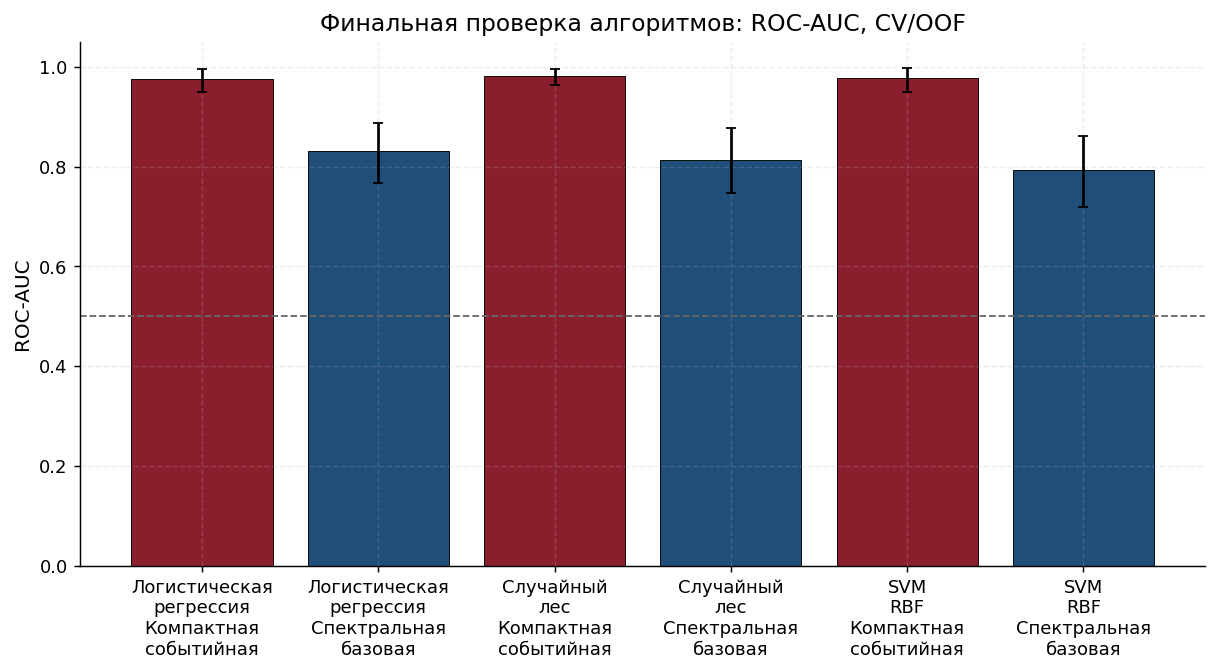

Сохранён рисунок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/figures/10_final_algorithm_check_balanced_accuracy_cv_oof.png


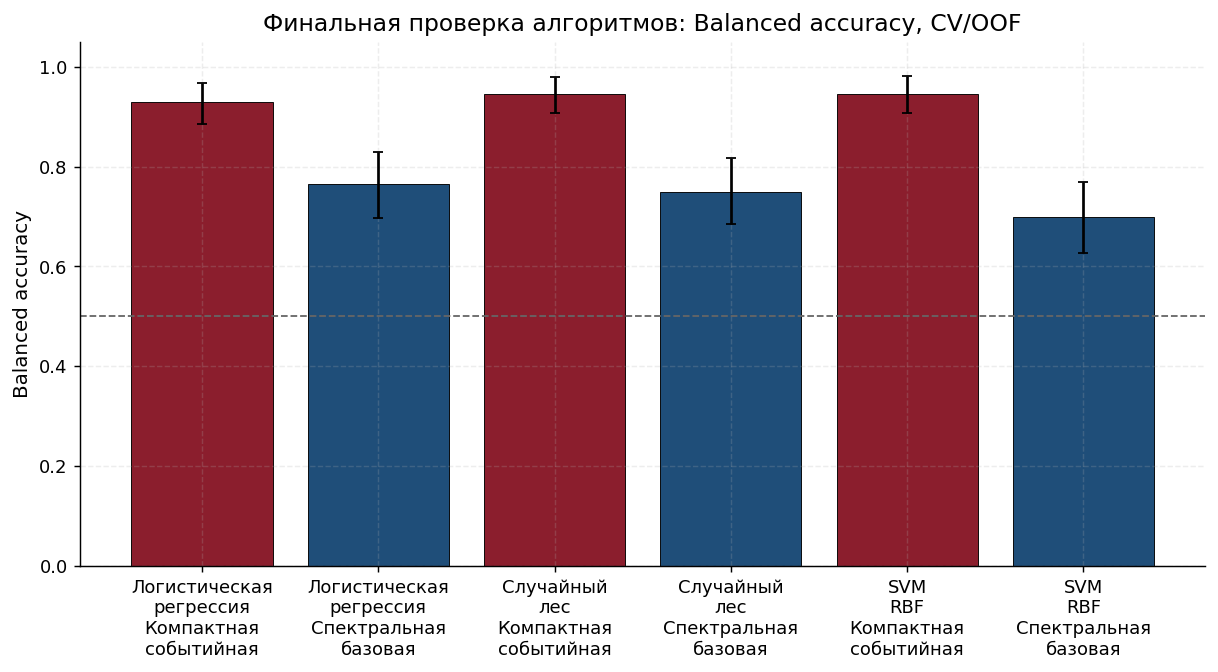

Рейтинг ключевых наборов признаков по ROC-AUC внутри каждого алгоритма:


metric,model,model_ru,feature_set,n_features,roc_auc,balanced_accuracy,sensitivity,specificity
0,logreg,Логистическая регрессия,all_clean_features,302,0.987319,0.938708,0.891304,0.986111
1,logreg,Логистическая регрессия,event_compact,2,0.976298,0.928744,0.913043,0.944444
2,logreg,Логистическая регрессия,spectral_baseline,61,0.831069,0.765399,0.739130,0.791667
3,rf,Случайный лес,all_clean_features,302,0.996981,0.975242,0.978261,0.972222
4,rf,Случайный лес,event_compact,2,0.982035,0.945048,0.945652,0.944444
5,rf,Случайный лес,spectral_baseline,61,0.812198,0.750000,0.750000,0.750000
6,svc_rbf,SVM с RBF-ядром,all_clean_features,302,0.987470,0.943539,0.956522,0.930556
7,svc_rbf,SVM с RBF-ядром,event_compact,2,0.976902,0.945048,0.945652,0.944444
8,svc_rbf,SVM с RBF-ядром,spectral_baseline,61,0.793327,0.699879,0.760870,0.638889


Сохранена таблица: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/ml_vkr_final_results/tables/10_final_algorithm_feature_set_ranking_cv_oof.csv


In [50]:
# @title 10.2. Итоговая проверка всех алгоритмов: full space, spectral baseline и compact event

KEY_FINAL_FEATURE_SETS = [
    "all_clean_features",
    "spectral_baseline",
    "event_compact",
]

KEY_FINAL_METRICS = [
    "roc_auc",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "f1",
    "mcc",
]

available_metric_tables = []
for name in [
    "full_feature_space_metrics_df",
    "baseline_metrics_df",
    "event_metrics_df",
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and len(globals()[name]) > 0:
        available_metric_tables.append(globals()[name].copy())

if not available_metric_tables:
    print("Нет таблиц для финальной проверки. Сначала нужно выполнить разделы 3.6.1, 5.1 и 8.1.")
    final_algorithm_check_long_df = pd.DataFrame()
    final_algorithm_check_table = pd.DataFrame()
    final_algorithm_delta_df = pd.DataFrame()
else:
    final_algorithm_check_long_df = pd.concat(available_metric_tables, ignore_index=True)

    final_algorithm_check_long_df = final_algorithm_check_long_df[
        final_algorithm_check_long_df["feature_set"].isin(KEY_FINAL_FEATURE_SETS)
        & final_algorithm_check_long_df["metric"].isin(KEY_FINAL_METRICS)
        & final_algorithm_check_long_df["validation"].isin(["cv_oof", "holdout"])
    ].copy()

    final_algorithm_check_table = final_algorithm_check_long_df.pivot_table(
        index=["validation", "model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value_ci",
        aggfunc="first",
    ).reset_index()

    display(final_algorithm_check_table)
    save_table(final_algorithm_check_long_df, "10_final_algorithm_check_long.csv")
    save_table(final_algorithm_check_table, "10_final_algorithm_check_table.csv")

    # Сравнение compact event и spectral baseline внутри каждого алгоритма и типа проверки.
    point_df = final_algorithm_check_long_df.pivot_table(
        index=["validation", "model", "model_ru", "feature_set", "n_features"],
        columns="metric",
        values="value",
        aggfunc="first",
    ).reset_index()

    delta_rows = []
    for validation in ["cv_oof", "holdout"]:
        for model_name in MODEL_ORDER:
            base = point_df[
                (point_df["validation"] == validation)
                & (point_df["model"] == model_name)
                & (point_df["feature_set"] == "spectral_baseline")
            ]
            event = point_df[
                (point_df["validation"] == validation)
                & (point_df["model"] == model_name)
                & (point_df["feature_set"] == "event_compact")
            ]
            full = point_df[
                (point_df["validation"] == validation)
                & (point_df["model"] == model_name)
                & (point_df["feature_set"] == "all_clean_features")
            ]

            row = {
                "validation": validation,
                "validation_ru": VALIDATION_RU.get(validation, validation),
                "model": model_name,
                "model_ru": MODEL_LABELS.get(model_name, model_name),
            }

            if len(base) > 0:
                row.update({
                    "spectral_n_features": int(base["n_features"].iloc[0]),
                    "spectral_roc_auc": base["roc_auc"].iloc[0] if "roc_auc" in base else np.nan,
                    "spectral_balanced_accuracy": base["balanced_accuracy"].iloc[0] if "balanced_accuracy" in base else np.nan,
                })
            if len(event) > 0:
                row.update({
                    "event_n_features": int(event["n_features"].iloc[0]),
                    "event_roc_auc": event["roc_auc"].iloc[0] if "roc_auc" in event else np.nan,
                    "event_balanced_accuracy": event["balanced_accuracy"].iloc[0] if "balanced_accuracy" in event else np.nan,
                    "event_sensitivity": event["sensitivity"].iloc[0] if "sensitivity" in event else np.nan,
                    "event_specificity": event["specificity"].iloc[0] if "specificity" in event else np.nan,
                })
            if len(full) > 0:
                row.update({
                    "full_n_features": int(full["n_features"].iloc[0]),
                    "full_roc_auc": full["roc_auc"].iloc[0] if "roc_auc" in full else np.nan,
                    "full_balanced_accuracy": full["balanced_accuracy"].iloc[0] if "balanced_accuracy" in full else np.nan,
                })

            if "event_roc_auc" in row and "spectral_roc_auc" in row:
                row["delta_event_minus_spectral_roc_auc"] = row["event_roc_auc"] - row["spectral_roc_auc"]
            else:
                row["delta_event_minus_spectral_roc_auc"] = np.nan

            if "event_balanced_accuracy" in row and "spectral_balanced_accuracy" in row:
                row["delta_event_minus_spectral_balanced_accuracy"] = (
                    row["event_balanced_accuracy"] - row["spectral_balanced_accuracy"]
                )
            else:
                row["delta_event_minus_spectral_balanced_accuracy"] = np.nan

            row["event_passes_auc_085"] = bool(row.get("event_roc_auc", np.nan) >= 0.85)
            row["event_passes_balanced_accuracy_080"] = bool(row.get("event_balanced_accuracy", np.nan) >= 0.80)
            row["event_ge_spectral_auc"] = bool(row.get("delta_event_minus_spectral_roc_auc", np.nan) >= 0)
            row["event_ge_spectral_balanced_accuracy"] = bool(
                row.get("delta_event_minus_spectral_balanced_accuracy", np.nan) >= 0
            )

            delta_rows.append(row)

    final_algorithm_delta_df = pd.DataFrame(delta_rows)

    print("Итоговая проверка compact event относительно spectral baseline:")
    display(final_algorithm_delta_df)
    save_table(final_algorithm_delta_df, "10_final_algorithm_event_vs_spectral_check.csv")

    # Визуально: compact event vs spectral baseline для всех алгоритмов.
    plot_df = final_algorithm_check_long_df[
        final_algorithm_check_long_df["metric"].isin(["roc_auc", "balanced_accuracy"])
        & final_algorithm_check_long_df["feature_set"].isin(["spectral_baseline", "event_compact"])
        & final_algorithm_check_long_df["validation"].eq("cv_oof")
    ].copy()

    if len(plot_df) > 0:
        plot_df["label"] = (
            plot_df["model"].map(MODEL_LABELS_SHORT)
            + "\n"
            + plot_df["feature_set"].map({
                "spectral_baseline": "Спектральная\nбазовая",
                "event_compact": "Компактная\nсобытийная",
            })
        )
        plot_df = plot_df.sort_values(["metric", "model", "feature_set"])

        for metric in ["roc_auc", "balanced_accuracy"]:
            sub = plot_df[plot_df["metric"] == metric].copy()
            if len(sub) == 0:
                continue

            colors = sub["feature_set"].map({
                "spectral_baseline": COLOR_CONTROL,
                "event_compact": COLOR_TBI,
            }).fillna(COLOR_GRAY)

            fig, ax = plt.subplots(figsize=(9.5, 5.3))
            x = np.arange(len(sub))
            xerr = np.vstack([
                sub["value"] - sub["ci_low"],
                sub["ci_high"] - sub["value"],
            ])

            ax.bar(
                x,
                sub["value"],
                yerr=xerr,
                capsize=3,
                color=colors,
                edgecolor="black",
                linewidth=0.5,
            )
            ax.set_xticks(x)
            ax.set_xticklabels(sub["label"], rotation=0)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel(METRIC_RU.get(metric, metric))
            ax.set_title(f"Финальная проверка алгоритмов: {METRIC_RU.get(metric, metric)}, CV/OOF")
            ax.axhline(0.5, linestyle="--", linewidth=1, color=COLOR_GRAY)
            apply_vkr_axes_style(ax, grid_axis="y")
            save_figure(f"10_final_algorithm_check_{metric}_cv_oof.png")
            plt.show()

    # Кто лучший по каждому алгоритму среди ключевых наборов.
    if len(point_df) > 0:
        best_by_model_df = (
            point_df[
                point_df["feature_set"].isin(KEY_FINAL_FEATURE_SETS)
                & point_df["validation"].eq("cv_oof")
            ]
            .sort_values(["model", "roc_auc"], ascending=[True, False])
            .groupby("model", as_index=False)
            .head(3)
            .copy()
        )
        print("Рейтинг ключевых наборов признаков по ROC-AUC внутри каждого алгоритма:")
        display(best_by_model_df[[
            "model",
            "model_ru",
            "feature_set",
            "n_features",
            "roc_auc",
            "balanced_accuracy",
            "sensitivity",
            "specificity",
        ]])
        save_table(best_by_model_df, "10_final_algorithm_feature_set_ranking_cv_oof.csv")
